<style>
h1 {
  text-align: center;
}
</style>

# Drivers of Urban Heat Risk in European Cities:<br>An Interpretable and Robust Analysis Using Street-Level Sensor Data

---

<div style="height: 32px;"></div>

<div style="text-align: center;">

  <p>
    <strong>Technical University of Munich</strong><br>
    <em>Computational Data Analysis with Python</em><br>
    <em>SoSe 2026 · ED Civil and Environmental Engineering</em>
  </p>

  <p><strong>June 26, 2026</strong></p>

  <p>
    <strong>Andrea Saliola Bucelli</strong> — Student No. 03825812<br>
    <strong>Lucien Raychev</strong> — Student No. 03758419
  </p>

</div>

<div style="height: 8px;"></div>

---

## Quick navigation

| Section | Content |
|---|---|
| [0. Setup](#0-setup) | Imports, paths, plotting settings, and helper functions |
| [1. Problem Framing](#1-problem-framing) | Research question, project scope, assumptions, and success criteria |
| [2. Data Loading and Overview](#2-data-loading-and-overview) | Raw data import, source structure, and initial checks |
| [3. Data Cleaning and Preprocessing](#3-data-cleaning-and-preprocessing) | Cleaning pipeline, city selection, feature construction, and target definition |
| [4. Exploratory Data Analysis](#4-exploratory-data-analysis) | Descriptive, temporal, spatial, and measurement-related patterns |
| [5. Model Development](#5-model-development) | Model inputs, train/test split, preprocessing pipeline, and candidate model fitting |
| [6. Model Validation and Robustness](#6-model-validation-and-robustness) | Model comparison, diagnostics, error analysis, threshold tuning, and robustness checks |
| [7. Discussion and Implications](#7-discussion-and-implications) | Final interpretation, limitations, decision relevance, and next steps |
| [References](#references) | Sources, documentation, and bibliography |

## 0. Setup

The working environment is prepared by importing the required Python libraries, downloading the selected dataset from KaggleHub, configuring plotting settings, and defining custom helper functions used throughout the notebook.

### 0.1. Import Libraries

The notebook uses Python standard-library modules for file handling, garbage collection, HTML/JSON handling, and small utility operations: `gc`, `html`, `json`, `collections.abc`, `itertools`, `math`, and `pathlib`.

The main external libraries are `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `folium`, `branca`, `kagglehub`, and `IPython`. These packages support data manipulation, numerical computation, plotting, model fitting and evaluation, interactive maps, dataset download, and notebook display utilities.

In [1]:
# Standard library
import gc
import html
import json
from collections.abc import Callable
from itertools import islice
from math import ceil
from pathlib import Path

# Third-party libraries
import folium
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from branca.colormap import linear
from branca.element import Element
from IPython.display import IFrame, display
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

# Pandas type-checking utilities
from pandas.api.types import (
    is_datetime64_any_dtype,
    is_numeric_dtype,
    is_string_dtype,
)

# Scikit-learn core utilities
from sklearn.base import clone
from sklearn.compose import ColumnTransformer

# Scikit-learn preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-learn pipelines and models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline

# Scikit-learn metrics and displays
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    log_loss,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

print("Packages loaded successfully.")

Packages loaded successfully.


In [2]:
import sys
import sklearn
import branca
import matplotlib

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"folium: {folium.__version__}")
print(f"branca: {branca.__version__}")
print(f"kagglehub: {kagglehub.__version__}")

Python: 3.12.10
pandas: 2.3.3
numpy: 2.3.4
matplotlib: 3.10.7
seaborn: 0.13.2
scikit-learn: 1.7.2
folium: 0.20.0
branca: 0.8.2
kagglehub: 1.0.1


### 0.2. Import Data

All inputs are derived from the [FAIRUrbTemp curated dataset](https://www.kaggle.com/datasets/pablomoratodomnguez/fairurbtemp-curated), which provides quality-controlled hourly temperature readings alongside station-level metadata for multiple European cities. No external data sources are required.

In [3]:
main_folder = Path(kagglehub.dataset_download("pablomoratodomnguez/fairurbtemp-curated"))
print(f"Dataset path: {main_folder}")

Dataset path: C:\Users\salio\.cache\kagglehub\datasets\pablomoratodomnguez\fairurbtemp-curated\versions\3


### 0.3. Plotting Settings

This section defines reusable plotting settings to keep figures consistent across the notebook, including city colors, and general Matplotlib display parameters.

In [4]:
# Jupyter inline plotting
%matplotlib inline

# Sharper plots in notebooks
%config InlineBackend.figure_format = "retina"

# Global plot settings
plt.rcParams.update({
    # Figure settings
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "figure.constrained_layout.use": True,

    # Font sizes
    "figure.titlesize": 16,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Axes appearance
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Plot settings (global) defined successfully.")

Plot settings (global) defined successfully.


In [5]:
# Consistent city colors to reuse across plots
CITY_COLORS = {
    "Amsterdam": "#2563EB",   # vivid blue
    "Basel": "#F97316",       # warm orange
    "Berlin": "#059669",      # emerald green
    "Bern": "#DC2626",        # strong red
    "Biel": "#06B6D4",        # cyan
    "Birmingham": "#DB2777",  # magenta pink
    "Freiburg": "#CA8A04",    # golden amber
    "NoviSad": "#9333EA",     # purple
    "Zurich": "#64748B",      # slate blue-gray
}

print("Plot settings (colors) defined successfully.")

Plot settings (colors) defined successfully.


In [6]:
# Boxplot style settings
BOXPLOT_KWARGS = dict(
    # General layout
    orientation="horizontal",
    patch_artist=True,

    # Statistical behavior
    showfliers=True,
    whis=1.5,

    # Geometry / layering
    widths=0.6,
    zorder=2,

    # Box: Q1 to Q3
    boxprops=dict(
        linewidth=1.2,
        edgecolor="black",
        facecolor="lightgray",
        alpha=0.65,
    ),

    # Median line
    medianprops=dict(
        color="black",
        linewidth=2,
    ),

    # Whiskers
    whiskerprops=dict(
        color="black",
        linewidth=1,
    ),

    # Whisker caps
    capprops=dict(
        color="black",
        linewidth=1,
    ),

    # Outliers
    flierprops=dict(
        marker="o",
        markersize=2,
        markerfacecolor="None",
        markeredgecolor="black",
        alpha=0.15,
    ),
)

print("Plot settings (boxplot) defined successfully.")

Plot settings (boxplot) defined successfully.


### 0.4. Helper Functions

This section defines reusable utility functions used throughout the notebook in order to reduce repeated code. Defining them once at the beginning makes the workflow cleaner, more consistent, and easier to maintain.

#### 0.4.1. General Helper Functions

The helper functions in this section are used throughout the whole notebook.

- `show_shape()`: displays the number of rows and columns in a compact table. Used for quick dataset-size checks after loading, cleaning, filtering, and feature construction.
- `show_column_info()`: displays column-level information such as data type, missing-value percentage, and number of unique values. Used to inspect structure and data quality before transformations.
- `convert_column_types_checked()`: converts selected columns to the expected data types, such as datetime, numeric, categorical, or string, and verifies that the conversions were applied correctly. Used to standardise the dataset before cleaning and modelling.
- `rename_columns_checked()`: renames selected columns and verifies that the rename was applied correctly. Useful when standardising column names across datasets.
- `drop_columns_checked()`: drops selected columns and verifies that they were removed. Useful when removing redundant, constant, or unusable variables.
- `cleanup_vars()`: deletes temporary variables from the notebook namespace and runs garbage collection. Used after large intermediate objects are no longer needed.

In [7]:
def _as_list(cols: str | list[str] | None) -> list[str]:
    """
    Normalize column input to a list.
    """
    if cols is None:
        return []
    
    if isinstance(cols, str):
        return [cols]
    
    return list(cols)



def show_shape(
    df: pd.DataFrame,
    name: str = "DataFrame",
) -> None:
    """
    Display the number of rows and columns in a readable table.
    """
    shape_info = pd.DataFrame({
        "Metric": ["Rows", "Columns"],
        "Value": [f"{df.shape[0]:,}", f"{df.shape[1]:,}"]
    })

    print(f"{name} shape:")
    display(shape_info)



def show_column_info(
    df: pd.DataFrame,
    columns: str | list[str] | None = None,
    metrics: str | list[str] | None = None,
    name: str = "DataFrame",
) -> None:
    """
    Display selected column-level information.
    """
    if columns is None:
        columns = list(df.columns)
    elif isinstance(columns, str):
        columns = [columns]

    missing_columns = [col for col in columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Columns not found in {name}: {missing_columns}")

    if metrics is None:
        metrics = ["Column", "Data type", "Missing (%)", "Unique"]
    elif isinstance(metrics, str):
        metrics = [metrics]

    column_info = pd.DataFrame({
        "Column": columns,
        "Data type": df[columns].dtypes.astype(str).values,
        "Missing (%)": df[columns].isna().mean().mul(100).round(2).values,
        "Unique": df[columns].nunique(dropna=True).values,
    })

    missing_metrics = [metric for metric in metrics if metric not in column_info.columns]
    if missing_metrics:
        raise ValueError(f"Metrics not available: {missing_metrics}")

    print(f"{name} column information:")
    display(column_info[metrics])



def convert_column_types_checked(
    df: pd.DataFrame,
    datetime_cols: str | list[str] | None = None,
    numeric_cols: str | list[str] | None = None,
    categorical_cols: str | list[str] | None = None,
    string_cols: str | list[str] | None = None,
    name: str = "DataFrame",
) -> pd.DataFrame:
    """
    Convert selected columns to datetime, numeric, categorical, and string types,
    then verify that conversions were applied correctly.
    """
    df = df.copy()

    datetime_cols = _as_list(datetime_cols)
    numeric_cols = _as_list(numeric_cols)
    categorical_cols = _as_list(categorical_cols)
    string_cols = _as_list(string_cols)

    all_requested_cols = datetime_cols + numeric_cols + categorical_cols + string_cols
    missing_cols = [col for col in all_requested_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Columns not found in {name}: {missing_cols}")

    for col in datetime_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

        if not is_datetime64_any_dtype(df[col]):
            raise TypeError(f"Datetime conversion failed for column: {col}")

    if datetime_cols:
        print(f"Datetime columns converted successfully: {datetime_cols}")

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

        if not is_numeric_dtype(df[col]):
            raise TypeError(f"Numeric conversion failed for column: {col}")

    if numeric_cols:
        print(f"Numeric columns converted successfully: {numeric_cols}")

    for col in categorical_cols:
        df[col] = df[col].astype("category")

        if not isinstance(df[col].dtype, pd.CategoricalDtype):
            raise TypeError(f"Categorical conversion failed for column: {col}")

    if categorical_cols:
        print(f"Categorical columns converted successfully: {categorical_cols}")

    for col in string_cols:
        df[col] = df[col].astype("string")

        if not is_string_dtype(df[col]):
            raise TypeError(f"String conversion failed for column: {col}")

    if string_cols:
        print(f"String columns converted successfully: {string_cols}")

    return df



def rename_columns_checked(
    df: pd.DataFrame,
    columns: dict[str, str],
    name: str = "DataFrame",
) -> pd.DataFrame:
    """
    Rename selected DataFrame columns and verify that the rename was applied.
    """
    missing_columns = [
        old_col for old_col in columns
        if old_col not in df.columns
    ]

    if missing_columns:
        raise ValueError(f"Columns to rename were not found in {name}: {missing_columns}")

    duplicated_new_columns = [
        new_col for new_col in columns.values()
        if list(columns.values()).count(new_col) > 1
    ]

    if duplicated_new_columns:
        raise ValueError(f"Duplicate new column names requested: {sorted(set(duplicated_new_columns))}")

    existing_target_columns = [
        new_col for new_col in columns.values()
        if new_col in df.columns and new_col not in columns.keys()
    ]

    if existing_target_columns:
        raise ValueError(f"New column names already exist in {name}: {existing_target_columns}")

    df = df.rename(columns=columns)

    old_columns_still_present = [
        old_col for old_col, new_col in columns.items()
        if old_col in df.columns and old_col != new_col
    ]

    new_columns_missing = [
        new_col for new_col in columns.values()
        if new_col not in df.columns
    ]

    if old_columns_still_present:
        raise ValueError(f"Old column names are still present: {old_columns_still_present}")

    if new_columns_missing:
        raise ValueError(f"New column names were not created: {new_columns_missing}")

    print(f"Columns renamed successfully: {columns}")

    return df



def drop_columns_checked(
    df: pd.DataFrame,
    columns: str | list[str],
    name: str = "DataFrame",
) -> pd.DataFrame:
    """
    Drop selected columns from a DataFrame and verify that they are absent.
    """
    if isinstance(columns, str):
        columns = [columns]

    missing_columns = [col for col in columns if col not in df.columns]

    if missing_columns:
        raise ValueError(f"Columns to drop were not found in {name}: {missing_columns}")

    df = df.drop(columns=columns)

    remaining_columns = [col for col in columns if col in df.columns]

    if remaining_columns:
        raise ValueError(f"Columns were not removed from {name}: {remaining_columns}")

    print(f"Columns dropped successfully: {columns}")

    return df



def cleanup_vars(
    *var_names: str,
    namespace: dict | None = None,
    verbose: bool = True,
) -> None:
    """
    Delete temporary variables from the notebook namespace, run garbage collection,
    and verify that the variables were removed.
    """
    if namespace is None:
        namespace = globals()

    invalid_var_names = [
        var_name for var_name in var_names
        if not isinstance(var_name, str)
    ]

    if invalid_var_names:
        raise TypeError("cleanup_vars() expects variable names as strings.")

    for var_name in var_names:
        namespace.pop(var_name, None)

    gc.collect()

    remaining_vars = [
        var_name for var_name in var_names
        if var_name in namespace
    ]

    if remaining_vars:
        raise RuntimeError(f"Variables were not removed: {remaining_vars}")

    if verbose:
        print(f"Variables removed successfully: {list(var_names)}")



print("Helper functions (general) defined successfully.")

Helper functions (general) defined successfully.


#### 0.4.2. Data Loading Helper Functions

The helper functions in this section are used later in [2. Data Loading and Overview](#2-data-loading-and-overview):

- `folder_tree()`: prints a compact view of the raw folder structure, including the number of city folders and TSV files.
- `preview_tsv_file()`: displays the first rows of a selected TSV file to inspect its structure before loading.
- `get_hourly_df()`: reads one hourly temperature TSV file, extracts station metadata from the file header, builds the `datetime` column, adds the city name, and returns a cleaned hourly DataFrame.
- `get_measurement_df()`: reads one measurement metadata TSV file, standardizes column names, removes repeated metadata fields, and returns a cleaned measurement-level DataFrame.
- `get_station_df()`: reads one station metadata TSV file, standardizes station information, handles Basel-specific station identifiers, and returns a cleaned station-level DataFrame.
- `load_and_concat_tsv_files()`: recursively loads multiple TSV files using a selected reading function, checks column consistency, and concatenates the valid files into one DataFrame.

In [8]:
def _as_folder(
    folder: str | Path,
    label: str = "Folder",
) -> Path:
    """
    Convert input to Path and verify that it is an existing folder.
    """
    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(f"{label} not found: {folder}")

    if not folder.is_dir():
        raise NotADirectoryError(f"{label} is not a folder: {folder}")

    return folder



def _validate_tsv_file(
    file_path: str | Path,
    expected_grandparent: str,
    required_prefix: str | None = None,
) -> Path:
    """
    Validate that a file is a TSV file in the expected folder structure.
    """
    file_path = Path(file_path)

    valid_file = (
        file_path.parent.parent.name == expected_grandparent
        and file_path.is_file()
        and file_path.suffix.lower() == ".tsv"
    )

    if required_prefix is not None:
        valid_file = valid_file and file_path.name.startswith(required_prefix)

    if not valid_file:
        raise ValueError(f"File not recognized: {file_path.parent.name}/{file_path.name}")

    return file_path



def _standardize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize DataFrame column names.
    """
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip()
    return df


def _read_tsv(
    file_path: str | Path,
    **kwargs,
) -> pd.DataFrame:
    """
    Read a TSV file with consistent defaults.
    """
    read_options = {
        "sep": "\t",
        "low_memory": False,
        "encoding": "utf-8",
    }
    read_options.update(kwargs)

    return pd.read_csv(file_path, **read_options)



def folder_tree(
    folder: str | Path,
    depth: int = 3,
    level: int = 0,
    max_items: int | None = None,
) -> None:
    """
    Print a compact folder tree with city and TSV counts.
    """
    folder = _as_folder(folder)

    if level == 0:
        print("Folder exploration:")
        print(f"📁 {folder.name}")

    if level >= depth:
        return

    entries = sorted(folder.iterdir())

    if max_items is not None:
        entries = entries[:max_items]

    for folder_path in entries:
        prefix = "   " * level + "└── "
        icon = "📂" if folder_path.is_dir() else "📄"
        name = folder_path.name

        if folder_path.is_dir():
            if folder_path.name in ["hourly", "metadata"]:
                n_cities = sum(1 for x in folder_path.iterdir() if x.is_dir())
                name = f"{folder_path.name} ({n_cities} cities)"

            elif folder_path.parent.name in ["hourly", "metadata"]:
                n_files = sum(1 for x in folder_path.rglob("*.tsv") if x.is_file())
                name = f"{folder_path.name} ({n_files} .tsv files)"

        print(f"{prefix}{icon} {name}")

        if folder_path.is_dir():
            folder_tree(
                folder_path,
                depth=depth,
                level=level + 1,
                max_items=max_items,
            )



def preview_tsv_file(
    folder: str | Path,
    city: str,
    pattern: str = "*.tsv",
    max_rows: int = 30,
) -> None:
    """
    Print the first rows of the first TSV file matching a pattern inside a city folder.
    """
    city_folder = _as_folder(Path(folder) / city, label="City folder")
    matching_files = sorted(city_folder.glob(pattern))

    if not matching_files:
        print(f"No files found for pattern '{pattern}' in {city_folder}")
        return

    file_path = matching_files[0]

    print(f"File: {file_path.parent.name}/{file_path.name}")
    print("-" * 80)

    with open(file_path, "r", encoding="utf-8") as f:
        for line in islice(f, max_rows):
            print(line, end="")



def get_hourly_df(hourly_file: str | Path) -> pd.DataFrame:
    """
    Read one hourly TSV file and return a cleaned hourly DataFrame.
    """
    file_path = _validate_tsv_file(
        hourly_file,
        expected_grandparent="hourly",
    )

    with open(file_path, "r", encoding="utf-8") as f:
        for n, row in enumerate(f):
            cells = row.strip().split("\t")

            if cells[0] == "Year":
                header = _read_tsv(file_path, nrows=n - 1)
                header = _standardize_column_names(header)

                if "sef" not in header.columns:
                    raise ValueError(f"Header column 'SEF' not found: {file_path.parent.name}/{file_path.name}")

                header = (
                    header
                    .set_index("sef")
                    .T
                    .reset_index()
                    .rename(columns={"index": "sef"})
                )

                header = _standardize_column_names(header)

                if file_path.parent.name == "Basel":
                    header = (
                        header
                        .rename(columns={"name": "station_number"})
                        .drop(columns=["id", "source", "link", "meta"], errors="ignore")
                    )

                    if "station_number" not in header.columns:
                        raise ValueError(f"Basel station number not found: {file_path.parent.name}/{file_path.name}")

                    header["station_number"] = (
                        header["station_number"]
                        .astype("string")
                        .str.split("_")
                        .str[-1]
                    )

                else:
                    header = (
                        header
                        .rename(columns={"id": "station_number"})
                        .drop(columns=["name", "source", "link", "meta"], errors="ignore")
                    )

                    if "station_number" not in header.columns:
                        raise ValueError(f"Station number not found: {file_path.parent.name}/{file_path.name}")

                tabular = _read_tsv(file_path, skiprows=n)
                tabular = _standardize_column_names(tabular)

                datetime_columns = ["year", "month", "day", "hour", "minute"]
                missing_datetime_columns = [
                    col for col in datetime_columns
                    if col not in tabular.columns
                ]

                if missing_datetime_columns:
                    raise ValueError(
                        f"Datetime columns missing in {file_path.parent.name}/{file_path.name}: "
                        f"{missing_datetime_columns}"
                    )

                tabular = tabular.dropna(how="all")

                tabular["datetime"] = pd.to_datetime(
                    {
                        "year": tabular["year"],
                        "month": tabular["month"],
                        "day": tabular["day"],
                        "hour": tabular["hour"],
                        "minute": tabular["minute"],
                    },
                    errors="coerce",
                )

                tabular = tabular.drop(columns=datetime_columns)
                tabular["city"] = file_path.parent.name

                hourly_df = (
                    tabular
                    .assign(**header.iloc[0].to_dict())
                    .rename(columns={"alt": "altitude_m"})
                )

                return hourly_df

    raise ValueError(
        f"No tabular section starting with 'Year' found: "
        f"{file_path.parent.name}/{file_path.name}"
    )



def get_measurement_df(metadata_measurement_file: str | Path) -> pd.DataFrame:
    """
    Read one measurement metadata TSV file and return a cleaned measurement DataFrame.
    """
    file_path = _validate_tsv_file(
        metadata_measurement_file,
        expected_grandparent="metadata",
        required_prefix="measurement_",
    )

    measurement_df = _read_tsv(file_path)
    measurement_df = _standardize_column_names(measurement_df)

    measurement_df = measurement_df.drop(
        columns=["city", "measured_variable", "units", "qc_flag"],
        errors="ignore",
    )

    measurement_df = (
        measurement_df
        .dropna(how="all")
        .reindex(sorted(measurement_df.columns), axis=1)
    )

    return measurement_df



def get_station_df(metadata_station_file: str | Path) -> pd.DataFrame:
    """
    Read one station metadata TSV file and return a cleaned station DataFrame.
    """
    file_path = _validate_tsv_file(
        metadata_station_file,
        expected_grandparent="metadata",
        required_prefix="station_",
    )

    station_df = _read_tsv(file_path)
    station_df = _standardize_column_names(station_df)

    station_df = station_df.drop(
        columns=["city", "latitude", "longitude"],
        errors="ignore",
    )

    if "altitude_m" not in station_df.columns:
        station_df["altitude_m"] = np.nan

    if file_path.parent.name == "Basel":
        if "station_id" not in station_df.columns:
            raise ValueError("Basel station file is missing required column: station_id")

        station_df["station_number"] = station_df["station_id"]

    station_df = (
        station_df
        .dropna(how="all")
        .reindex(sorted(station_df.columns), axis=1)
    )

    return station_df



def load_and_concat_tsv_files(
    folder: str | Path,
    pattern: str,
    read_func: Callable[[Path], pd.DataFrame],
    label: str,
) -> pd.DataFrame | None:
    """
    Load multiple TSV files recursively, check that their columns match,
    and concatenate them into one DataFrame.
    """
    folder = _as_folder(folder)
    files = sorted(folder.rglob(pattern))

    print(f"Found {len(files):,} {label} files.")

    if not files:
        print(f"No {label} files found.")
        return None

    df_list = []
    reference_columns = None
    column_mismatch_count = 0

    for file_path in files:
        df = read_func(file_path)
        current_columns = list(df.columns)

        if reference_columns is None:
            reference_columns = current_columns

        elif current_columns != reference_columns:
            missing_columns = sorted(set(reference_columns) - set(current_columns))
            extra_columns = sorted(set(current_columns) - set(reference_columns))

            print(
                f"File: {file_path.parent.name}/{file_path.name}\n"
                f"Missing: {missing_columns}\n"
                f"Extra: {extra_columns}\n"
            )

            column_mismatch_count += 1
            continue

        df_list.append(df)

    print(f"Found {column_mismatch_count:,} {label} files with column mismatches.")

    if column_mismatch_count > 0:
        print(f"{label}_merged was not created because column mismatches were found.")
        return None

    merged_df = pd.concat(df_list, ignore_index=True)

    print(f"All {label} DataFrames have been concatenated.")
    print()

    return merged_df



print("Helper functions (data loading) defined successfully.")

Helper functions (data loading) defined successfully.


#### 0.4.3. Modelling Helper Functions

This section defines helper functions used later in [5. Model Development](#5-model-development):

- `make_model_split()`: creates a chronological train/test split from a split-configuration dictionary, filters the selected cities and time windows, separates predictors and target, and returns the model-ready train and test objects.
- `city_balanced_weights()`: computes city-balanced sample weights from the training set only, so that overrepresented cities receive lower individual weights and underrepresented cities receive higher individual weights during model fitting.

In [9]:
def make_model_split(
    df: pd.DataFrame,
    split_config: dict,
    feature_cols: list[str],
    target_col: str,
    city_col: str = "city",
    station_col: str = "station_number",
    datetime_col: str = "datetime",
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Create a chronological train/test split from a split-configuration dictionary.
    """
    required_keys = ["label", "cities", "train_start", "train_end", "test_start", "test_end"]
    missing_keys = [key for key in required_keys if key not in split_config]

    if missing_keys:
        raise ValueError(f"Missing split configuration keys: {missing_keys}")

    if target_col in feature_cols:
        raise ValueError("The target column cannot be used as a feature.")

    required_cols = [city_col, station_col, datetime_col, target_col] + feature_cols
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    cities = split_config["cities"]

    if isinstance(cities, str):
        cities = [cities]

    train_start = pd.Timestamp(split_config["train_start"])
    train_end = pd.Timestamp(split_config["train_end"])
    test_start = pd.Timestamp(split_config["test_start"])
    test_end = pd.Timestamp(split_config["test_end"])

    if train_start >= train_end:
        raise ValueError("train_start must be before train_end.")

    if test_start >= test_end:
        raise ValueError("test_start must be before test_end.")

    if train_end > test_start:
        raise ValueError("Train and test windows must not overlap.")

    data = df.loc[df[city_col].isin(cities)].copy()

    train_data = data.loc[
        (data[datetime_col] >= train_start) &
        (data[datetime_col] < train_end)
    ].copy()

    test_data = data.loc[
        (data[datetime_col] >= test_start) &
        (data[datetime_col] < test_end)
    ].copy()

    if len(train_data) == 0:
        raise ValueError("Training set is empty.")

    if len(test_data) == 0:
        raise ValueError("Test set is empty.")

    if train_data[target_col].nunique(dropna=True) != 2:
        raise ValueError("Training target does not contain both classes.")

    if test_data[target_col].nunique(dropna=True) != 2:
        raise ValueError("Test target does not contain both classes.")

    X_train = train_data[feature_cols].copy()
    X_test = test_data[feature_cols].copy()
    y_train = train_data[target_col].copy()
    y_test = test_data[target_col].copy()

    valid_target_values = {0, 1}

    train_target_values = set(y_train.dropna().unique())
    test_target_values = set(y_test.dropna().unique())

    if train_target_values != valid_target_values:
        raise ValueError(
            f"Training target must contain exactly 0 and 1. Found: {train_target_values}"
        )

    if test_target_values != valid_target_values:
        raise ValueError(
            f"Test target must contain exactly 0 and 1. Found: {test_target_values}"
        )

    if verbose:
        split_summary = pd.DataFrame([
            {
                "set": "train",
                "rows": len(train_data),
                "cities": train_data[city_col].nunique(),
                "stations": train_data[[city_col, station_col]].drop_duplicates().shape[0],
                "start_date": train_data[datetime_col].min(),
                "end_date": train_data[datetime_col].max(),
                "positive_class_pct": y_train.mean() * 100,
            },
            {
                "set": "test",
                "rows": len(test_data),
                "cities": test_data[city_col].nunique(),
                "stations": test_data[[city_col, station_col]].drop_duplicates().shape[0],
                "start_date": test_data[datetime_col].min(),
                "end_date": test_data[datetime_col].max(),
                "positive_class_pct": y_test.mean() * 100,
            },
        ])

        print(split_config["label"])
        print(f"Cities included: {', '.join(cities)}")
        display(split_summary.round({"positive_class_pct": 2}))

    return train_data, test_data, X_train, X_test, y_train, y_test



def city_balanced_weights(
    train_data: pd.DataFrame,
    city_col: str = "city",
    verbose: bool = True,
) -> pd.Series:
    """
    Compute city-balanced sample weights from the training set only.
    """
    if city_col not in train_data.columns:
        raise ValueError(f"City column not found: {city_col}")

    if len(train_data) == 0:
        raise ValueError("Training data is empty.")

    city_counts = train_data[city_col].value_counts()
    n_train = len(train_data)
    n_cities = train_data[city_col].nunique()

    if n_cities == 0:
        raise ValueError("No cities found in the training data.")

    weight_map = n_train / (n_cities * city_counts)

    sample_weight_train = (
        train_data[city_col]
        .map(weight_map)
        .astype(float)
    )

    if sample_weight_train.isna().any():
        raise ValueError("Some sample weights are missing.")

    if (sample_weight_train <= 0).any():
        raise ValueError("All sample weights must be positive.")

    if verbose:
        weight_summary = (
            train_data
            .assign(sample_weight=sample_weight_train)
            .groupby(city_col, observed=True)
            .agg(
                observations=(city_col, "size"),
                sample_weight=("sample_weight", "first"),
                total_weight=("sample_weight", "sum"),
            )
            .reset_index()
        )

        weight_summary["observations_pct"] = (
            weight_summary["observations"] / weight_summary["observations"].sum() * 100
        )

        weight_summary["total_weight_pct"] = (
            weight_summary["total_weight"] / weight_summary["total_weight"].sum() * 100
        )

        print("Training city-balanced weights:")
        display(
            weight_summary.round({
                "observations_pct": 2,
                "sample_weight": 4,
                "total_weight": 2,
                "total_weight_pct": 2,
            })
        )

    return sample_weight_train



print("Helper functions (modelling) defined successfully.")

Helper functions (modelling) defined successfully.


#### 0.4.4. Evaluation Helper Functions

This section defines the helper functions used later in [6. Model Validation and Robustness](#6-model-validation-and-robustness):

* `evaluate_classifier()`: computes classification metrics from observed labels and predicted probabilities at a specified classification threshold.
* `make_confusion_matrix()`: converts predicted probabilities into class predictions at a specified threshold and returns a labelled confusion-matrix DataFrame.
* `evaluate_by_city()`: computes classification metrics separately for each city and optionally displays a formatted city-level table.
* `plot_city_performance()`: plots multi-panel city-level performance diagnostics.
* `outcome_share_table()`: creates outcome-composition tables by month, hour, and probability bucket, optionally displaying them.
* `plot_outcome_share_diagnostics()`: plots false-positive and false-negative shares across months, hours, and probability buckets.
* `plot_probability_by_outcome()`: plots predicted-probability distributions by classification outcome.

In [10]:
# Core evaluation helpers
def evaluate_classifier(
    y_true: pd.Series,
    y_proba: pd.Series,
    model_name: str,
    threshold: float = 0.5,
) -> pd.DataFrame:
    """
    Compute classification metrics for binary high-heat prediction
    at a specified probability threshold.
    """
    if pd.Series(y_true).nunique(dropna=True) != 2:
        raise ValueError("y_true must contain both classes to compute ROC-AUC and PR-AUC.")

    if not 0 <= threshold <= 1:
        raise ValueError("threshold must be between 0 and 1.")

    y_pred = (np.asarray(y_proba) >= threshold).astype(int)

    results = {
        "model": model_name,
        "threshold": threshold,

        # Threshold-independent metrics
        "log_loss": log_loss(y_true, y_proba),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),

        # Threshold-dependent metrics
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "f3": fbeta_score(y_true, y_pred, beta=3, zero_division=0),
        "predicted_positive_rate": y_pred.mean()
    }

    return pd.DataFrame([results])



def make_confusion_matrix(
    y_true: pd.Series,
    y_proba: pd.Series,
    labels: tuple[int, int] = (0, 1),
    threshold: float = 0.5,
) -> pd.DataFrame:
    """
    Create a labelled confusion matrix DataFrame for binary classification
    at a specified probability threshold.
    """
    if pd.Series(y_true).nunique(dropna=True) != 2:
        raise ValueError("y_true must contain both classes to compute ROC-AUC and PR-AUC.")
    
    if not 0 <= threshold <= 1:
        raise ValueError("threshold must be between 0 and 1.")

    y_pred = (np.asarray(y_proba) >= threshold).astype(int)

    return pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=labels),
        index=[f"Actual {label}" for label in labels],
        columns=[f"Predicted {label}" for label in labels],
    )



# City-level diagnostics
def evaluate_by_city(
    df_pred: pd.DataFrame,
    model_name: str,
    city_col: str = "city",
    true_col: str = "y_true",
    proba_col: str = "y_proba",
    threshold: float = 0.5,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Evaluate classification performance separately for each city
    at a specified probability threshold.
    """
    required_cols = [city_col, true_col, proba_col]
    missing_cols = [col for col in required_cols if col not in df_pred.columns]

    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    if not 0 <= threshold <= 1:
        raise ValueError("threshold must be between 0 and 1.")

    city_results = []

    for city, data in df_pred.groupby(city_col, observed=True):
        y_true_city = data[true_col]
        y_proba_city = data[proba_col]

        city_metrics = evaluate_classifier(
            y_true=y_true_city,
            y_proba=y_proba_city,
            model_name=model_name,
            threshold=threshold,
        ).iloc[0].to_dict()

        city_metrics.update({
            "city": city,
            "observations": len(data),
            "positive_class_pct": y_true_city.mean() * 100,
        })
        city_results.append(city_metrics)

    city_results_df = (
        pd.DataFrame(city_results)
        .sort_values("observations", ascending=False)
        .reset_index(drop=True)
    )

    if verbose:
        display_cols = [
            "city", "observations", "positive_class_pct", "model", "threshold",
            "log_loss", "roc_auc", "pr_auc", "accuracy", "balanced_accuracy",
            "precision", "recall", "specificity", "f1",
        ]
        rounding = {
            "positive_class_pct": 2,
            **dict.fromkeys(display_cols[4:], 4),
        }

        print(f"{model_name} performance by city at threshold {threshold:.4f}:")
        display(city_results_df[display_cols].round(rounding))

    return city_results_df



def _prepare_city_plot_data(
    city_results: pd.DataFrame,
    city_colours: dict[str, str],
    city_col: str = "city",
) -> tuple[pd.DataFrame, list[str]]:
    """
    Prepare city-level evaluation results for plotting.
    """
    plot_data = city_results.copy()

    plot_data["observations_pct"] = (
        plot_data["observations"] / plot_data["observations"].sum() * 100
    )
    plot_data["predicted_positive_pct"] = (
        plot_data["predicted_positive_rate"] * 100
    )

    city_order = [city for city in city_colours if city in plot_data[city_col].unique()]
    city_order += sorted(set(plot_data[city_col]) - set(city_order))

    plot_data = (
        plot_data
        .set_index(city_col)
        .reindex(city_order)
        .reset_index()
    )
    plot_colours = [city_colours.get(city, "#9CA3AF") for city in plot_data[city_col]]

    return plot_data, plot_colours



def plot_city_performance(
    city_results: pd.DataFrame,
    model_name: str,
    threshold: float,
    city_colours: dict[str, str],
    metric_specs: list[tuple[str, str, str]] | None = None,
    n_cols: int = 3,
    figsize: tuple[int, int] = (17, 20),
) -> None:
    """
    Plot city-level model performance metrics in a multi-panel bar chart.
    """
    if metric_specs is None:
        metric_specs = [
            ("observations_pct", "Share of Test Observations", "percentage"),
            ("positive_class_pct", "Observed High-Heat Rate", "percentage"),
            ("predicted_positive_pct", "Predicted High-Heat Rate", "percentage"),
            ("log_loss", "Log Loss", "loss"),
            ("roc_auc", "ROC-AUC", "score"),
            ("pr_auc", "PR-AUC", "score"),
            ("accuracy", "Accuracy", "score"),
            ("balanced_accuracy", "Balanced Accuracy", "score"),
            ("precision", "Precision", "score"),
            ("recall", "Recall", "score"),
            ("specificity", "Specificity", "score"),
            ("f1", "F1-Score", "score"),
        ]

    city_plot_data, plot_colours = _prepare_city_plot_data(
        city_results=city_results,
        city_colours=city_colours,
    )

    n_rows = ceil(len(metric_specs) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharey=True,
        layout="constrained",
    )

    axes = np.asarray(axes).flatten()
    y_positions = np.arange(len(city_plot_data))

    for panel_index, (metric, title, scale_type) in enumerate(metric_specs):
        ax = axes[panel_index]
        values = city_plot_data[metric].to_numpy()

        ax.barh(y_positions, values, color=plot_colours)
        ax.set_title(title, pad=10)
        ax.invert_yaxis()
        ax.grid(axis="y", visible=False)

        if panel_index % n_cols == 0:
            ax.set_yticks(y_positions)
            ax.set_yticklabels(city_plot_data["city"])
        else:
            ax.tick_params(axis="y", labelleft=False)

        if scale_type == "score":
            upper_limit = 1.10
            formatter = "{:.3f}".format
        elif scale_type == "percentage":
            upper_limit = max(100, np.nanmax(values) * 1.20)
            ax.set_xlabel("Percent")
            formatter = "{:.1f}%".format
        else:
            upper_limit = np.nanmax(values) * 1.22
            formatter = "{:.3f}".format

        ax.set_xlim(0, upper_limit)
        label_offset = upper_limit * 0.01

        for y_position, value in zip(y_positions, values):
            if pd.notna(value):
                ax.text(
                    value + label_offset,
                    y_position,
                    formatter(value),
                    va="center",
                    fontsize=8,
                )

    for ax in axes[len(metric_specs):]:
        ax.remove()

    fig.suptitle(
        f"{model_name} Performance by City "
        f"at the Selected Threshold ({threshold:.3f})"
    )
    plt.show()



# Prediction-error diagnostics
def _prepare_error_diagnostics(
    df_pred: pd.DataFrame,
    threshold: float,
    test_data: pd.DataFrame,
    time_cols: list[str] | None = None,
    true_col: str = "y_true",
    proba_col: str = "y_proba",
) -> pd.DataFrame:
    """
    Prepare prediction-level outcomes for error diagnostics.
    """
    if time_cols is None:
        time_cols = ["month", "hour"]

    required_cols = [true_col, proba_col]
    missing_cols = [col for col in required_cols if col not in df_pred.columns]
    if missing_cols:
        raise ValueError(f"Missing prediction columns: {missing_cols}")

    missing_time_cols = [col for col in time_cols if col not in test_data.columns]
    if missing_time_cols:
        raise ValueError(f"Missing test-data columns: {missing_time_cols}")

    err = df_pred.copy()
    err["y_pred"] = (err[proba_col] >= threshold).astype(int)

    for col in time_cols:
        err[col] = test_data.loc[err.index, col].to_numpy()

    err["error_type"] = np.select(
        [
            (err[true_col] == 1) & (err["y_pred"] == 1),
            (err[true_col] == 0) & (err["y_pred"] == 1),
            (err[true_col] == 1) & (err["y_pred"] == 0),
        ],
        ["correct", "false_positive", "false_negative"],
        default="correct",
    )
    err["outcome_type"] = err["error_type"].str.replace("_", " ")
    err["proba_bucket"] = pd.cut(
        err[proba_col],
        bins=np.arange(0, 1.1, 0.1),
        include_lowest=True,
    )

    return err



def outcome_share_table(
    df_pred: pd.DataFrame,
    threshold: float,
    test_data: pd.DataFrame,
    verbose: bool = True,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Prepare error diagnostics and compute outcome-composition tables.
    """
    err = _prepare_error_diagnostics(
        df_pred=df_pred,
        threshold=threshold,
        test_data=test_data,
    )
    group_cols = ["month", "hour", "proba_bucket"]
    outcome_col = "outcome_type"
    outcome_order = ["correct", "false positive", "false negative"]

    required_cols = [outcome_col, *group_cols]
    missing_cols = [col for col in required_cols if col not in err.columns]
    if missing_cols:
        raise ValueError(f"Missing error-diagnostic columns: {missing_cols}")

    display_names = {
        "month": "month",
        "hour": "hour",
        "proba_bucket": "probability bucket",
    }

    diagnostic_tables = {
        display_names.get(group_col, group_col): (
            err
            .groupby(group_col, observed=True)[outcome_col]
            .value_counts(normalize=True)
            .unstack(fill_value=0)
            .reindex(columns=outcome_order, fill_value=0)
        )
        for group_col in group_cols
    }

    if verbose:
        for group_name, table in diagnostic_tables.items():
            print(f"Outcome composition by {group_name}:")
            display(table.round(3))

    return err, diagnostic_tables



def plot_outcome_share_diagnostics(
    df_pred: pd.DataFrame,
    threshold: float,
    test_data: pd.DataFrame,
    model_name: str,
    plot_columns: list[str] | None = None,
    error_colors: dict[str, str] | None = None,
    verbose: bool = False,
) -> None:
    """
    Plot misclassification shares by month, hour, and probability bucket.
    """
    _, diagnostic_tables = outcome_share_table(
        df_pred=df_pred,
        threshold=threshold,
        test_data=test_data,
        verbose=verbose,
    )

    if plot_columns is None:
        plot_columns = ["false positive", "false negative"]
    if error_colors is None:
        error_colors = {
            "false positive": "#EDAE49",
            "false negative": "#D1495B",
        }

    plot_specs = [
        ("month", "Misclassification Rates by Month", "Month"),
        ("hour", "Misclassification Rates by Hour", "Hour of day"),
        (
            "probability bucket",
            "Misclassification Rates by Predicted-Probability Bucket",
            "Predicted probability of high heat",
        ),
    ]

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 17),
        sharey=True,
        layout="constrained",
    )

    for ax, (table_name, title, xlabel) in zip(axes, plot_specs):
        plot_data = diagnostic_tables[table_name][plot_columns]
        plot_data.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=[error_colors[col] for col in plot_columns],
        )

        ax.set(title=title, xlabel=xlabel, ylabel="Share of observations")
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.grid(axis="x", visible=False)
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Error type")

        rotation = 45 if table_name == "probability bucket" else 0
        ax.tick_params(axis="x", labelrotation=rotation)

        if rotation:
            for label in ax.get_xticklabels():
                label.set_ha("right")

    fig.suptitle(
        f"{model_name} Error Diagnostics at Threshold {threshold:.3f}"
    )
    plt.show()

    return None



def plot_probability_by_outcome(
    err: pd.DataFrame,
    threshold: float,
    boxplot_kwargs: dict,
    true_col: str = "y_true",
    pred_col: str = "y_pred",
    proba_col: str = "y_proba",
) -> None:
    """
    Plot predicted probabilities by classification outcome.
    """
    required_cols = [true_col, pred_col, proba_col]
    missing_cols = [col for col in required_cols if col not in err.columns]
    if missing_cols:
        raise ValueError(f"Missing error-diagnostic columns: {missing_cols}")

    plot_data = err.copy()
    plot_data["classification_outcome"] = np.select(
        [
            (plot_data[true_col] == 1) & (plot_data[pred_col] == 0),
            (plot_data[true_col] == 0) & (plot_data[pred_col] == 1),
            (plot_data[true_col] == 0) & (plot_data[pred_col] == 0),
            (plot_data[true_col] == 1) & (plot_data[pred_col] == 1),
        ],
        ["False negative", "False positive", "True negative", "True positive"],
        default="Unknown",
    )

    outcome_order = [
        "False negative",
        "False positive",
        "True negative",
        "True positive",
    ]
    outcome_colors = {
        "False negative": "#D1495B",
        "False positive": "#EDAE49",
        "True negative": "#64748B",
        "True positive": "#64748B",
    }

    probability_data = [
        plot_data.loc[
            plot_data["classification_outcome"] == outcome,
            proba_col,
        ].dropna().to_numpy()
        for outcome in outcome_order
    ]
    plot_kwargs = {**boxplot_kwargs, "orientation": "vertical"}

    fig, ax = plt.subplots(figsize=(12, 7))
    bp = ax.boxplot(
        probability_data,
        tick_labels=outcome_order,
        **plot_kwargs,
    )

    for i, outcome in enumerate(outcome_order):
        color = outcome_colors[outcome]
        bp["boxes"][i].set_facecolor(color)
        bp["fliers"][i].set_markeredgecolor(color)
        bp["fliers"][i].set_markerfacecolor(color)

    ax.axhline(
        threshold,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Selected threshold = {threshold:.4f}",
    )

    ax.set(
        title="Predicted Probabilities by Classification Outcome",
        xlabel="Classification outcome",
        ylabel="Predicted probability of high heat",
        ylim=(0, 1),
    )
    ax.tick_params(axis="x", labelrotation=25)

    for label in ax.get_xticklabels():
        label.set_ha("right")

    ax.grid(axis="x", visible=False)
    ax.legend()
    plt.show()

    return None



print("Helper functions (evaluation) defined successfully.")

def _clean_feature_names(feature_names: list[str] | np.ndarray) -> pd.Series:
    """
    Return readable feature names from a fitted preprocessing pipeline.
    """
    return (
        pd.Series(feature_names)
        .str.replace("numeric__", "", regex=False)
        .str.replace("categorical__city_", "City: ", regex=False)
    )

def _get_reference_city(pipeline: Pipeline) -> str:
    """
    Return the dropped reference city from a fitted preprocessing pipeline.
    """
    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    encoder = fitted_preprocessor.named_transformers_["categorical"].named_steps["encoder"]
    return encoder.categories_[0][encoder.drop_idx_[0]]

def get_logistic_coefficients(
    pipeline: Pipeline,
    model_name: str,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Extract fitted logistic-regression coefficients from a model pipeline.
    """
    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    fitted_model = pipeline.named_steps["model"]
    reference_city = _get_reference_city(pipeline)

    feature_names = _clean_feature_names(
        fitted_preprocessor.get_feature_names_out()
    )
    coefficients = fitted_model.coef_.ravel()

    assert len(feature_names) == len(coefficients), (
        "Feature names and coefficients do not match."
    )

    coef_df = pd.DataFrame({
        "model": model_name,
        "feature": feature_names,
        "coefficient": coefficients,
    })

    coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
    coef_df["odds_change_pct"] = (coef_df["odds_ratio"] - 1) * 100
    coef_df["is_city_effect"] = coef_df["feature"].str.startswith("City: ")
    coef_df["interpretation_unit"] = np.where(
        coef_df["is_city_effect"],
        f"relative to {reference_city}",
        "per 1-SD increase or binary change",
    )
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

    coefficient_table = (
        coef_df
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    if verbose:
        print(f"Reference city: {reference_city}")
        print("Numeric-feature odds ratios refer to a one-standard-deviation "
              "increase because numeric predictors were standardized.")
        
        display(
            coefficient_table
            .drop(columns="is_city_effect")
            .round({
                "coefficient": 3,
                "odds_ratio": 3,
                "odds_change_pct": 1,
                "abs_coefficient": 3,
            })
        )

    return coefficient_table

def get_random_forest_importances(
    pipeline: Pipeline,
    model_name: str = "Random Forest",
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Extract fitted random-forest Gini feature importances from a model pipeline.
    """
    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    fitted_model = pipeline.named_steps["model"]

    importance_table = (
        pd.DataFrame({
            "model": model_name,
            "feature": _clean_feature_names(fitted_preprocessor.get_feature_names_out()),
            "importance": fitted_model.feature_importances_,
        })
        .assign(
            is_city_effect=lambda df: df["feature"].str.startswith("City: ")
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    if verbose:
        print(f"{model_name} feature importances (Gini, sorted by magnitude)")
        display(
            importance_table
            .drop(columns="is_city_effect")
            .round({"importance": 4})
        )

    return importance_table

def _prepare_driver_plot_data(
    driver_table: pd.DataFrame,
    value_col: str | None = None,
    signed_value_col: str | None = None,
    model_col: str = "model",
    feature_col: str = "feature",
    top_n: int | None = None,
) -> pd.DataFrame:
    """
    Prepare logistic coefficients or random-forest importances for driver plots.
    """
    plot_data = driver_table.copy()

    if value_col is None:
        if "abs_coefficient" in plot_data.columns:
            value_col = "abs_coefficient"
        elif "importance" in plot_data.columns:
            value_col = "importance"
        else:
            raise ValueError("Provide value_col or include abs_coefficient/importance.")

    if signed_value_col is None and "coefficient" in plot_data.columns:
        signed_value_col = "coefficient"

    if "is_city_effect" not in plot_data.columns:
        plot_data["is_city_effect"] = plot_data[feature_col].str.startswith("City: ")

    plot_data["plot_feature"] = plot_data[feature_col].str.replace(
        "City: ",
        "",
        regex=False,
    )
    plot_data["plot_value"] = plot_data[value_col]
    plot_data["signed_value"] = (
        plot_data[signed_value_col] if signed_value_col is not None else np.nan
    )
    plot_data["has_signed_value"] = signed_value_col is not None
    plot_data["plot_colour"] = np.where(
        plot_data["is_city_effect"],
        "#c44e52",
        "#4c72b0",
    )

    plot_data = plot_data.sort_values(
        [model_col, "plot_value"],
        ascending=[True, False],
    )
    plot_data["importance_rank"] = plot_data.groupby(model_col).cumcount() + 1

    if top_n is not None:
        plot_data = plot_data.loc[plot_data["importance_rank"] <= top_n]

    return plot_data.reset_index(drop=True)

def plot_driver_importance(
    plot_data: pd.DataFrame,
    title: str,
    signed_value_label: str = "Coefficient",
    importance_label: str = "Magnitude / importance",
    reference_city: str | None = None,
    model_col: str = "model",
    figsize: tuple[int, int] | None = None,
) -> None:
    """
    Plot one or more model-driver tables, stacked by model when needed.
    """
    model_names = plot_data[model_col].drop_duplicates().tolist()
    has_signed_panel = plot_data["has_signed_value"].any()
    n_rows = len(model_names)
    n_cols = 2 if has_signed_panel else 1

    if figsize is None:
        figsize = (15 if has_signed_panel else 9, 6 * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)

    for row_idx, model_name in enumerate(model_names):
        model_data = plot_data.loc[plot_data[model_col] == model_name]

        if has_signed_panel:
            ax_effect = axes[row_idx, 0]
            if model_data["has_signed_value"].all():
                effect_plot = model_data.sort_values("signed_value")
                ax_effect.barh(
                    effect_plot["plot_feature"],
                    effect_plot["signed_value"],
                    color=effect_plot["plot_colour"],
                )
                ax_effect.axvline(0, color="black", linewidth=1)
                ax_effect.set(xlabel=signed_value_label)
                if n_rows > 1:
                    ax_effect.set_title(f"{model_name}: direction and magnitude", pad=15)
                else:
                    ax_effect.set_title("Direction and Magnitude of Effects", pad=25)
            else:
                ax_effect.axis("off")
                ax_effect.set_title(f"{model_name}: signed effects not available")
            ax_rank = axes[row_idx, 1]
        else:
            ax_rank = axes[row_idx, 0]

        ranking_plot = model_data.sort_values("plot_value")
        ax_rank.barh(
            ranking_plot["plot_feature"],
            ranking_plot["plot_value"],
            color=ranking_plot["plot_colour"],
        )

        for y_position, (_, item) in enumerate(ranking_plot.iterrows()):
            ax_rank.text(
                item["plot_value"],
                y_position,
                f"  Rank {item['importance_rank']}",
                va="center",
                fontsize=9,
            )

        if n_rows > 1:
            ax_rank.set_title(f"{model_name}: ranking by magnitude", pad=15)
        else:
            ax_rank.set_title("Ranking by Magnitude", pad=25)

        ax_rank.set(xlabel=importance_label)

        for ax in axes[row_idx, :]:
            ax.tick_params(axis="y", labelrotation=45)
            ax.grid(axis="y", visible=False)

    city_label = "City effects"
    if reference_city is not None:
        city_label = f"City effects (relative to {reference_city})"

    legend_handles = [
        Patch(facecolor="#4c72b0", label="Numeric/cyclical drivers"),
        Patch(facecolor="#c44e52", label=city_label),
    ]
    legend_y = 0.98 if n_rows > 1 else 0.96
    title_y = 1.06 if n_rows > 1 else 1.05

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, legend_y),
        ncol=2,
        frameon=True,
    )
    fig.suptitle(title, y=title_y)
    plt.show()

def plot_coefficient_robustness(
    coefficients: pd.DataFrame,
    title: str,
    scenario_col: str = "model",
    feature_col: str = "feature",
    coefficient_col: str = "coefficient",
    top_n: int | None = None,
    figsize: tuple[int, int] = (12, 8),
) -> None:
    """
    Compare logistic-regression coefficients across robustness scenarios.
    """
    required_cols = [scenario_col, feature_col, coefficient_col]
    missing_cols = [col for col in required_cols if col not in coefficients.columns]
    if missing_cols:
        raise ValueError(f"Missing coefficient columns: {missing_cols}")

    coef_plot = coefficients.copy()
    coef_plot["plot_feature"] = coef_plot[feature_col].str.replace(
        "City: ",
        "",
        regex=False,
    )

    feature_order = (
        coef_plot
        .groupby("plot_feature")[coefficient_col]
        .apply(lambda values: values.abs().mean())
        .sort_values(ascending=False)
    )

    if top_n is not None:
        feature_order = feature_order.head(top_n)

    pivot = (
        coef_plot
        .loc[coef_plot["plot_feature"].isin(feature_order.index)]
        .pivot_table(
            index="plot_feature",
            columns=scenario_col,
            values=coefficient_col,
            aggfunc="first",
        )
        .reindex(feature_order.index[::-1])
    )

    fig, ax = plt.subplots(figsize=figsize)
    pivot.plot(kind="barh", ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.set(
        title=title,
        xlabel="Logistic-regression coefficient",
        ylabel="Feature",
    )
    ax.grid(axis="y", visible=False)
    ax.legend(title="Scenario", loc="lower right")
    plt.show()

def fit_evaluate_model(
    split_config: dict,
    target_col: str,
    data: pd.DataFrame | None = None,
    input_feature_cols: list[str] | None = None,
    model_pipeline: Pipeline | None = None,
    model_name: str | None = None,
    feature_subset_name: str | None = None,
    threshold: float | None = None,
    use_city_balanced_weights: bool = True,
    verbose: bool = True,
) -> tuple[pd.DataFrame, Pipeline, pd.DataFrame]:
    """
    Fit a model once and return metrics, fitted pipeline, and coefficients.
    """
    if data is None:
        data = model_data
    if input_feature_cols is None:
        input_feature_cols = feature_cols
    if model_name is None:
        model_name = selected_model_name
    if feature_subset_name is None:
        feature_subset_name = "All selected features"
    if model_pipeline is None:
        model_pipeline = models[model_name]
    if threshold is None:
        threshold = selected_threshold

    train_data, test_data, X_train, X_test, y_train, y_test = make_model_split(
        df=data,
        split_config=split_config,
        feature_cols=input_feature_cols,
        target_col=target_col,
        verbose=False,
    )

    sample_weight = None
    if use_city_balanced_weights:
        sample_weight = city_balanced_weights(
            train_data=train_data,
            verbose=False,
        )

    fitted_pipeline = clone(model_pipeline)
    if sample_weight is None:
        fitted_pipeline.fit(X_train, y_train)
    else:
        fitted_pipeline.fit(
            X_train,
            y_train,
            model__sample_weight=sample_weight,
        )

    y_proba = fitted_pipeline.predict_proba(X_test)[:, 1]

    evaluation = evaluate_classifier(
        y_true=y_test,
        y_proba=y_proba,
        model_name=model_name,
        threshold=threshold,
    )

    coefficients = get_logistic_coefficients(
        pipeline=fitted_pipeline,
        model_name=model_name,
        verbose=False,
    )

    if verbose:
        reference_city = _get_reference_city(fitted_pipeline)
        print(f"Model: {model_name}")
        print(f"Target: {target_col}")
        print(f"Split: {split_config['label']}")
        print(f"Cities: {sorted(train_data['city'].unique())}")
        print(f"Feature subset: {feature_subset_name}")
        print(f"\nReference city: {reference_city}")
        print("Numeric-feature odds ratios refer to a one-standard-deviation "
              "increase because numeric predictors were standardized.")
        display(
            coefficients.round({
                "coefficient": 3,
                "odds_ratio": 3,
                "odds_change_pct": 1,
                "abs_coefficient": 3,
            })
        )
        print()

    return evaluation, fitted_pipeline, coefficients


print("Helper functions (evaluation, interpretation and robustness checks) defined successfully.")

Helper functions (evaluation) defined successfully.
Helper functions (evaluation, interpretation and robustness checks) defined successfully.


#### 0.4.5. Station-Risk Map Helper Functions

This section defines the helper functions used later in [7. Discussion and Implications](#7-discussion-and-implications):

* `build_station_risk_map_for_config()`: fits the selected model for a chosen split/target configuration and then builds the corresponding station-risk map.
* `build_station_risk_map()`: builds, optionally saves, and optionally displays a station-risk map from a fitted model and matching test data.
* `_make_reference_temporal_features()`: creates the shared hourly/monthly temporal profile used to evaluate every station over the selected test period.
* `_make_station_profiles()`: creates one fixed spatial and measurement profile per station from the selected test data.
* `_predict_station_risk()`: predicts each station over the shared temporal profile and computes station-level mean and median predicted risk.
* `_add_station_markers()`: adds station markers, popups, tooltips, and city layers to a Folium map.
* `_add_city_navigation()`: adds map navigation buttons for jumping between cities.

In [11]:
# Public map builders

def build_station_risk_map_for_config(
    split_config: dict,
    target_col: str,
    data: pd.DataFrame,
    feature_cols: list[str],
    temporal_feature_cols: list[str],
    spatial_feature_cols: list[str],
    measurement_feature_cols: list[str],
    save_html: bool = False,
    html_path: str = "station_risk_map.html",
    display_output: bool = True,
    iframe_height: int = 650,
    tiles: str = "CartoDB positron",
    initial_zoom: int = 5,
    city_zoom: int = 12,
    marker_radius: int = 8,
    verbose: bool = False,
) -> folium.Map:
    """
    Fit the selected model for a split/target configuration and build its station-risk map.
    """
    _, test_data, _, _, _, _ = make_model_split(
        df=data,
        split_config=split_config,
        feature_cols=feature_cols,
        target_col=target_col,
        verbose=False,
    )

    _, fitted_pipeline, _ = fit_evaluate_model(
        split_config=split_config,
        target_col=target_col,
        data=data,
        input_feature_cols=feature_cols,
        verbose=verbose,
    )

    return build_station_risk_map(
        test_data=test_data,
        split_config=split_config,
        model_pipeline=fitted_pipeline,
        feature_cols=feature_cols,
        temporal_feature_cols=temporal_feature_cols,
        spatial_feature_cols=spatial_feature_cols,
        measurement_feature_cols=measurement_feature_cols,
        save_html=save_html,
        html_path=html_path,
        display_output=display_output,
        iframe_height=iframe_height,
        tiles=tiles,
        initial_zoom=initial_zoom,
        city_zoom=city_zoom,
        marker_radius=marker_radius,
    )

def build_station_risk_map(
    test_data: pd.DataFrame,
    split_config: dict,
    model_pipeline: Pipeline,
    feature_cols: list[str],
    temporal_feature_cols: list[str],
    spatial_feature_cols: list[str],
    measurement_feature_cols: list[str],
    save_html: bool = False,
    html_path: str = "station_risk_map.html",
    display_output: bool = True,
    iframe_height: int = 650,
    tiles: str = "CartoDB positron",
    initial_zoom: int = 5,
    city_zoom: int = 12,
    marker_radius: int = 8,
) -> folium.Map:
    """
    Build, optionally save, and optionally display the station-risk map.
    """
    reference_temporal_data = _make_reference_temporal_features(
        split_config=split_config,
        temporal_feature_cols=temporal_feature_cols,
    )
    station_profiles = _make_station_profiles(
        test_data=test_data,
        spatial_feature_cols=spatial_feature_cols,
        measurement_feature_cols=measurement_feature_cols,
    )

    station_risk_map_data = _predict_station_risk(
        station_profiles=station_profiles,
        reference_temporal_data=reference_temporal_data,
        model_pipeline=model_pipeline,
        feature_cols=feature_cols,
        spatial_feature_cols=spatial_feature_cols,
        measurement_feature_cols=measurement_feature_cols,
    )

    risk_min = station_risk_map_data["mean_predicted_probability_pct"].min()
    risk_max = station_risk_map_data["mean_predicted_probability_pct"].max()

    if np.isclose(risk_min, risk_max):
        risk_max = risk_min + 1e-6

    colour_scale = linear.YlOrRd_09.scale(risk_min, risk_max)
    colour_scale.caption = (
        "Standardised mean probability of a "
        "city-relative high-heat event (%)"
    )

    map_object = folium.Map(
        location=[
            station_risk_map_data["lat"].mean(),
            station_risk_map_data["lon"].mean(),
        ],
        zoom_start=initial_zoom,
        tiles=tiles,
    )

    city_centres = _add_station_markers(
        map_object=map_object,
        station_risk_map_data=station_risk_map_data,
        colour_scale=colour_scale,
        marker_radius=marker_radius,
    )

    all_bounds = [
        [
            station_risk_map_data["lat"].min(),
            station_risk_map_data["lon"].min(),
        ],
        [
            station_risk_map_data["lat"].max(),
            station_risk_map_data["lon"].max(),
        ],
    ]

    map_object.fit_bounds(all_bounds, padding=(30, 30))
    _add_city_navigation(
        map_object=map_object,
        city_centres=city_centres,
        all_bounds=all_bounds,
        city_zoom=city_zoom,
    )

    colour_scale.add_to(map_object)
    folium.LayerControl(collapsed=True).add_to(map_object)

    if save_html:
        map_object.save(html_path)

    if display_output:
        if save_html:
            display(IFrame(src=html_path, width="100%", height=iframe_height))
        else:
            display(map_object)

    return map_object

# Station-profile and prediction helpers

def _make_reference_temporal_features(
    split_config: dict,
    temporal_feature_cols: list[str],
) -> pd.DataFrame:
    """
    Create the common temporal profile used to evaluate every station.
    """
    test_start = pd.Timestamp(split_config["test_start"])
    test_end = pd.Timestamp(split_config["test_end"])

    reference_time = pd.DataFrame({
        "datetime": pd.date_range(
            start=test_start,
            end=test_end - pd.Timedelta(hours=1),
            freq="h",
        )
    })

    reference_time["hour"] = reference_time["datetime"].dt.hour
    reference_time["month"] = reference_time["datetime"].dt.month
    reference_time["is_weekend"] = (
        reference_time["datetime"]
        .dt.dayofweek
        .isin([5, 6])
        .astype(int)
    )

    reference_time["hour_sin"] = np.sin(
        2 * np.pi * reference_time["hour"] / 24
    )
    reference_time["hour_cos"] = np.cos(
        2 * np.pi * reference_time["hour"] / 24
    )
    reference_time["month_sin"] = np.sin(
        2 * np.pi * reference_time["month"] / 12
    )
    reference_time["month_cos"] = np.cos(
        2 * np.pi * reference_time["month"] / 12
    )

    return reference_time[temporal_feature_cols].copy()

def _make_station_profiles(
    test_data: pd.DataFrame,
    spatial_feature_cols: list[str],
    measurement_feature_cols: list[str],
) -> pd.DataFrame:
    """
    Create one fixed spatial and measurement profile per station.
    """
    station_data = test_data.copy()
    station_data["observed_month"] = station_data["datetime"].dt.month
    station_data["observed_hour"] = station_data["datetime"].dt.hour

    station_profiles = (
        station_data
        .groupby(["city", "station_number"], observed=True)
        .agg(
            lat=("lat", "median"),
            lon=("lon", "median"),
            lat_centered=("lat_centered", "median"),
            lon_centered=("lon_centered", "median"),
            sensor_height_m=("sensor_height_m", "median"),
            measurement_interval_min=("measurement_interval_min", "median"),
            test_observations=("datetime", "size"),
            observed_timestamps=("datetime", "nunique"),
            observed_months=("observed_month", "nunique"),
            observed_hours=("observed_hour", "nunique"),
            first_observation=("datetime", "min"),
            last_observation=("datetime", "max"),
        )
        .reset_index()
    )

    required_columns = (
        ["lat", "lon"]
        + spatial_feature_cols
        + measurement_feature_cols
    )
    complete_profiles = ~station_profiles[required_columns].isna().any(axis=1)

    return station_profiles.loc[complete_profiles].reset_index(drop=True)

def _predict_station_risk(
    station_profiles: pd.DataFrame,
    reference_temporal_data: pd.DataFrame,
    model_pipeline: Pipeline,
    feature_cols: list[str],
    spatial_feature_cols: list[str],
    measurement_feature_cols: list[str],
) -> pd.DataFrame:
    """
    Predict each station over the same temporal profile.
    """
    station_risk_results = []

    for _, station in station_profiles.iterrows():
        station_X = reference_temporal_data.copy()

        for column in spatial_feature_cols + measurement_feature_cols:
            station_X[column] = station[column]

        station_X["city"] = station["city"]
        station_X = station_X[feature_cols]

        station_probabilities = model_pipeline.predict_proba(station_X)[:, 1]

        station_risk_results.append({
            "city": station["city"],
            "station_number": station["station_number"],
            "mean_predicted_probability": station_probabilities.mean(),
            "median_predicted_probability": np.median(station_probabilities),
        })

    station_risk = pd.DataFrame(station_risk_results)
    station_risk_map_data = station_profiles.merge(
        station_risk,
        on=["city", "station_number"],
        how="inner",
        validate="one_to_one",
    )

    station_risk_map_data["mean_predicted_probability_pct"] = (
        station_risk_map_data["mean_predicted_probability"] * 100
    )
    station_risk_map_data["within_city_rank"] = (
        station_risk_map_data
        .groupby("city", observed=True)["mean_predicted_probability"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )
    station_risk_map_data["stations_in_city"] = (
        station_risk_map_data
        .groupby("city", observed=True)["station_number"]
        .transform("count")
    )

    return (
        station_risk_map_data
        .sort_values(["city", "mean_predicted_probability"], ascending=[True, False])
        .reset_index(drop=True)
    )


# Folium map assembly helpers

def _add_station_markers(
    map_object: folium.Map,
    station_risk_map_data: pd.DataFrame,
    colour_scale,
    marker_radius: int,
) -> dict:
    """
    Add station markers and city layers to a Folium map.
    """
    city_centres = {}

    for city, city_data in station_risk_map_data.groupby("city", observed=True):
        city_centres[city] = {
            "lat": city_data["lat"].mean(),
            "lon": city_data["lon"].mean(),
        }

        city_layer = folium.FeatureGroup(name=str(city), show=True)

        for _, station in city_data.iterrows():
            risk_pct = station["mean_predicted_probability_pct"]
            popup_text = (
                f"<b>{html.escape(str(city))}</b><br>"
                f"Station: {html.escape(str(station['station_number']))}<br>"
                f"Within-city rank: {station['within_city_rank']} of "
                f"{station['stations_in_city']}<br>"
                f"Mean predicted probability: {risk_pct:.2f}%<br>"
                f"Observed test records: "
                f"{int(station['test_observations']):,}<br>"
                f"Observed months: {int(station['observed_months'])} of 12<br>"
                f"Observed hours of day: {int(station['observed_hours'])} of 24"
            )

            folium.CircleMarker(
                location=[station["lat"], station["lon"]],
                radius=marker_radius,
                color=colour_scale(risk_pct),
                fill=True,
                fill_color=colour_scale(risk_pct),
                fill_opacity=0.85,
                weight=1,
                tooltip=(
                    f"{city} - Station {station['station_number']} - "
                    f"{risk_pct:.2f}%"
                ),
                popup=folium.Popup(popup_text, max_width=300),
            ).add_to(city_layer)

        city_layer.add_to(map_object)

    return city_centres

def _add_city_navigation(
    map_object: folium.Map,
    city_centres: dict,
    all_bounds: list[list[float]],
    city_zoom: int,
) -> None:
    """
    Add fixed navigation buttons for jumping between cities.
    """
    map_name = map_object.get_name()

    button_html = f"""
<div style="
    position: fixed;
    top: 80px;
    left: 50px;
    z-index: 9999;
    background-color: white;
    padding: 10px;
    border: 1px solid #999;
    border-radius: 5px;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.35);
    max-height: 70vh;
    overflow-y: auto;
    font-size: 13px;
">
    <div style="font-weight: bold; margin-bottom: 8px;">
        Navigate to city
    </div>

    <button
        onclick="{map_name}.fitBounds(
            {json.dumps(all_bounds)},
            {{padding: [30, 30]}}
        )"
        style="width: 100%; margin-bottom: 5px; cursor: pointer;"
    >
        All cities
    </button>
"""

    for city, centre in sorted(city_centres.items()):
        safe_city = html.escape(str(city))
        button_html += f"""
    <button
        onclick="{map_name}.setView(
            [{centre['lat']}, {centre['lon']}],
            {city_zoom}
        )"
        style="display: block; width: 100%; margin-bottom: 4px; cursor: pointer;"
    >
        {safe_city}
    </button>
    """

    button_html += "</div>"
    map_object.get_root().html.add_child(Element(button_html))



print("Helper functions (station-risk map) defined successfully.")

Helper functions (station-risk map) defined successfully.


## 1. Problem Framing

This stage defines the analytical problem addressed in the project. It clarifies the research question, the target outcome, the relevant input features, and the intended use of the analysis, while also stating the main assumptions and success criteria. In particular, it frames the analysis at station-hour level, specifies how high heat exposure is operationalized as a binary target, and explains how the resulting driver ranking can support interpretable, engineering-oriented decision making.

### 1.1. Research Question

Urban areas across Europe are increasingly exposed to heat events driven by both regional climate conditions and local urban amplification mechanisms, such as the urban heat island effect. Street-level sensor networks make it possible to study heat exposure at fine spatial and temporal resolution, capturing differences not only between cities but also between monitoring locations within the same city.

This project addresses the following question:

> **At the station-hour level across selected European cities, which temporal, spatial, and measurement-related factors are most strongly associated with high heat exposure — defined as temperatures exceeding a city-specific percentile threshold — and how stable are these associations across alternative threshold definitions and time periods?**

The analysis is conducted at the station-hour level because this is the resolution at which heat exposure is observed in the dataset, allowing the project to identify when and where high heat risk is systematically more likely — even within the same city. The objective is not only to predict high-heat observations, but to rank and interpret the main drivers of heat exposure in a way that supports practical decisions, such as prioritising locations for urban heat mitigation or informing future heat-risk mapping efforts.

### 1.2. Motivation

High heat exposure has well-documented negative consequences for human health, including excess mortality during heatwaves, increased pressure on healthcare systems, and reduced outdoor thermal comfort. Beyond health, it drives higher energy demand for cooling, accelerates infrastructure degradation, and disproportionately affects vulnerable populations in dense urban environments.

Identifying which factors are most strongly associated with heat risk supports urban decision-making by revealing which temporal and spatial conditions are most predictive of high heat exposure. While the features considered here — such as time of day and geographic location — are not directly modifiable, they carry practical value: knowing *when* and *where* heat risk is highest allows resources to be concentrated where they are most needed, while avoiding unnecessary cooling expenditure in lower-risk conditions — reducing both operational costs and energy consumption.

Additionally, systematic patterns tied to human activity cycles — such as consistently higher temperatures on weekdays due to traffic and industrial activity — may emerge as interpretable signals. While no causal claims can be made from this analysis alone, such patterns could generate hypotheses worth investigating in future work.

### 1.3. Target and Inputs

#### 1.3.1. Target Variable

Heat risk is operationalized as a binary outcome: a station-hour observation is classified as high-heat if the recorded temperature is equal to or above the city-specific 90th percentile of the temperature distribution. This city-relative definition accounts for the fact that cities operate under different baseline climates, ensuring that the threshold reflects locally elevated conditions rather than an absolute cross-city standard. The sensitivity of results to this threshold choice will be explicitly assessed by comparing driver rankings under alternative percentile definitions, such as the 85th and 95th percentiles.

#### 1.3.2. Input Features

Four categories of factors are considered, all derived directly from the [FAIRUrbTemp curated dataset](https://www.kaggle.com/datasets/pablomoratodomnguez/fairurbtemp-curated) without using current temperature measurements as predictors. Lag features, rolling averages, or other temperature-derived quantities are deliberately excluded: since the target variable is itself defined from temperature, including such features would allow the model to exploit autocorrelation in the time series rather than identifying structural drivers of heat exposure. This would inflate predictive performance while undermining the interpretability of the driver ranking, which is the primary objective of this analysis.

| Feature | Category | Description |
|---|---|---|
| `hour_sin`, `hour_cos` | Temporal | Cyclic encoding of hour of day (0–23), preserving continuity across midnight |
| `month_sin`, `month_cos` | Temporal | Cyclic encoding of month (1–12), preserving continuity across year boundaries |
| `is_weekend` | Temporal | Binary flag indicating Saturday or Sunday |
| `lat_centered` | Spatial | Station latitude minus city mean latitude, capturing within-city north–south position |
| `lon_centered` | Spatial | Station longitude minus city mean longitude, capturing within-city east–west position |
| `sensor_type` | Measurement-related | Type of temperature sensor, which may systematically influence recorded values |
| `sensor_height_m` | Measurement-related | Height of sensor above ground, which may affect near-surface temperature exposure |
| `measurement_interval_min` | Measurement-related | Measurement interval in minutes, capturing differences in temporal sampling before hourly aggregation |
| `city` | City-level | Categorical control capturing unmeasured city-level factors such as climate zone, urban form, and network design |

Note that `hour` and `month` are encoded exclusively as cyclic sine-cosine pairs rather than raw integers. Raw integer encoding would impose a false discontinuity — treating hour 23 as far from hour 0 — which is avoided by the cyclic representation. Tree-based models do not strictly require this transformation, but it is applied consistently across all models for comparability. `season` is excluded from the main model as it is largely redundant with `month_sin` and `month_cos`, but may be used in sensitivity checks or EDA for interpretability. Station elevation (`altitude_m`) was not consistently available across the selected cities and is therefore excluded; this is acknowledged as a limitation, as topographic effects on temperature cannot be assessed with the available data.

#### 1.3.3. Modelling Approach

**Main analysis.** A single pooled model is trained on all selected cities and the selected time window. Observations from all cities are combined to estimate general, cross-city drivers of high heat exposure. City-level differences are controlled through the `city` feature and within-city spatial variables (`lat_centered`, `lon_centered`), which together separate between-city and within-city spatial variation. Model performance is first compared with a dummy baseline. Unregularized logistic regression is used as the main interpretable model, while an L2-regularized specification assesses the stability of coefficient directions and magnitudes. A deliberately simple random forest is included as a nonlinear comparison to test whether relevant nonlinear relationships or interactions remain uncaptured. Logistic-regression coefficients and random-forest feature importances are then compared to assess the consistency of the identified drivers. More complex ensemble methods are not considered because interpretability, rather than maximum predictive performance, is the primary objective.

**Robustness checks.** The stability of the results is assessed along four dimensions:

1. *Heat-risk definition* — the main target uses the city-specific 90th percentile, while the 85th and 95th percentiles are considered to assess whether the identified drivers are sensitive to a broader or more extreme definition of high heat.

2. *Time window* — the main specification is compared with an alternative temporal window to assess whether the direction and ranking of the main drivers remain stable across periods.

3. *Feature groups* — nested specifications are compared using temporal variables, temporal and spatial variables, and the full predictor set including measurement-related controls. The `city` feature is retained in every specification to control for baseline differences between cities. This assesses whether the conclusions are driven mainly by temporal patterns or whether spatial and measurement-related variables provide additional explanatory value.

4. *Model specification* — coefficient directions and magnitudes are compared between the unregularized and L2-regularized logistic regressions, while the random forest provides a nonlinear comparison. This assesses whether the main conclusions remain stable under coefficient shrinkage and a more flexible functional form.

Two more demanding out-of-sample checks are acknowledged but are not implemented in the current analysis:

5. *Temporal transportability* — the model could be evaluated on a substantially earlier or later period than the main analysis window to assess whether the identified drivers remain stable across distant temporal conditions. Evaluation on an earlier period would provide a test of temporal stability rather than realistic forecasting, as the model would be estimated using later observations. This check is not implemented because it would require sufficiently comparable data from a distant period and careful consideration of changes in seasonality, data coverage, and weather conditions.

6. *Leave-one-city-out cross-validation* — the model could be trained on all cities except one and evaluated on the excluded city, repeating the procedure for each city. All preprocessing would be fitted within each fold, and unseen city categories would need to be handled appropriately. This would provide a stricter test of generalisation to urban contexts not represented during model estimation. It is not implemented because it requires additional fold-specific preprocessing, model fitting, and interpretation, but it represents a natural extension of the validation framework.

### 1.4. Intended Use

The analysis is intended for decision support. The primary output is an interpretable, evidence-based ranking of heat-risk drivers, quantifying the direction and magnitude of each factor’s association with high heat exposure. This ranking is complemented by a station-level spatial risk map. For each city, the selected model is applied to every station over a common set of test-period timestamps, and the resulting mean predicted heat-risk probability is plotted at the station’s geographic coordinates. Using common temporal conditions prevents differences in station coverage from driving the comparison and highlights monitoring locations with systematically higher model-estimated risk. This provides a more actionable output for prioritising locations for cooling infrastructure or targeted early-warning measures. The output is a dot map, with one point per monitoring station, rather than a continuous spatial surface. Producing a smooth heatmap would require spatial interpolation and additional modelling assumptions that are beyond the scope of this project.

### 1.5. Success Criteria and Assumptions

The analysis is considered **successful** if:

* the fitted classification models materially outperform the dummy baseline on the chronological test set, particularly in terms of log loss, ROC-AUC, and PR-AUC, while also achieving a useful balance between recall, precision, and specificity at the selected classification threshold;
* the direction and relative magnitude of the main heat-risk associations can be clearly interpreted from the unregularized logistic-regression coefficients and odds ratios;
* the main coefficient signs and driver rankings remain broadly consistent under L2 regularization, while random-forest feature importance provides supporting evidence that the identified predictors remain relevant under a more flexible nonlinear specification;
* the principal conclusions remain reasonably stable under alternative city-specific heat-risk definitions, temporal windows, and theoretically defined feature subsets;
* the pooled model performs reasonably consistently across cities when evaluated through city-level ranking and classification metrics, without the aggregate results being driven disproportionately by a small number of urban contexts;
* the station-level maps show interpretable within-city variation in standardised mean predicted heat-risk probabilities, calculated by evaluating every station over the same reference calendar;
* the results support practical conclusions about when and where city-relative high-heat events are more likely, while remaining clearly framed as predictive associations rather than causal estimates.

**Key assumptions** include:

* station metadata, including latitude, longitude, sensor height, and measurement interval, are sufficiently accurate and stable to represent local spatial and measurement conditions;
* temperature readings correctly reflect the source data and have not been systematically distorted by file encoding, unit conversion, merging, or preprocessing errors;
* the cleaning, station matching, filtering, target construction, and feature-engineering procedures produce a consistent station-hour dataset suitable for supervised classification;
* observations retained after quality-control filtering and missing-value handling are sufficiently reliable, and any remaining missingness is not so systematically related to extreme heat that it invalidates the estimated associations;
* the city-specific 90th-percentile target provides a meaningful measure of relative high heat within each city, but does not measure absolute heat severity consistently across cities;
* city-balancing sample weights appropriately prevent cities with more observations from dominating model estimation, although they do not make the selected stations or cities statistically representative of all European urban areas;
* the `city` categorical feature and within-city centred coordinates capture sufficient between-city and within-city spatial variation for a pooled analysis, while recognising that unobserved differences in urban form, land cover, and local climate may remain;
* the station-level map represents model-estimated risk rather than observed station prevalence. Each station is evaluated over an identical reference calendar, with its spatial and measurement characteristics held fixed, so missing months or hours do not directly determine its average mapped probability;
* the relationships identified by the models are associations rather than causal effects, because potentially relevant environmental and urban-form variables may be unavailable or imperfectly measured;
* the selected cities, stations, and study period provide an informative basis for the analysis, although transferability to unseen cities, distant time periods, or other climate regions remains limited without additional external validation.

## 2. Data Loading and Overview

This section verifies that the raw merged dataset is correctly structured before cleaning and preprocessing. The audit checks duplicated columns from the merge, constant columns, data types, and the variables needed for the modelling pipeline.

The audit covers the three relevant file types: hourly temperature records, station-level metadata, and measurement metadata. Network-level files are examined but excluded from the analysis, as they contain only administrative information at the city level. After loading the hourly temperature files and merging them with the station and measurement metadata, the final merged DataFrame now contains all available information for each hourly observation: the temperature record, its timestamp and location, and the associated station and measurement metadata.

The resulting raw DataFrame columns are then interpreted in a structured way at the end of this section.

Helper functions used in this section are defined in [0.4.2. Data Loading Helper Functions](#042-data-loading-helper-functions).

### 2.1. Data Folder Structure

The dataset is organized under the `data/` directory, which contains two subfolders:

- `hourly/`: temperature readings for 9 cities, each stored as a collection of `.tsv` files — one per station.
- `metadata/`: station-level metadata for 12 cities (a superset of the hourly cities), also in `.tsv` format, with 3 files per city covering station-, measurement-, and network-level information.

The `hourly/` folder is the primary source for the temperature time series used in the analysis. The `metadata/` folder provides the station characteristics (coordinates, sensor type, etc.) that will be used as input features.

In [12]:
folder_tree(main_folder, depth=3)

Folder exploration:
📁 3
└── 📂 data
   └── 📂 hourly (9 cities)
      └── 📂 Amsterdam (23 .tsv files)
      └── 📂 Basel (215 .tsv files)
      └── 📂 Berlin (11 .tsv files)
      └── 📂 Bern (55 .tsv files)
      └── 📂 Biel (39 .tsv files)
      └── 📂 Birmingham (23 .tsv files)
      └── 📂 Freiburg (44 .tsv files)
      └── 📂 NoviSad (26 .tsv files)
      └── 📂 Zurich (276 .tsv files)
   └── 📂 metadata (12 cities)
      └── 📂 Amsterdam (3 .tsv files)
      └── 📂 Basel (3 .tsv files)
      └── 📂 Berlin (3 .tsv files)
      └── 📂 Bern (3 .tsv files)
      └── 📂 Biel (3 .tsv files)
      └── 📂 Birmingham (3 .tsv files)
      └── 📂 Freiburg (3 .tsv files)
      └── 📂 Ghent (3 .tsv files)
      └── 📂 NoviSad (3 .tsv files)
      └── 📂 Rennes (3 .tsv files)
      └── 📂 Turku (3 .tsv files)
      └── 📂 Zurich (3 .tsv files)
└── 📂 docs
   └── 📄 FAIRUrbTemp_readme.txt
└── 📄 LICENSE
└── 📄 README.md


In [13]:
data_folder = Path(main_folder, "data")
hourly_folder = Path(data_folder, "hourly")
metadata_folder = Path(data_folder, "metadata")

print("Paths stored successfully.")

Paths stored successfully.


### 2.2. File Structure and Data Loading

This section examines the structure of the four available file types — hourly, measurement, network, and station — and loads them into type-specific DataFrames. Basic checks are performed during loading to verify the column structure.

#### 2.2.1. data/hourly/

Each hourly `.tsv` file uses the SEF (Station Exchange Format), with a short station metadata header followed by the hourly temperature table.

The header includes station information such as ID, name, coordinates, altitude, source, and available quality-control flag types. For the analysis, only the relevant station descriptors will be retained; administrative fields such as `Source` and `Link` are excluded.

The table contains the actual hourly temperature readings in °C, indexed by `Year`, `Month`, `Day`, and `Hour`. The row-level `Meta` column indicates observations flagged by the quality-control procedure.

---

After checking the structure of all hourly files, no column mismatches were found. This means that all files share a common format and can be safely combined.

The individual hourly files were therefore concatenated into a single merged dataset, `hourly_merged`, which provides a consistent structure for the subsequent cleaning, feature engineering, and modelling steps.

In [14]:
preview_tsv_file(
    folder=hourly_folder,
    city="Amsterdam",
    pattern="*.tsv",
    max_rows=20
)

File: Amsterdam/D2195_AirTemp_hourly_UTC.tsv
--------------------------------------------------------------------------------
SEF	1.0.0
ID	NLD_AMS_2195
Name	NLD_AMS_Ams17
Lat	52.4
Lon	4.96
Alt	NA
Source	Wageningen University & Research
Link	NA
Vbl	ta
Stat	mean
Units	°C
Meta	URBNET Project |qc = gross_errors,out_of_range,time_consistency,temporal_persistance,climatic_outliers,spatiotemporal_consistency,spatial_consistency
Year	Month	Day	Hour	Minute	Period	Value	Meta
2014	05	30	22	00	hourly	NA	
2014	05	30	23	00	hourly	NA	
2014	05	31	00	00	hourly	NA	
2014	05	31	01	00	hourly	NA	
2014	05	31	02	00	hourly	NA	
2014	05	31	03	00	hourly	NA	
2014	05	31	04	00	hourly	NA	


In [15]:
hourly_merged = load_and_concat_tsv_files(
    folder=hourly_folder,
    pattern="*.tsv",
    read_func=get_hourly_df,
    label="hourly"
)

print("hourly_merged preview:")
display(hourly_merged.head())

Found 712 hourly files.
Found 0 hourly files with column mismatches.
All hourly DataFrames have been concatenated.

hourly_merged preview:


,period,value,meta,datetime,city,sef,station_number,lat,lon,altitude_m,vbl,stat,units
0,hourly,NaN,NaN,2014-05-30 22:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C
1,hourly,NaN,NaN,2014-05-30 23:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C
2,hourly,NaN,NaN,2014-05-31 00:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C
3,hourly,NaN,NaN,2014-05-31 01:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C
4,hourly,NaN,NaN,2014-05-31 02:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C


#### 2.2.2. metadata/measurement/

The `metadata/measurement/` files describe how temperature was measured at each station. Each row corresponds to one station and includes the city, station ID, measurement interval, sensor type, measured variable, units, and quality-control flag information.

For this analysis, the relevant columns are `station_id`, `measurement_interval`, and `sensor_type`. The `station_id` is needed to merge these metadata with the hourly temperature observations, while `measurement_interval` and `sensor_type` describe measurement characteristics that may affect recorded temperatures.

The remaining columns are redundant for the analysis: `city` is already available elsewhere, `measured_variable` and `units` are constant for temperature data, and `qc_flag` repeats quality-control information already handled in the hourly files.

---

After checking the structure of all measurement metadata files, no column mismatches were found. This means that the files share a common format and can be safely combined.

The individual measurement metadata files were therefore concatenated into a single merged dataset, `measurement_merged`, containing the station ID, measurement interval, and sensor type for each station.

In [16]:
preview_tsv_file(
    folder=metadata_folder,
    city="Amsterdam",
    pattern="measurement_*.tsv"
)

File: Amsterdam/measurement_metadata_Amsterdam.tsv
--------------------------------------------------------------------------------
city	station_id	measurement_interval	sensor_type	measured_variable	units	qc_flag
Amsterdam	D2195	5 minutes	VP-3; Decagon devices covered by a cylindrical shield from Davis Instruments	ta	°C	Mentioned in the stations' SEF file
Amsterdam	D2198	5 minutes	VP-3; Decagon devices covered by a cylindrical shield from Davis Instruments	ta	°C	Mentioned in the stations' SEF file
Amsterdam	D2199	5 minutes	VP-3; Decagon devices covered by a cylindrical shield from Davis Instruments	ta	°C	Mentioned in the stations' SEF file
Amsterdam	D2221	5 minutes	VP-3; Decagon devices covered by a cylindrical shield from Davis Instruments	ta	°C	Mentioned in the stations' SEF file
Amsterdam	D2222	5 minutes	VP-3; Decagon devices covered by a cylindrical shield from Davis Instruments	ta	°C	Mentioned in the stations' SEF file
Amsterdam	D2223	5 minutes	VP-3; Decagon devices covered by a c

In [17]:
measurement_merged = load_and_concat_tsv_files(
    folder=metadata_folder,
    pattern="measurement_*.tsv",
    read_func=get_measurement_df,
    label="measurement"
)

print("measurement_merged preview:")
display(measurement_merged.head())

Found 12 measurement files.
Found 0 measurement files with column mismatches.
All measurement DataFrames have been concatenated.

measurement_merged preview:


,measurement_interval,sensor_type,station_id
0,5 minutes,VP-3; Decagon devices covered by a cylindrical...,D2195
1,5 minutes,VP-3; Decagon devices covered by a cylindrical...,D2198
2,5 minutes,VP-3; Decagon devices covered by a cylindrical...,D2199
3,5 minutes,VP-3; Decagon devices covered by a cylindrical...,D2221
4,5 minutes,VP-3; Decagon devices covered by a cylindrical...,D2222


#### 2.2.3. metadata/network/

The `metadata/network/` files contain network-level information for each city, such as the network name, geographic coverage, operator, number of stations, measurement parameters, data format, and contact details.

These fields describe the data source at the city-network level rather than individual station or observation characteristics. Therefore, they are not needed for the modelling analysis and will not be used as input features.

In [18]:
preview_tsv_file(
    folder=metadata_folder,
    city="Amsterdam",
    pattern="network_*.tsv"
)

File: Amsterdam/network_metadata_Amsterdam.tsv
--------------------------------------------------------------------------------
title	value
network_name	Amsterdam
geographic_coverage	City of Amsterdam (administrative boundary)
operator_or_owner	Wageningen University & Research
funding_source	_
number_of_stations	23
measurement_parameters	air temperature
measurement_interval	5 minutes
time_statistics	average
data_format	*.xlsx
accessibility	_
contact_details	Gert-Jan, Steeneveld <gert-jan.steeneveld@wur.nl>


#### 2.2.4. data/station/

The `metadata/station/` files contain station-level information, with one row per monitoring station. They include the city, station ID, station number, geographic coordinates, and sensor height.

For this analysis, the relevant columns are `station_id`, `station_number`, and `sensor_height_m`. The station identifiers are needed to merge the station metadata with the hourly temperature observations, while `sensor_height_m` is retained as an instrumental feature that may influence recorded temperatures.

The geographic coordinates are also useful as spatial features, while the remaining fields mainly serve identification or descriptive purposes.

---

After checking the structure of all station metadata files, no column mismatches were found. This means that the files share a common format and can be safely combined.

The individual station metadata files were therefore concatenated into a single merged dataset, `station_merged`, containing station-level information such as altitude, sensor height, station ID, and station number.

In [19]:
preview_tsv_file(
    folder=metadata_folder,
    city="Amsterdam",
    pattern="station_*.tsv"
)

File: Amsterdam/station_metadata_Amsterdam.tsv
--------------------------------------------------------------------------------
city	station_id	station_number	latitude	longitude	sensor_height_m
Amsterdam	D2195	NLD_AMS_2195	52.4	4.96	4 m
Amsterdam	D2198	NLD_AMS_2198	52.37	4.91	4 m
Amsterdam	D2199	NLD_AMS_2199	52.32	4.88	4 m
Amsterdam	D2221	NLD_AMS_2221	52.35	4.94	4 m
Amsterdam	D2222	NLD_AMS_2222	52.37	5.01	4 m
Amsterdam	D2223	NLD_AMS_2223	52.36	4.83	4 m
Amsterdam	D2225	NLD_AMS_2225	52.37	4.87	4 m
Amsterdam	D2226	NLD_AMS_2226	52.36	5	4 m
Amsterdam	D2227	NLD_AMS_2227	52.38	4.89	4 m
Amsterdam	D2228	NLD_AMS_2228	52.39	4.94	4 m
Amsterdam	D2229	NLD_AMS_2229	52.37	4.9	4 m
Amsterdam	D2230	NLD_AMS_2230	52.36	4.86	4 m
Amsterdam	D2231	NLD_AMS_2231	52.36	4.94	4 m
Amsterdam	D2235	NLD_AMS_2235	52.36	4.92	4 m
Amsterdam	D2236	NLD_AMS_2236	52.35	4.89	4 m
Amsterdam	D2237	NLD_AMS_2237	52.35	4.87	4 m
Amsterdam	D2239	NLD_AMS_2239	52.36	4.78	4 m
Amsterdam	D2240	NLD_AMS_2240	52.34	4.87	4 m
Amsterdam	D2241	NLD

In [20]:
station_merged = load_and_concat_tsv_files(
    folder=metadata_folder,
    pattern="station_*.tsv",
    read_func=get_station_df,
    label="station"
)

print("station_merged preview:")
display(station_merged.head())

Found 12 station files.
Found 0 station files with column mismatches.
All station DataFrames have been concatenated.

station_merged preview:


,altitude_m,sensor_height_m,station_id,station_number
0,NaN,4 m,D2195,NLD_AMS_2195
1,NaN,4 m,D2198,NLD_AMS_2198
2,NaN,4 m,D2199,NLD_AMS_2199
3,NaN,4 m,D2221,NLD_AMS_2221
4,NaN,4 m,D2222,NLD_AMS_2222


### 2.3. Data Merging

The station and measurement metadata are merged using `station_id` as the key. This creates a single metadata table combining station-level information, such as altitude and sensor height, with measurement-level information, such as sensor type and measurement interval.

An outer join is used so that all stations appearing in either metadata table are retained. This is useful as a completeness check: if a station exists in only one of the two files, it will still appear in the merged table, with missing values in the columns from the other source.

The option `validate="one_to_one"` ensures that each `station_id` appears at most once in each DataFrame. If duplicate station IDs are present in either table, pandas will raise an error instead of silently creating duplicated rows.

Suffixes are added to distinguish columns with the same name coming from the station and measurement files, especially if overlapping columns contain different values.

---

The merged hourly temperature dataset is then joined with the combined metadata using `station_number` as the key. This links each hourly observation to the corresponding station characteristics and measurement information.

A left join is used to keep all hourly temperature records, since these observations form the main dataset for the analysis. If metadata are missing for a station, the hourly records are still retained, with missing values in the metadata columns.

The option `validate="many_to_one"` checks that many hourly observations can correspond to the same station metadata row, but each hourly observation should match at most one metadata entry. This prevents accidental duplication of hourly records caused by repeated station metadata.

Suffixes are added to keep overlapping column names clear after the merge.

---

After loading the hourly temperature files and merging them with the station and measurement metadata, the final merged DataFrame now contains all available information for each hourly observation: the temperature record, its timestamp and location, and the associated station and measurement metadata.

In [21]:
merged_metadata = pd.merge(
    station_merged,
    measurement_merged,
    on="station_id",
    how="outer",
    validate="one_to_one",
    suffixes=("_station", "_measurement")
)

print("Merge completed successfully.\n")
cleanup_vars("station_merged", "measurement_merged")

Merge completed successfully.

Variables removed successfully: ['station_merged', 'measurement_merged']


In [22]:
merged_raw = pd.merge(
    hourly_merged,
    merged_metadata,
    on="station_number",
    how="left",
    validate="many_to_one",
    suffixes=("", "_metadata")
)

print("Merge completed successfully.\n")
cleanup_vars("hourly_merged", "merged_metadata")

Merge completed successfully.

Variables removed successfully: ['hourly_merged', 'merged_metadata']


In [23]:
print("merged_raw preview:")
display(merged_raw.head())

merged_raw preview:


,period,value,meta,datetime,city,sef,station_number,lat,lon,altitude_m,vbl,stat,units,altitude_m_metadata,sensor_height_m,station_id,measurement_interval,sensor_type
0,hourly,NaN,NaN,2014-05-30 22:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C,NaN,4 m,D2195,5 minutes,VP-3; Decagon devices covered by a cylindrical...
1,hourly,NaN,NaN,2014-05-30 23:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C,NaN,4 m,D2195,5 minutes,VP-3; Decagon devices covered by a cylindrical...
2,hourly,NaN,NaN,2014-05-31 00:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C,NaN,4 m,D2195,5 minutes,VP-3; Decagon devices covered by a cylindrical...
3,hourly,NaN,NaN,2014-05-31 01:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C,NaN,4 m,D2195,5 minutes,VP-3; Decagon devices covered by a cylindrical...
4,hourly,NaN,NaN,2014-05-31 02:00:00,Amsterdam,1.0.0,NLD_AMS_2195,52.4,4.96,NaN,ta,mean,°C,NaN,4 m,D2195,5 minutes,VP-3; Decagon devices covered by a cylindrical...


### 2.4. Post-Merge Data Cleaning

The merged dataset contains two station identifier columns (`station_number` from hourly files, `station_id` from metadata files) and two altitude columns (`altitude_m` from hourly files, `altitude_m_metadata` from metadata files). Both pairs are checked for consistency before dropping the redundant column.

In [24]:
only_number = merged_raw.loc[
    merged_raw["station_number"].notna() & 
    merged_raw["station_id"].isna(),
    ["station_number", "station_id"]
]
print(f"# only hourly has station identifier: {only_number['station_number'].nunique()} stations")

only_id = merged_raw.loc[
    merged_raw["station_number"].isna() & 
    merged_raw["station_id"].notna(),
    ["station_number", "station_id"]
]
print(f"# only metadata has station identifier: {only_id['station_number'].nunique()} stations")

both = merged_raw.loc[
    merged_raw["station_number"].notna() &
    merged_raw["station_id"].notna(),
    ["station_number", "station_id", "city"]
]
print(f"Stations with both identifiers: {both['station_number'].nunique()}")

# only hourly has station identifier: 56 stations
# only metadata has station identifier: 0 stations
Stations with both identifiers: 615


In [25]:
only_metadata = merged_raw.loc[
    merged_raw["altitude_m"].isna() & 
    merged_raw["altitude_m_metadata"].notna(),
    ["station_number", "altitude_m", "altitude_m_metadata"]
]
print(f"# only metadata has altitude: {only_metadata['station_number'].nunique()} stations")

only_hourly = merged_raw.loc[
    merged_raw["altitude_m"].notna() & 
    merged_raw["altitude_m_metadata"].isna(),
    ["station_number", "altitude_m", "altitude_m_metadata"]
]
print(f"# only hourly has altitude: {only_hourly['station_number'].nunique()} stations")

both = merged_raw.loc[
    merged_raw["altitude_m"].notna() &
    merged_raw["altitude_m_metadata"].notna(),
    ["altitude_m", "altitude_m_metadata"]
]
print(f"Both have same values: {both['altitude_m'].astype(float).equals(both['altitude_m_metadata'].astype(float))}")

# only metadata has altitude: 0 stations
# only hourly has altitude: 106 stations
Both have same values: True


In [26]:
merged_raw = drop_columns_checked(
    merged_raw,
    columns=["station_id", "altitude_m_metadata"]
)

merged_raw = rename_columns_checked(
    merged_raw,
    columns={
        "measurement_interval": "measurement_interval_min"
    }
)

cleanup_vars("only_number", "only_id", "only_metadata", "only_hourly", "both")

Columns dropped successfully: ['station_id', 'altitude_m_metadata']
Columns renamed successfully: {'measurement_interval': 'measurement_interval_min'}
Variables removed successfully: ['only_number', 'only_id', 'only_metadata', 'only_hourly', 'both']


### 2.5. Data Understanding

Before cleaning and preprocessing, the final raw DataFrame is inspected to understand its structure and contents. This section checks data types and constant columns, then provides a structured interpretation of the variables used in the subsequent analysis.

#### 2.5.1. Metadata and Sensor Variables

The `sensor_type` column is excluded from the analysis. Its values are recorded as unstructured free text, and several entries contain multiple sensors separated by semicolons, suggesting possible instrument changes over time. In addition, near-duplicate values appear because of inconsistent formatting. For these reasons, the variable is difficult to encode reliably and could introduce noise into the model.

The most interpretable part of the instrumental setup is retained through `sensor_height_m`, which is numeric and directly usable in the analysis.

---

The `meta` column is retained at this stage because it contains quality-control information. It will be used during data cleaning to identify and remove observations flagged as potentially anomalous by the dataset’s quality-control procedure.

The quality-control flags indicate the type of issue detected in each observation:
 
- `gross_errors`: physically impossible temperature values.
- `out_of_range`: values outside plausible city/season temperature limits.
- `time_consistency`: abrupt changes within a station’s time series.
- `climatic_outliers`: statistically extreme values for the month.
- `spatial_consistency`: values inconsistent with nearby stations.
- `spatiotemporal_consistency`: values suspicious both spatially and temporally.

In [27]:
for col in ["meta", "sensor_type"]:
    unique_vals = merged_raw[col].dropna().unique()
    print(f"{col}")
    print("-" * 50)
    print(f"Unique values excluding NaN: {len(unique_vals)}")
    print(unique_vals)
    print()

merged_raw = drop_columns_checked(
    merged_raw,
    columns=["sensor_type"]
)

meta
--------------------------------------------------
Unique values excluding NaN: 9
['qc=climatic_outliers' 'qc=time_consistency' 'qc=out_of_range'
 'qc=gross_errors' 'qc=spatial_consistency'
 'qc=spatiotemporal_consistency'
 'qc=climatic_outliersqc=spatiotemporal_consistency'
 'qc=out_of_rangeqc=spatiotemporal_consistency'
 'qc=spatiotemporal_consistencyqc=spatial_consistency']

sensor_type
--------------------------------------------------
Unique values excluding NaN: 18
['VP-3; Decagon devices covered by a cylindrical shield from Davis Instruments'
 'Pessl LoRain'
 'Vaisala HMP35A; Campbell Scientific CS215; Campbell Scientific CS215; Pessl nMetos'
 'Degussa PT100; Campbell Scientific CS215; Campbell Scientific CS215'
 'Vaisala HMP35A; Vaisala HMP35A; Vaisala HMP45A; Campbell Scientific CS215; Pessl nMetos; Pessl nMetos'
 'Degussa PT100; Campbell Scientific CS215'
 'Campbell Scientific CS215; Vaisala WXT536; Pessl nMetos'
 'Degussa PT100; Campbell Scientific CS215; Campbell Scien

In [28]:
# Split meta into separate columns
meta_split = (
    merged_raw["meta"]
    .astype("string")
    .str.split("qc=", expand=True)
    .iloc[:, 1:]
)

assert meta_split.shape[1] > 0, "No metadata columns were created"
assert len(meta_split) == len(merged_raw), "Row count mismatch after splitting meta"

meta_split.columns = [f"meta_{i+1}" for i in range(meta_split.shape[1])]
meta_split = meta_split.apply(lambda col: col.str.replace(";", "", regex=False).str.strip())

# Add split columns to dataframe
merged_raw = pd.concat(
    [merged_raw.drop(columns="meta"), meta_split],
    axis=1
)
print("Observation metadata stored successfully.\n")

# Print unique meta values without repetitions
meta_cols = [col for col in merged_raw.columns if col.startswith("meta_")]

assert len(meta_cols) > 0, "No meta_* columns found after splitting"

unique_meta_values = sorted(
    merged_raw[meta_cols]
    .stack()
    .dropna()
    .unique()
)

print("Metadata entries:")
for value in unique_meta_values:
    print(f"- {value}")
print()

cleanup_vars("meta_split")

Observation metadata stored successfully.

Metadata entries:
- climatic_outliers
- gross_errors
- out_of_range
- spatial_consistency
- spatiotemporal_consistency
- time_consistency

Variables removed successfully: ['meta_split']


In [29]:
column_order = [
    "city", "station_number", "datetime",
    "value",
    "lat", "lon",
    "altitude_m", "sensor_height_m", "measurement_interval_min",
    "meta_1", "meta_2",
    "period", "sef", "vbl", "stat", "units"
]

merged_raw = merged_raw[column_order]

print("merged_raw preview:")
display(merged_raw.head())

merged_raw preview:


,city,station_number,datetime,value,lat,lon,altitude_m,sensor_height_m,measurement_interval_min,meta_1,meta_2,period,sef,vbl,stat,units
0,Amsterdam,NLD_AMS_2195,2014-05-30 22:00:00,NaN,52.4,4.96,NaN,4 m,5 minutes,<NA>,<NA>,hourly,1.0.0,ta,mean,°C
1,Amsterdam,NLD_AMS_2195,2014-05-30 23:00:00,NaN,52.4,4.96,NaN,4 m,5 minutes,<NA>,<NA>,hourly,1.0.0,ta,mean,°C
2,Amsterdam,NLD_AMS_2195,2014-05-31 00:00:00,NaN,52.4,4.96,NaN,4 m,5 minutes,<NA>,<NA>,hourly,1.0.0,ta,mean,°C
3,Amsterdam,NLD_AMS_2195,2014-05-31 01:00:00,NaN,52.4,4.96,NaN,4 m,5 minutes,<NA>,<NA>,hourly,1.0.0,ta,mean,°C
4,Amsterdam,NLD_AMS_2195,2014-05-31 02:00:00,NaN,52.4,4.96,NaN,4 m,5 minutes,<NA>,<NA>,hourly,1.0.0,ta,mean,°C


#### 2.5.2. Overall Information

The original merged dataset contained almost 17 million observations across 16 columns. After removing two redundant identifier columns, one unstructured instrumental column, and five constant columns, the cleaned dataset contains 11 columns. The table below describes each variable, its data type, and its role in the analysis.

| Column | Description | Type | Role |
|---|---|---|---|
| `datetime` | Timestamp of the observation | datetime | Feature source |
| `value` | Hourly mean air temperature (°C) | float | Target source |
| `lat` | Station latitude (decimal degrees) | float | Feature (spatial) |
| `lon` | Station longitude (decimal degrees) | float | Feature (spatial) |
| `altitude_m` | Station elevation above sea level (m) | float | Feature (spatial) |
| `city` | City where the station is located | categorical | Feature (spatial) |
| `sensor_height_m` | Height of the sensor above ground (m) | float | Feature (instrumental) |
| `measurement_interval_min` | Original sampling frequency before hourly aggregation (min) | int | Feature (instrumental) |
| `station_number` | Station identifier | string | Identifier |
| `meta_1` | Primary quality-control flag | categorical | Filter |
| `meta_2` | Secondary quality-control flag | categorical | Filter |

The columns fall into four groups: one target (`value`), one source of temporal features (`datetime`), six spatial and instrumental features, one identifier for traceability, and two quality-control filters.

A hierarchical index can be defined in future using `city`, `station_number`, and `datetime`. This structure reflects the nested nature of the data: observations are grouped by city, then by monitoring station, and finally ordered over time. This is useful for station-level time-series analysis, city-level aggregation, and checking whether each station has one observation per timestamp.

In [30]:
show_shape(merged_raw, "merged_raw")

show_column_info(
    merged_raw,
    metrics = ["Column", "Data type", "Unique"],
    name="merged_raw"
)

merged_raw shape:


,Metric,Value
0,Rows,"16,969,491"
1,Columns,16


merged_raw column information:


,Column,Data type,Unique
0,city,object,9
1,station_number,object,671
2,datetime,datetime64[ns],87673
3,value,float64,10501
4,lat,object,318
5,lon,object,369
6,altitude_m,object,139
7,sensor_height_m,object,20
8,measurement_interval_min,object,4
9,meta_1,string,6


In [31]:
# Convert column types
merged_raw = convert_column_types_checked(
    merged_raw,
    datetime_cols=["datetime"],
    numeric_cols=["value", "lat", "lon", "altitude_m"],
    categorical_cols=["city", "meta_1", "meta_2"],
    string_cols=["station_number"]
)

# Drop constant columns
merged_raw = drop_columns_checked(
    merged_raw,
    columns=["period", "sef", "vbl", "stat", "units"]
)

# Convert sensor height from values like "4 m" to numeric
merged_raw["sensor_height_m"] = (
    merged_raw["sensor_height_m"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

assert is_numeric_dtype(merged_raw["sensor_height_m"])
print("Format converted successfully: ['sensor_height_m']")

# Convert measurement interval from values like "5 minutes" to numeric
merged_raw["measurement_interval_min"] = (
    merged_raw["measurement_interval_min"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype("Int64")
)

assert is_numeric_dtype(merged_raw["measurement_interval_min"])
print("Format converted successfully: ['measurement_interval_min']")

Datetime columns converted successfully: ['datetime']
Numeric columns converted successfully: ['value', 'lat', 'lon', 'altitude_m']
Categorical columns converted successfully: ['city', 'meta_1', 'meta_2']
String columns converted successfully: ['station_number']
Columns dropped successfully: ['period', 'sef', 'vbl', 'stat', 'units']
Format converted successfully: ['sensor_height_m']
Format converted successfully: ['measurement_interval_min']


In [32]:
show_shape(merged_raw, "merged_raw")

show_column_info(
    merged_raw,
    metrics = ["Column", "Data type", "Unique"],
    name="merged_raw"
)

print("merged_raw preview:")
display(merged_raw.head())

merged_raw shape:


,Metric,Value
0,Rows,"16,969,491"
1,Columns,11


merged_raw column information:


,Column,Data type,Unique
0,city,category,9
1,station_number,string,671
2,datetime,datetime64[ns],87673
3,value,float64,10501
4,lat,float64,318
5,lon,float64,369
6,altitude_m,float64,138
7,sensor_height_m,float64,18
8,measurement_interval_min,Int64,4
9,meta_1,category,6


merged_raw preview:


,city,station_number,datetime,value,lat,lon,altitude_m,sensor_height_m,measurement_interval_min,meta_1,meta_2
0,Amsterdam,NLD_AMS_2195,2014-05-30 22:00:00,NaN,52.4,4.96,NaN,4.0,5,<NA>,<NA>
1,Amsterdam,NLD_AMS_2195,2014-05-30 23:00:00,NaN,52.4,4.96,NaN,4.0,5,<NA>,<NA>
2,Amsterdam,NLD_AMS_2195,2014-05-31 00:00:00,NaN,52.4,4.96,NaN,4.0,5,<NA>,<NA>
3,Amsterdam,NLD_AMS_2195,2014-05-31 01:00:00,NaN,52.4,4.96,NaN,4.0,5,<NA>,<NA>
4,Amsterdam,NLD_AMS_2195,2014-05-31 02:00:00,NaN,52.4,4.96,NaN,4.0,5,<NA>,<NA>


## 3. Data Cleaning and Preprocessing

This section transforms the raw merged dataset into an analysis-ready dataset. The preprocessing steps address duplicated records, flagged observations, outliers, missing values, temporal filtering, and feature construction. Each decision is documented so that the final dataset used for modelling is clearly defined, reproducible, and traceable.

### 3.1. Duplicated Observations

Over 1 million of duplicated city–station–datetime records were identified, corresponding to 6.36% of the dataset. This ratio is acceptable given the size of the dataset, and the duplicated observations were removed to ensure one record per station and timestamp.

In [33]:
key = ["city", "station_number", "datetime"]

dup = merged_raw.duplicated(subset=key, keep="first")
merged_clean = merged_raw.loc[~dup].copy()

assert merged_clean.duplicated(subset=key).sum() == 0
print("Duplicated observations removed successfully.\n")

print(f"Duplicate rows:      {dup.sum():,}")
print(f"Duplicate %:         {dup.mean() * 100:.2f}%")
print(f"Rows after removal:  {len(merged_clean):,}\n")

cleanup_vars("merged_raw", "dup")

Duplicated observations removed successfully.

Duplicate rows:      1,078,505
Duplicate %:         6.36%
Rows after removal:  15,890,986

Variables removed successfully: ['merged_raw', 'dup']


### 3.2. Quality-Control Filtering

QC-flagged observations are removed rather than capped. Since the goal of the analysis is to identify robust drivers of urban heat risk, the model should learn from observations that reflect real atmospheric and urban conditions. Flagged values may instead represent measurement failures, sensor drift, transmission errors, or observations that are inconsistent with their temporal or spatial context.

Capping would replace these values with arbitrary thresholds, creating artificial temperatures that still may not have physical meaning. This is especially problematic because `value` is the source from which the target variable is derived. Removing flagged observations is therefore a cleaner and more conservative choice.

This decision is also justified by the small size of the issue: only about 0.48% of observations contain a QC flag, meaning that removal has a negligible impact on the overall sample size. No imputation or capping strategy is therefore necessary.

In [34]:
qc_cols = ["meta_1", "meta_2"]

flagged = merged_clean[qc_cols].notna().any(axis=1)
merged_clean = (merged_clean.loc[~flagged].copy())

assert not merged_clean[qc_cols].notna().any(axis=1).any()
print("Flagged observations removed successfully.\n")

merged_clean = drop_columns_checked(
    merged_clean,
    columns=qc_cols
)

print(f"Flagged rows:         {flagged.sum():,}")
print(f"Flagged %:            {flagged.mean() * 100:.2f}%")
print(f"Rows after removal:   {len(merged_clean):,}\n")

cleanup_vars("flagged")

Flagged observations removed successfully.

Columns dropped successfully: ['meta_1', 'meta_2']
Flagged rows:         75,938
Flagged %:            0.48%
Rows after removal:   15,815,048

Variables removed successfully: ['flagged']


### 3.3 Outlier Sanity Check

After quality-control filtering, the remaining temperature distributions are inspected with city-level boxplots. The graph shows that each city still contains observations outside the boxplot whiskers, especially in the upper tail. However, these values are not automatically treated as errors: for this project, high-temperature extremes are directly relevant because they may correspond to genuine high-heat events.

The distributions also show clear differences across cities. Some cities, such as Bern and Biel, have higher central temperature levels, while others, such as Birmingham or Amsterdam, show lower medians and different upper-tail behaviour. This supports the later use of city-specific heat-risk thresholds rather than a single absolute temperature cutoff.

For this reason, no additional outlier removal or capping is applied after QC filtering. Retaining these values is a conservative modelling choice: removing them could eliminate exactly the extreme observations that the model is designed to identify and explain.

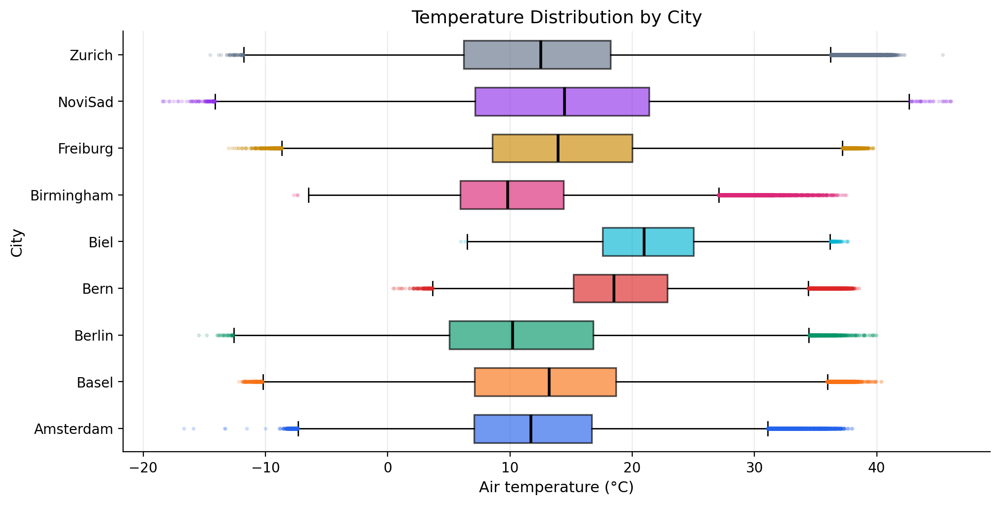

Variables removed successfully: ['plot_data']


In [35]:
# Prepare clean plotting data 
plot_data = merged_clean[["city", "value"]].copy()
plot_data["value"] = pd.to_numeric(plot_data["value"], errors="coerce")
plot_data = plot_data.dropna(subset=["city", "value"])

city_order = sorted(plot_data["city"].unique())

data = [
    plot_data.loc[plot_data["city"] == city, "value"].values
    for city in city_order
]

fig, ax = plt.subplots()

bp = ax.boxplot(
    data,
    tick_labels=city_order,
    **BOXPLOT_KWARGS
)

# Fill only boxes and color only outliers
for i, city in enumerate(city_order):
    color = CITY_COLORS.get(city, "lightgrey")
    bp["boxes"][i].set_facecolor(color)
    bp["fliers"][i].set_markeredgecolor(color)
    bp["fliers"][i].set_markerfacecolor(color)

ax.set_title("Temperature Distribution by City")
ax.set_xlabel("Air temperature (°C)")
ax.set_ylabel("City")
ax.grid(axis="y", visible=False)

plt.show()

cleanup_vars("plot_data")

### 3.4. Missing Values

The remaining data quality issue to manage is missingness, mainly affecting `value`, `altitude_m`, `sensor_height_m`, and `measurement_interval_min`.

In [36]:
show_column_info(
    merged_clean,
    metrics = ["Column", "Missing (%)"],
    name="merged_clean"
)

merged_clean column information:


,Column,Missing (%)
0,city,0.00
1,station_number,0.00
2,datetime,0.00
3,value,33.36
4,lat,0.00
5,lon,0.00
6,altitude_m,53.82
7,sensor_height_m,9.31
8,measurement_interval_min,9.31


#### 3.4.1. City-Level Missing Values

Missing values are not evenly distributed across cities. The target variable `value` shows relatively high missingness in some cities, especially Basel, Amsterdam, and Zurich. However, the missing percentages are not high enough to justify removing an entire city from the analysis.

Metadata-related missingness is more concentrated. `altitude_m` is completely missing for most cities and is available only for Berlin, Novi Sad, and Zurich. Since the goal of the analysis is to build a robust overall model across the European cities considered, this feature is removed from the main modelling dataset because it is not consistently available across cities.

Basel also contains missing values in `sensor_height_m` and `measurement_interval_min`. However, the available non-missing records show only one value for each variable: 3 m for sensor height and 15 minutes for measurement interval. Therefore, these missing entries are interpreted as metadata incompleteness rather than evidence of different station configurations, and they are filled using the modal value within Basel, which in this case corresponds to the only observed value.

At this stage, the only remaining missing variable to address is `value`. Since it is also the target variable, its missingness must be handled with particular care before modelling.

In [37]:
missing_cols = merged_clean.columns[merged_clean.isna().any()].tolist()

missing_by_city = (
    merged_clean
    .groupby("city", observed=True)[missing_cols]
    .apply(lambda x: x.isna().mean() * 100)
    .round(2)
    .sort_values("value", ascending=False)
    .reset_index()
)

print("Missing (%) by city:")
display(missing_by_city)

Missing (%) by city:


,city,value,altitude_m,sensor_height_m,measurement_interval_min
0,Basel,50.54,100.0,32.18,32.18
1,Amsterdam,36.10,100.0,0.00,0.00
2,Zurich,29.56,0.0,0.00,0.00
3,Berlin,22.59,0.0,0.00,0.00
4,NoviSad,21.03,0.0,0.00,0.00
5,Birmingham,18.16,100.0,0.00,0.00
6,Freiburg,13.45,100.0,0.00,0.00
7,Biel,5.69,100.0,0.00,0.00
8,Bern,1.55,100.0,0.00,0.00


In [38]:
basel = merged_clean[merged_clean["city"].eq("Basel")]

for col in ["sensor_height_m", "measurement_interval_min"]:
    print(f"{col} distribution in Basel:")

    dist = (
        basel[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )

    dist["pct"] = dist["count"] / len(basel) * 100
    display(dist.round(2).style.hide(axis="index"))

cleanup_vars("basel")

sensor_height_m distribution in Basel:


sensor_height_m,count,pct
3.000000,3103812,67.820000
nan,1472942,32.180000


measurement_interval_min distribution in Basel:


measurement_interval_min,count,pct
15,3103812,67.820000
,1472942,32.180000


Variables removed successfully: ['basel']


In [39]:
basel_mask = merged_clean["city"].eq("Basel")

for col in ["sensor_height_m", "measurement_interval_min"]:
    fill_value = merged_clean.loc[basel_mask, col].mode(dropna=True).iloc[0]
    merged_clean.loc[basel_mask, col] = (
        merged_clean.loc[basel_mask, col].fillna(fill_value)
    )

    assert merged_clean.loc[basel_mask, col].isna().sum() == 0
    print(f"[{col}] (Basel) filled successfully.")

merged_clean = drop_columns_checked(
    merged_clean,
    columns=["altitude_m"]
)

[sensor_height_m] (Basel) filled successfully.
[measurement_interval_min] (Basel) filled successfully.
Columns dropped successfully: ['altitude_m']


#### 3.4.2. Station-Level Missing Values

Stations whose target missingness exceeds the seventh-decile threshold are removed, which approximately corresponds to stations missing more than 40% of `value` observations. This excludes the 202 least complete stations, corresponding to about 36% of the observations. The remaining stations still account for roughly two thirds of the original observations and are considered sufficiently complete for limited imputation.

In [40]:
check_cols = ["value"]

station_missing = (
    merged_clean
    .groupby(["city", "station_number"], observed=True)
    .agg(
        observations=("datetime", "size"),
        value_missing_pct=("value", lambda x: x.isna().mean() * 100),
        sensor_height_missing_pct=("sensor_height_m", lambda x: x.isna().mean() * 100),
        measurement_interval_missing_pct=("measurement_interval_min", lambda x: x.isna().mean() * 100),
    )
    .round(2)
    .reset_index()
)

# Define quantiles based on station-level missingness in value
station_missing["value_missing_quantile"] = pd.qcut(
    station_missing["value_missing_pct"],
    q=10,
    duplicates="drop"
)

# Count stations and observations in each quantile
quantile_summary = (
    station_missing
    .groupby("value_missing_quantile", observed=True)
    .agg(
        stations=("station_number", "count"),
        observations=("observations", "sum")
    )
    .reset_index()
)

# Cumulative frequencies
quantile_summary["station_cum_freq_pct"] = (
    quantile_summary["stations"] / quantile_summary["stations"].sum() * 100
).cumsum()

quantile_summary["observation_cum_freq_pct"] = (
    quantile_summary["observations"] / quantile_summary["observations"].sum() * 100
).cumsum()

# Keep only relevant columns
quantile_summary = quantile_summary[
    [
        "value_missing_quantile",
        "stations",
        "station_cum_freq_pct",
        "observations",
        "observation_cum_freq_pct"
    ]
]

print("Station-level missing values:")
display(quantile_summary.round(2))

Station-level missing values:


,value_missing_quantile,stations,station_cum_freq_pct,observations,observation_cum_freq_pct
0,"(0.109, 0.3]",71,10.58,588537,3.72
1,"(0.3, 3.72]",64,20.12,1200506,11.31
2,"(3.72, 11.36]",67,30.10,1400259,20.17
3,"(11.36, 20.36]",67,40.09,1834549,31.77
4,"(20.36, 26.67]",67,50.07,1715979,42.62
5,"(26.67, 32.09]",67,60.06,1791998,53.95
6,"(32.09, 39.17]",66,69.90,1614681,64.16
7,"(39.17, 46.55]",68,80.03,2209271,78.13
8,"(46.55, 65.92]",67,90.01,1786721,89.42
9,"(65.92, 100.0]",67,100.00,1672547,100.00


In [41]:
threshold = station_missing["value_missing_pct"].quantile(0.7)

# Identify stations above the missingness threshold
bad_stations = station_missing.loc[
    station_missing["value_missing_pct"] > threshold,
    ["city", "station_number"]
]

# Remove all observations belonging to those stations
bad_station_index = pd.MultiIndex.from_frame(bad_stations)
row_index = pd.MultiIndex.from_frame(merged_clean[["city", "station_number"]])

drop_mask = row_index.isin(bad_station_index)

rows_before = len(merged_clean)
rows_removed = drop_mask.sum()
rows_removed_pct = rows_removed / rows_before * 100

merged_clean = merged_clean.loc[~drop_mask].copy()

print(f"Stations removed: {len(bad_stations):,}")
print(f"Rows removed:     {rows_removed:,}")
print(f"Rows removed %:   {rows_removed_pct:.2f}%")
print(f"Rows remaining:   {len(merged_clean):,}")

Stations removed: 202
Rows removed:     5,668,539
Rows removed %:   35.84%
Rows remaining:   10,146,509


#### 3.4.3. Final Target Missingness Removal

Temperature values missing for exactly one hour are imputed using the average of the previous and next valid observations within the same city–station time series. This rule is applied only when both neighbouring timestamps are valid and exactly one hour apart, ensuring that only isolated one-hour gaps are filled.

After this conservative interpolation step, over 50,000 missing values are recovered. This number is relatively small compared with the number of removed rows because the interpolation rule is intentionally strict, ensuring that only highly reliable and realistic values are added to the dataset.

Longer gaps are left as `NaN` and then removed from the modelling dataset, since filling extended missing periods would require reconstructing temperatures over intervals with uncertain sensor reliability. This final removal excludes over 1.8 million rows, corresponding to 18.35% of the remaining dataset, leaving about 8.3 million observations for analysis.

After this step, no additional imputation will be needed in the model training phase.

In [42]:
# Sort before interpolation
merged_clean = merged_clean.sort_values(["city", "station_number", "datetime"]).copy()

rows_before_removal = len(merged_clean)
missing_before = merged_clean["value"].isna().sum()

g = merged_clean.groupby(["city", "station_number"], observed=True)

prev_value = g["value"].shift(1)
next_value = g["value"].shift(-1)

prev_time = g["datetime"].shift(1)
next_time = g["datetime"].shift(-1)

# Fill only isolated one-hour gaps between two valid neighbouring values
single_hour_gap = (
    merged_clean["value"].isna()
    & prev_value.notna()
    & next_value.notna()
    & ((merged_clean["datetime"] - prev_time) == pd.Timedelta(hours=1))
    & ((next_time - merged_clean["datetime"]) == pd.Timedelta(hours=1))
)

merged_clean.loc[single_hour_gap, "value"] = (
    prev_value[single_hour_gap] + next_value[single_hour_gap]
) / 2

missing_after = merged_clean["value"].isna().sum()

# Remove remaining missing target values
merged_clean = merged_clean.dropna(subset=["value"]).copy()

rows_removed = rows_before_removal - len(merged_clean)
rows_removed_pct = rows_removed / rows_before_removal * 100

missing_cols = merged_clean.columns[merged_clean.isna().any()].tolist()

assert not missing_cols, (f"Missing values remain in the cleaned dataset: {missing_cols}")
print("No missing values remain in the cleaned dataset.\n")

print(f"Values filled:            {missing_before - missing_after:,}")
print(f"Rows removed:             {rows_removed:,}")
print(f"Rows removed %:           {rows_removed_pct:.4f}%")
print(f"Rows after removal:       {len(merged_clean):,}")

No missing values remain in the cleaned dataset.

Values filled:            52,310
Rows removed:             1,862,271
Rows removed %:           18.3538%
Rows after removal:       8,284,238


### 3.5. Time Window and City Selection

This section defines the temporal and city scope of the modelling dataset. The goal is to retain a period where multiple cities are observed at the same time and where each retained city has sufficiently representative seasonal coverage. First, temporal overlap is checked to identify a common modelling window. Then, seasonal coverage is inspected to verify that city-specific temperature distributions and percentile-based heat-risk thresholds are not biased by observations concentrated only in specific months.

#### 3.5.1. Temporal Coverage by City

After the main data-cleaning steps, the preprocessing stage defines the temporal scope of the modelling dataset. Temporal coverage is assessed to select a period in which several cities are observed at the same time. This is important because the final model is pooled across cities: although the `city` feature controls for average city-level differences, a period dominated by only one or two cities could still make the estimated drivers partly reflect city-specific data availability rather than stable cross-city heat-risk patterns.

As a first broad filter, the dataset is restricted to the period from **1 January 2019 to 31 December 2022**. This window is selected from the temporal coverage diagnostics because it contains the densest overlap across the retained cities. This step excludes cities with insufficient or non-overlapping coverage in the selected period, namely **Biel**, **Novi Sad**, and **Freiburg**.

However, a city may have a first and last observation within the selected period while still having poor coverage in the months between. For this reason, coverage is also evaluated at the **city-month level**. A city is considered represented in a given month if it has a sufficient share of the expected hourly observations across its retained stations. Alternative completeness thresholds (20%, 40%, 60%, and 80%) are compared to assess how stricter or looser definitions of city-month availability affect the number of cities represented over time.

The 80% completeness threshold is considered too strict for this dataset, especially after the previous conservative cleaning and interpolation steps. Lower thresholds provide a more realistic picture of usable coverage and show that the strongest simultaneous city coverage occurs between the start of **2020** and the end of **2021**. Coverage remains meaningful in **2022**, so this year is retained at this stage to preserve a longer modelling window and allow flexibility when defining the final train/test split.

At this stage, the candidate modelling dataset is therefore restricted to the period from **1 January 2020 to 31 December 2022** and includes six cities: **Amsterdam, Basel, Berlin, Bern, Birmingham, and Zurich**. This choice balances two objectives: retaining a sufficiently long continuous period and maximising simultaneous cross-city coverage. It avoids early and late periods where only a small subset of cities is available, while preserving enough observations for robust model training and evaluation.

After applying the temporal and city filters, the candidate modelling dataset contains almost **5.8 million observations**. A further seasonal coverage check is then performed in the next subsection to verify whether each retained city has observations distributed across the year in a representative way.


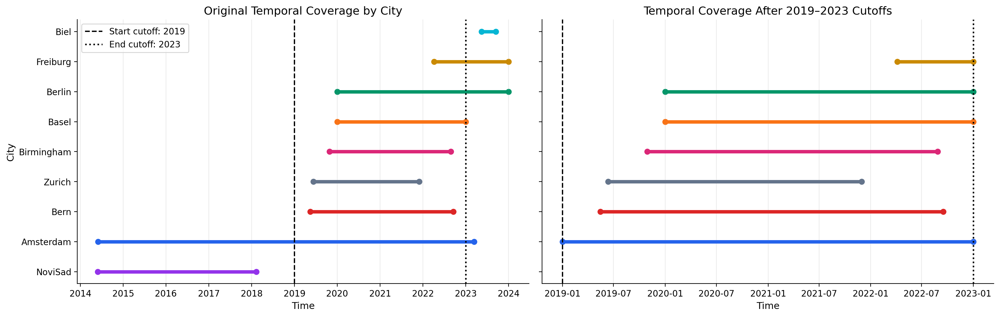

In [43]:
start_cutoff_date = pd.Timestamp("2019-01-01")
end_cutoff_date = pd.Timestamp("2023-01-01")

assert start_cutoff_date < end_cutoff_date, "Start cutoff date must be before end cutoff date."

# Original coverage 
city_coverage = (
    merged_clean
    .groupby("city", observed=True)
    .agg(
        start_date=("datetime", "min"),
        end_date=("datetime", "max"),
        observations=("datetime", "size"),
        stations=("station_number", "nunique")
    )
    .sort_values("start_date")
)

# Coverage after cutoff
city_coverage_cutoff = (
    merged_clean[
        (merged_clean["datetime"] >= start_cutoff_date) &
        (merged_clean["datetime"] <= end_cutoff_date)
    ]
    .groupby("city", observed=True)
    .agg(
        start_date=("datetime", "min"),
        end_date=("datetime", "max")
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Left: original coverage
ax = axes[0]

for i, (city, row) in enumerate(city_coverage.iterrows()):
    color = CITY_COLORS.get(city, "lightgrey")
    ax.plot([row["start_date"], row["end_date"]], [i, i], linewidth=4, color=color)
    ax.scatter(row["start_date"], i, color=color)
    ax.scatter(row["end_date"], i, color=color)

ax.axvline(start_cutoff_date, color="black", linestyle="--", linewidth=1.5, label="Start cutoff: 2019")
ax.axvline(end_cutoff_date, color="black", linestyle=":", linewidth=1.8, label="End cutoff: 2023")

ax.set_yticks(range(len(city_coverage)))
ax.set_yticklabels(city_coverage.index)
ax.set_xlabel("Time")
ax.set_ylabel("City")
ax.set_title("Original Temporal Coverage by City")
ax.grid(axis="y", visible=False)
ax.legend()

# Right: coverage after cutoffs
ax = axes[1]

for i, city in enumerate(city_coverage.index):
    if city in city_coverage_cutoff.index:
        row = city_coverage_cutoff.loc[city]
        color = CITY_COLORS.get(city, "lightgrey")
        
        ax.plot([row["start_date"], row["end_date"]], [i, i], linewidth=4, color=color)
        ax.scatter(row["start_date"], i, color=color)
        ax.scatter(row["end_date"], i, color=color)

ax.axvline(start_cutoff_date, color="black", linestyle="--", linewidth=1.5)
ax.axvline(end_cutoff_date, color="black", linestyle=":", linewidth=1.8)

ax.set_xlabel("Time")
ax.set_title("Temporal Coverage After 2019–2023 Cutoffs")
ax.grid(axis="y", visible=False)

plt.show()

In [44]:
selected_cities = [
    "Amsterdam",
    "Bern",
    "Zurich",
    "Birmingham",
    "Basel",
    "Berlin"
]

rows_before = len(merged_clean)

model_data = merged_clean.loc[
    (merged_clean["datetime"] >= start_cutoff_date) &
    (merged_clean["datetime"] < end_cutoff_date) &
    (merged_clean["city"].isin(selected_cities))
].copy()

rows_removed = rows_before - len(model_data)
rows_removed_pct = rows_removed / rows_before * 100

print(f"Rows removed:       {rows_removed:,}")
print(f"Rows removed %:     {rows_removed_pct:.4f}%")
print(f"Rows remaining:     {len(model_data):,}")
print(f"Cities retained:    {model_data['city'].nunique()}\n")

print("Measurement time span by city:")
display(
    model_data
    .groupby("city", observed=True)
    .agg(
        observations=("datetime", "size"),
        stations=("station_number", "nunique"),
        start_date=("datetime", "min"),
        end_date=("datetime", "max")
    )
)

cleanup_vars("merged_clean")

Rows removed:       1,741,116
Rows removed %:     21.0172%
Rows remaining:     6,543,122
Cities retained:    6

Measurement time span by city:


,observations,stations,start_date,end_date
city,,,,
Amsterdam,227041,10,2019-01-01 00:00:00,2022-12-31 23:00:00
Basel,1578982,77,2020-01-01 00:00:00,2022-12-31 23:00:00
Berlin,195719,8,2020-01-01 00:00:00,2022-12-31 23:00:00
Bern,642888,55,2019-05-14 22:00:00,2022-09-15 21:00:00
Birmingham,418193,19,2019-10-28 12:00:00,2022-08-26 23:00:00
Zurich,3480299,202,2019-06-11 10:00:00,2021-11-30 00:00:00


Variables removed successfully: ['merged_clean']


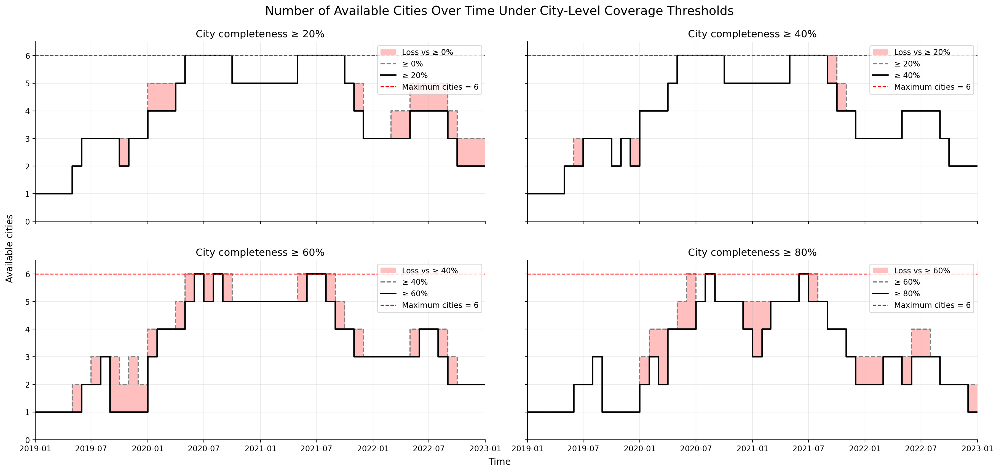

In [45]:
thresholds = [20, 40, 60, 80]
all_thresholds = [0] + thresholds

assert thresholds == sorted(thresholds), "Thresholds must be sorted."
assert all(0 <= t <= 100 for t in all_thresholds), "Thresholds must be between 0 and 100."

# Use the already filtered modelling dataset
df = model_data.copy()
df["month"] = df["datetime"].dt.to_period("M").dt.to_timestamp()

stations_per_city = (
    df.groupby("city", observed=True)["station_number"]
    .nunique()
)

city_month = (
    df.groupby(["city", "month"], observed=True)
    .agg(valid_obs=("value", "count"))
    .reset_index()
)

city_month["stations"] = city_month["city"].map(stations_per_city).astype(int)
city_month["expected_obs"] = (city_month["stations"] * city_month["month"].dt.days_in_month * 24)
city_month["city_completeness_pct"] = (city_month["valid_obs"] / city_month["expected_obs"] * 100)

# Explicit month range: Jan 2019 to Dec 2022
all_months = pd.date_range(
    start=start_cutoff_date,
    end=end_cutoff_date - pd.DateOffset(months=1),
    freq="MS"
)

coverage = {}

for threshold in all_thresholds:
    coverage[threshold] = (
        city_month
        .assign(city_available=city_month["city_completeness_pct"] >= threshold)
        .groupby("month", observed=True)["city_available"]
        .sum()
        .reindex(all_months, fill_value=0)
    )

fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=True, sharey=True, gridspec_kw={"hspace": 0.10})
axes = axes.flatten()

for ax, threshold in zip(axes, thresholds):

    previous_threshold = 0 if threshold == 20 else thresholds[thresholds.index(threshold) - 1]

    current = coverage[threshold]
    previous = coverage[previous_threshold]

    x = current.index.append(pd.DatetimeIndex([end_cutoff_date]))

    current_ext = pd.concat([current, pd.Series(current.iloc[-1], index=[end_cutoff_date])])
    previous_ext = pd.concat([previous, pd.Series(previous.iloc[-1], index=[end_cutoff_date])])

    ax.fill_between(
        x,
        current_ext.values,
        previous_ext.values,
        step="post",
        color="red",
        alpha=0.25,
        linewidth=0,
        label=f"Loss vs ≥ {previous_threshold}%"
    )

    ax.step(
        previous_ext.index,
        previous_ext.values,
        where="post",
        linestyle="--",
        color="gray",
        linewidth=1.5,
        label=f"≥ {previous_threshold}%"
    )

    ax.step(
        current_ext.index,
        current_ext.values,
        where="post",
        color="black",
        linewidth=2,
        label=f"≥ {threshold}%"
    )

    ax.axhline(y=6, color="r", linestyle="--", linewidth=1.2, label="Maximum cities = 6")

    ax.set_title(f"City completeness ≥ {threshold}%")
    ax.set_ylim(0, df["city"].nunique() + 0.5)
    ax.set_xlim(start_cutoff_date, end_cutoff_date)
    ax.legend(loc="upper right")

fig.suptitle("Number of Available Cities Over Time Under City-Level Coverage Thresholds", y=1.05)
fig.supylabel("Available cities")
fig.supxlabel("Time")

plt.show()
cleanup_vars("df", verbose=False)

In [46]:
start_cutoff_date = pd.Timestamp("2020-01-01")
end_cutoff_date = pd.Timestamp("2024-01-01")

assert start_cutoff_date < end_cutoff_date, "Start cutoff date must be before end cutoff date."

rows_before = len(model_data)

model_data = model_data.loc[
    (model_data["city"].isin(selected_cities)) &
    (model_data["datetime"] >= start_cutoff_date) &
    (model_data["datetime"] < end_cutoff_date)
].copy().reset_index(drop=True)

rows_removed = rows_before - len(model_data)
rows_removed_pct = rows_removed / rows_before * 100

print(f"Rows removed:       {rows_removed:,}")
print(f"Rows removed %:     {rows_removed_pct:.4f}%")
print(f"Rows remaining:     {len(model_data):,}")
print(f"Cities retained:    {model_data['city'].nunique()}")

Rows removed:       794,550
Rows removed %:     12.1433%
Rows remaining:     5,748,572
Cities retained:    6


#### 3.5.2. Seasonal Coverage by City

After selecting the broad modelling window, seasonal coverage is inspected at the city level. This check is needed because a city may appear to have sufficient temporal coverage overall, while its observations are concentrated only in specific parts of the year. In that case, the city-specific temperature distribution would not represent a full annual cycle, and percentile-based heat-risk thresholds could be biased.

The diagnostic figure combines three views for each city: the daily mean temperature series, the monthly observation share over time, and the distribution of observations across calendar months. Amsterdam, Basel, Berlin, Birmingham, and Zurich show reasonably broad seasonal coverage, although Amsterdam and Zurich have weaker coverage in the later part of the window. Berlin is the most stable case, with observations distributed relatively evenly across the full period and across months.

Bern is the clear exception. Its observations are concentrated almost entirely between late spring and early autumn, with little or no winter coverage. This means that Bern’s median temperature and percentile thresholds would be estimated from a seasonally biased sample rather than from a complete annual distribution. As a result, high-heat rates for Bern could be distorted, especially if they are interpreted relative to an expected full-year observation period.

Including `city` as a categorical control would not fully solve this issue. The `city` feature can control for average differences between cities, but it cannot correct the fact that Bern’s available observations are concentrated in warmer months. For this reason, Bern is excluded from the main modelling dataset. It could be considered in a separate robustness check or in a summer-specific analysis, but this is outside the scope of the present project.

Zurich is treated differently. Its seasonal distribution is not as problematic as Bern’s, but its observations end before the final year of the selected window. Since the main model uses a chronological split with 2020–2021 for training and 2022 for testing, Zurich cannot be evaluated in the 2022 test set. For this reason, Zurich is not used in the main full-window baseline model. However, it remains useful for alternative temporal-window specifications and can be included later in robustness checks where the train/test periods are adjusted to match its available coverage.

Bern accounted for **8.37%** of the candidate modelling dataset. After removing Bern, the dataset contains over **5.2 million observations** across **5 retained cities**. Among these, Zurich is retained in the candidate dataset for temporal robustness checks, but excluded from the main full-window baseline model.

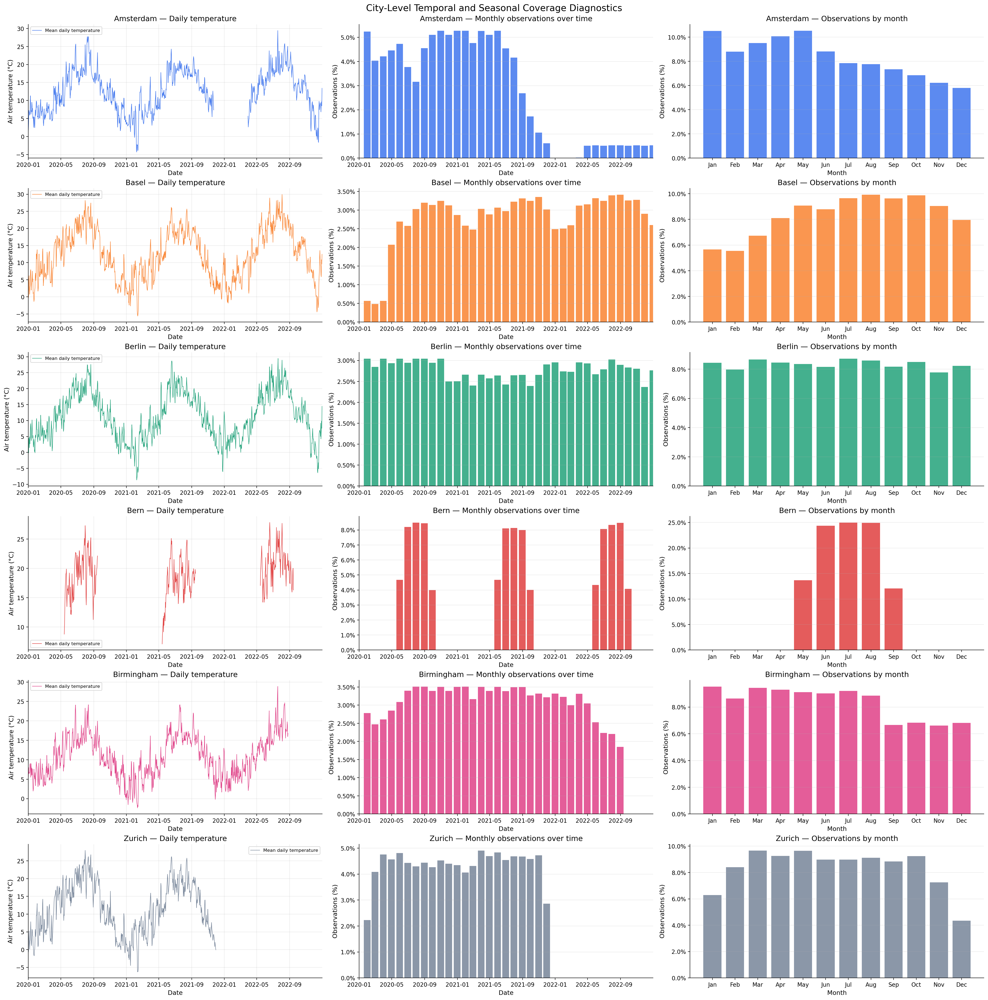

In [47]:
# Global settings
date_min = model_data["datetime"].min()
date_max = model_data["datetime"].max()

cities = sorted(model_data["city"].unique())

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

n_rows = len(cities)
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows), constrained_layout=True)

# Keep axes 2D if only one city
if n_rows == 1:
    axes = np.array([axes])

for i, city in enumerate(cities):

    city_df = model_data.loc[model_data["city"] == city].copy()
    total_city_obs = len(city_df)
    color = CITY_COLORS.get(city, "gray")

    # 1. Daily temperature time series
    daily_temp = (
        city_df
        .set_index("datetime")
        .resample("D")["value"]
        .mean()
        .reset_index()
    )

    ax = axes[i, 0]

    ax.plot(
        daily_temp["datetime"],
        daily_temp["value"],
        color=color,
        linewidth=0.8,
        alpha=0.85,
        label="Mean daily temperature"
    )

    ax.set_xlim(date_min, date_max)
    ax.set_title(f"{city} — Daily temperature")
    ax.set_xlabel("Date")
    ax.set_ylabel("Air temperature (°C)")
    ax.legend(fontsize=8)

    # 2. Monthly observation share over time
    monthly_counts = (
        city_df
        .set_index("datetime")
        .resample("ME")
        .size()
        .reset_index(name="n_observations")
    )

    monthly_counts["pct_observations"] = (monthly_counts["n_observations"] / total_city_obs * 100)

    ax = axes[i, 1]

    ax.bar(
        monthly_counts["datetime"],
        monthly_counts["pct_observations"],
        color=color,
        width=25,
        alpha=0.75
    )

    ax.set_xlim(date_min, date_max)
    ax.set_title(f"{city} — Monthly observations over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Observations (%)")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.grid(axis="x", visible=False)

    # 3. Observation share by calendar month
    city_df["month_name"] = city_df["datetime"].dt.strftime("%b")

    month_counts = (
        city_df
        .groupby("month_name", observed=True)
        .size()
        .reindex(month_order)
        .fillna(0)
        .reset_index(name="n_observations")
        .rename(columns={"month_name": "month"})
    )

    month_counts["pct_observations"] = (
        month_counts["n_observations"] / total_city_obs * 100
    )

    ax = axes[i, 2]

    ax.bar(
        month_counts["month"],
        month_counts["pct_observations"],
        color=color,
        alpha=0.75
    )

    ax.set_title(f"{city} — Observations by month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Observations (%)")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x")

fig.suptitle("City-Level Temporal and Seasonal Coverage Diagnostics",y=1.01, fontsize=16)

plt.show()

cleanup_vars(
    "city_df",
    "daily_temp",
    "monthly_counts",
    "month_counts",
    verbose=False
)

In [48]:
rows_before = len(model_data)

model_data = (
    model_data
    .loc[model_data["city"] != "Bern"]
    .copy()
    .reset_index(drop=True)
)

rows_removed = rows_before - len(model_data)
rows_removed_pct = rows_removed / rows_before * 100

print(f"Rows removed:       {rows_removed:,}")
print(f"Rows removed %:     {rows_removed_pct:.4f}%")
print(f"Rows remaining:     {len(model_data):,}")
print(f"Cities retained:    {model_data['city'].nunique()}")

Rows removed:       481,300
Rows removed %:     8.3725%
Rows remaining:     5,267,272
Cities retained:    5


### 3.6. Feature Engineering and Target Construction

At this stage, the data cleaning steps are complete and the preprocessing phase begins. This section constructs the variables used in the modelling pipeline, including derived features and the target variable.

The feature engineering choices are defined from the cleaned dataset and documented so that the final modelling dataset is reproducible and aligned with the project question.

#### 3.6.1. Target Variable Definition

Since the analysis is framed as a classification problem, the continuous temperature variable is transformed into a binary target identifying high-heat events. High heat is defined using city-specific percentile thresholds, so that each observation is classified relative to the local temperature distribution of its city rather than against a single absolute temperature cutoff.

The main target definition uses the **90th percentile**, meaning that the hottest 10% of observations within each city are classified as high-heat events. Two alternative definitions are also created for robustness checks: the **85th percentile**, which gives a less strict definition of high heat, and the **95th percentile**, which gives a more extreme definition.

The positive-class share is then checked for each target definition. This verifies that the percentile-based targets produce the expected class imbalance: approximately **15%** positive observations for the 85th percentile, **10%** for the 90th percentile, and **5%** for the 95th percentile.

---

The city-specific thresholds show that the temperature required to be classified as locally extreme varies substantially across cities. Under the 90th percentile definition, Basel has the highest threshold at approximately **23.23°C**, followed by Zurich (**22.61°C**) and Berlin (**22.13°C**). Birmingham has the lowest 90th percentile threshold, around **18.36°C**, while Amsterdam is also lower at approximately **19.80°C**. Similar differences are visible under the 95th percentile: Basel reaches **26.08°C**, Zurich **25.72°C**, and Berlin **25.08°C**, compared with **20.61°C** in Birmingham and **21.99°C** in Amsterdam. This confirms that a single absolute cutoff would not represent the same level of heat exposure across all cities.

The boxplots further support this choice by showing clear differences in temperature distributions across cities. For instance, Bern’s median temperature is close to the value that already corresponds to the 90th percentile in Birmingham and almost to the 90th percentile in Amsterdam. This means that a temperature considered typical in one city may already represent a high-heat event in another. The percentile markers identify the upper tail of each local distribution, while high-temperature observations beyond the boxplot whiskers are retained because they represent potential high-heat events rather than values to be automatically treated as errors.

In [49]:
city_order = sorted(model_data["city"].unique())

data = [
    model_data.loc[model_data["city"] == city, "value"]
    for city in city_order
]

# City-specific percentile thresholds
q85 = model_data.groupby("city", observed=True)["value"].quantile(0.85)
q90 = model_data.groupby("city", observed=True)["value"].quantile(0.90)
q95 = model_data.groupby("city", observed=True)["value"].quantile(0.95)

# Display thresholds
city_percentiles = pd.DataFrame({
    "q85_temperature": q85,
    "q90_temperature": q90,
    "q95_temperature": q95
})

print("Temperature thresholds by city:")
display(city_percentiles.round(2))

# Map thresholds as numeric values
q85_mapped = model_data["city"].map(q85).astype(float)
q90_mapped = model_data["city"].map(q90).astype(float)
q95_mapped = model_data["city"].map(q95).astype(float)

# Create binary target variables without keeping threshold columns
model_data["heat_risk_q85"] = (model_data["value"] >= q85_mapped).astype(int)
model_data["heat_risk_q90"] = (model_data["value"] >= q90_mapped).astype(int)
model_data["heat_risk_q95"] = (model_data["value"] >= q95_mapped).astype(int)

print("model_data preview:")
display(model_data.head())

# Check class balance
target_cols = ["heat_risk_q85", "heat_risk_q90", "heat_risk_q95"]

target_balance = (
    model_data[target_cols]
    .mean()
    .mul(100)
    .rename("positive_class_pct")
    .reset_index()
    .rename(columns={"index": "target"})
)

print("Positive-class balance by target definition:")
display(target_balance.round(2))

Temperature thresholds by city:


,q85_temperature,q90_temperature,q95_temperature
city,,,
Amsterdam,18.42,19.80,21.99
Basel,21.35,23.23,26.08
Berlin,20.08,22.13,25.08
Birmingham,16.87,18.36,20.61
Zurich,20.50,22.61,25.72


model_data preview:


,city,station_number,datetime,value,lat,lon,sensor_height_m,measurement_interval_min,heat_risk_q85,heat_risk_q90,heat_risk_q95
0,Amsterdam,NLD_AMS_2198,2020-01-01 00:00:00,3.52,52.37,4.91,4.0,5,0,0,0
1,Amsterdam,NLD_AMS_2198,2020-01-01 01:00:00,3.05,52.37,4.91,4.0,5,0,0,0
2,Amsterdam,NLD_AMS_2198,2020-01-01 02:00:00,2.58,52.37,4.91,4.0,5,0,0,0
3,Amsterdam,NLD_AMS_2198,2020-01-01 03:00:00,2.15,52.37,4.91,4.0,5,0,0,0
4,Amsterdam,NLD_AMS_2198,2020-01-01 04:00:00,2.09,52.37,4.91,4.0,5,0,0,0


Positive-class balance by target definition:


,target,positive_class_pct
0,heat_risk_q85,15.02
1,heat_risk_q90,10.01
2,heat_risk_q95,5.01


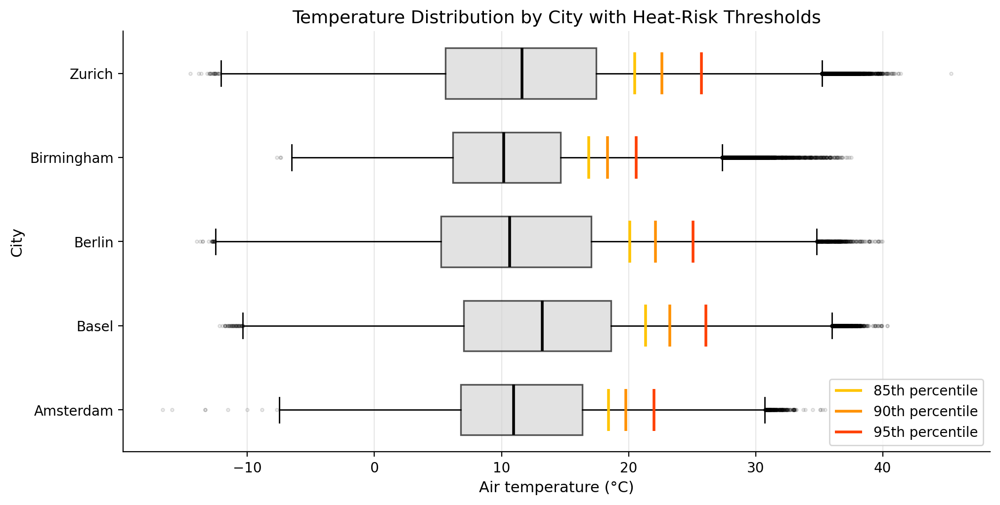

In [50]:
fig, ax = plt.subplots()

bp = ax.boxplot(
    data,
    tick_labels=city_order,
    **BOXPLOT_KWARGS
)

# Add percentile markers
for i, city in enumerate(city_order, start=1):
    q85 = city_percentiles.loc[city, "q85_temperature"]
    q90 = city_percentiles.loc[city, "q90_temperature"]
    q95 = city_percentiles.loc[city, "q95_temperature"]

    ax.vlines(
        x=q85, ymin=i - 0.25, ymax=i + 0.25,
        color="#FFC400", lw=2,
        label="85th percentile" if i == 1 else None
    )

    ax.vlines(
        x=q90, ymin=i - 0.25, ymax=i + 0.25,
        color="#FF9100", lw=2,
        label="90th percentile" if i == 1 else None
    )

    ax.vlines(
        x=q95, ymin=i - 0.25, ymax=i + 0.25,
        color="#FF4000", lw=2,
        label="95th percentile" if i == 1 else None
    )

ax.set_title("Temperature Distribution by City with Heat-Risk Thresholds")
ax.set_xlabel("Air temperature (°C)")
ax.set_ylabel("City")

# Keep only vertical grid lines
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", visible=False)

ax.legend()

plt.show()

#### 3.6.2. Predictor Feature Construction

Several predictor features are constructed from the cleaned station-hour dataset. These features capture temporal patterns, within-city spatial position, and simple calendar effects that may be associated with high heat exposure. Importantly, no predictors are derived from the current temperature value itself, because the target variable is already defined from temperature. Including temperature-based lags or rolling averages could improve predictive performance, but would mainly capture autocorrelation rather than structural heat-risk drivers.

---

Temporal information is extracted from the timestamp through `hour`, `month`, `day_of_week`, and `is_weekend`. The weekend indicator captures possible differences between weekdays and weekends, for example due to changes in urban activity patterns. Hour and month are then transformed into cyclic sine-cosine pairs (`hour_sin`, `hour_cos`, `month_sin`, `month_cos`). This avoids treating cyclical variables as linear: for example, hour 23 and hour 0 are close in time, even though their raw integer values are far apart.

---

Spatial features are constructed by centering latitude and longitude within each city. The variables `lat_centered` and `lon_centered` measure each station’s position relative to the typical station location in the same city, capturing within-city north–south and east–west variation. Broader between-city location and context are controlled separately through the `city` feature. In this setup, absolute geographic position is therefore not ignored, but represented through `city`, while centered coordinates prevent raw latitude and longitude from simply acting as proxies for city identity. The coordinates are centered using the city-specific median rather than the mean, making the transformation less sensitive to spatially isolated stations.

In Zurich, one station appears spatially isolated from the rest of the monitoring network. This station is not removed automatically, because it may still represent a valid observation point. Instead, latitude and longitude are centered using the city-specific median, which reduces the influence of spatial outliers when defining the within-city reference point.

However, this isolated station should be considered a potential source of sensitivity. If it also has a high heat-risk rate, the model could learn that stations in that specific relative position are systematically associated with higher risk, even though this pattern may be driven by a single outlying station rather than a general within-city spatial gradient. Assessing the influence of this station would require an additional robustness check excluding it, but this is outside the scope of the present analysis.

---

The `season` variable is also created from the month. It is mainly used for exploratory analysis, interpretation, and possible robustness checks. The main model can rely on `month_sin` and `month_cos` to represent seasonality more smoothly, while `season` provides a simpler categorical summary useful for plots and descriptive comparisons.

The transformation plots illustrate these choices. The cyclical encoding graphs show that hour and month are mapped onto smooth circular patterns, preserving continuity across midnight and across the end of the year. The spatial plots show the difference between original station coordinates and centered coordinates: original latitude and longitude mainly separate cities geographically, while centered coordinates place all cities around a common origin and highlight relative station positions within each urban network.

In [51]:
# Temporal raw variables
model_data["hour"] = model_data["datetime"].dt.hour
model_data["month"] = model_data["datetime"].dt.month
model_data["day_of_week"] = model_data["datetime"].dt.dayofweek
model_data["is_weekend"] = model_data["day_of_week"].isin([5, 6]).astype(int)

# Cyclical encodings
model_data["hour_sin"] = np.sin(2 * np.pi * model_data["hour"] / 24)
model_data["hour_cos"] = np.cos(2 * np.pi * model_data["hour"] / 24)

model_data["month_sin"] = np.sin(2 * np.pi * model_data["month"] / 12)
model_data["month_cos"] = np.cos(2 * np.pi * model_data["month"] / 12)

# Spatial centering
model_data["lat_centered"] = (
    model_data["lat"] - model_data.groupby("city", observed=True)["lat"].transform("median")
)

model_data["lon_centered"] = (
    model_data["lon"] - model_data.groupby("city", observed=True)["lon"].transform("median")
)

# Season category from month (mainly for EDA and interpretation)
model_data["season"] = model_data["month"].map({
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn"
}).astype("category")

print("model_data preview:")
display(model_data.head())

model_data preview:


,city,station_number,datetime,value,lat,lon,sensor_height_m,measurement_interval_min,heat_risk_q85,heat_risk_q90,...,month,day_of_week,is_weekend,hour_sin,hour_cos,month_sin,month_cos,lat_centered,lon_centered,season
0,Amsterdam,NLD_AMS_2198,2020-01-01 00:00:00,3.52,52.37,4.91,4.0,5,0,0,...,1,2,0,0.000000,1.000000,0.5,0.866025,0.01,0.0,winter
1,Amsterdam,NLD_AMS_2198,2020-01-01 01:00:00,3.05,52.37,4.91,4.0,5,0,0,...,1,2,0,0.258819,0.965926,0.5,0.866025,0.01,0.0,winter
2,Amsterdam,NLD_AMS_2198,2020-01-01 02:00:00,2.58,52.37,4.91,4.0,5,0,0,...,1,2,0,0.500000,0.866025,0.5,0.866025,0.01,0.0,winter
3,Amsterdam,NLD_AMS_2198,2020-01-01 03:00:00,2.15,52.37,4.91,4.0,5,0,0,...,1,2,0,0.707107,0.707107,0.5,0.866025,0.01,0.0,winter
4,Amsterdam,NLD_AMS_2198,2020-01-01 04:00:00,2.09,52.37,4.91,4.0,5,0,0,...,1,2,0,0.866025,0.500000,0.5,0.866025,0.01,0.0,winter


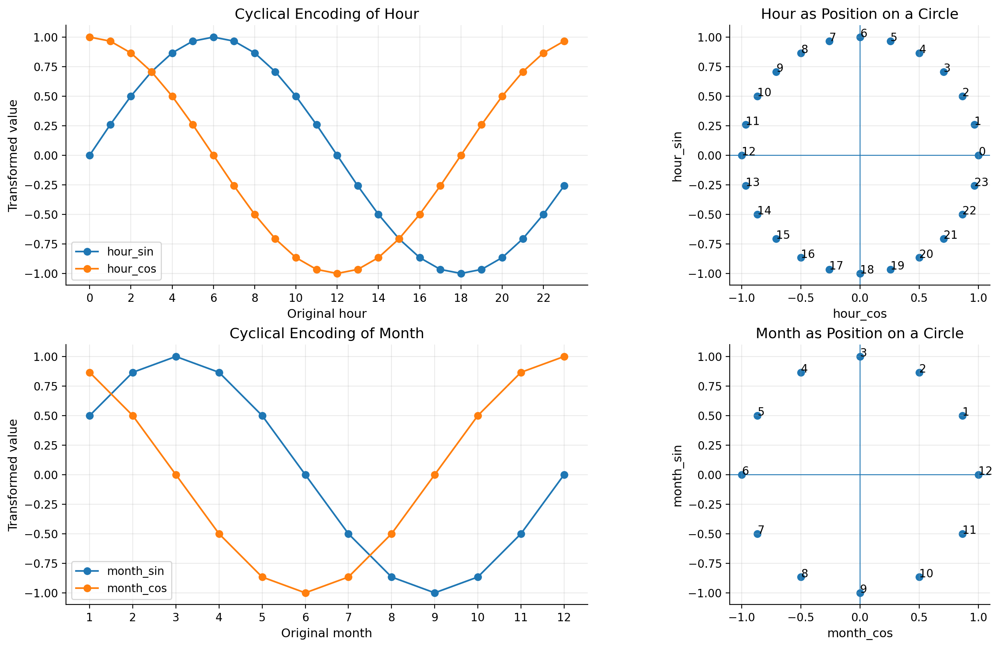

In [52]:
# Representative original values
hours = np.arange(24)
months = np.arange(1, 13)

hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Hour: original vs transformed
axes[0, 0].plot(hours, hour_sin, marker="o", label="hour_sin")
axes[0, 0].plot(hours, hour_cos, marker="o", label="hour_cos")
axes[0, 0].set_title("Cyclical Encoding of Hour")
axes[0, 0].set_xlabel("Original hour")
axes[0, 0].set_ylabel("Transformed value")
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].legend()

# Hour circle
axes[0, 1].scatter(hour_cos, hour_sin)
for h, x, y in zip(hours, hour_cos, hour_sin):
    axes[0, 1].text(x, y, str(h))
axes[0, 1].set_title("Hour as Position on a Circle")
axes[0, 1].set_xlabel("hour_cos")
axes[0, 1].set_ylabel("hour_sin")
axes[0, 1].axhline(0, linewidth=0.8)
axes[0, 1].axvline(0, linewidth=0.8)
axes[0, 1].set_aspect("equal")

# Month: original vs transformed
axes[1, 0].plot(months, month_sin, marker="o", label="month_sin")
axes[1, 0].plot(months, month_cos, marker="o", label="month_cos")
axes[1, 0].set_title("Cyclical Encoding of Month")
axes[1, 0].set_xlabel("Original month")
axes[1, 0].set_ylabel("Transformed value")
axes[1, 0].set_xticks(months)
axes[1, 0].legend()

# Month circle
axes[1, 1].scatter(month_cos, month_sin)
for m, x, y in zip(months, month_cos, month_sin):
    axes[1, 1].text(x, y, str(m))
axes[1, 1].set_title("Month as Position on a Circle")
axes[1, 1].set_xlabel("month_cos")
axes[1, 1].set_ylabel("month_sin")
axes[1, 1].axhline(0, linewidth=0.8)
axes[1, 1].axvline(0, linewidth=0.8)
axes[1, 1].set_aspect("equal")

plt.show()

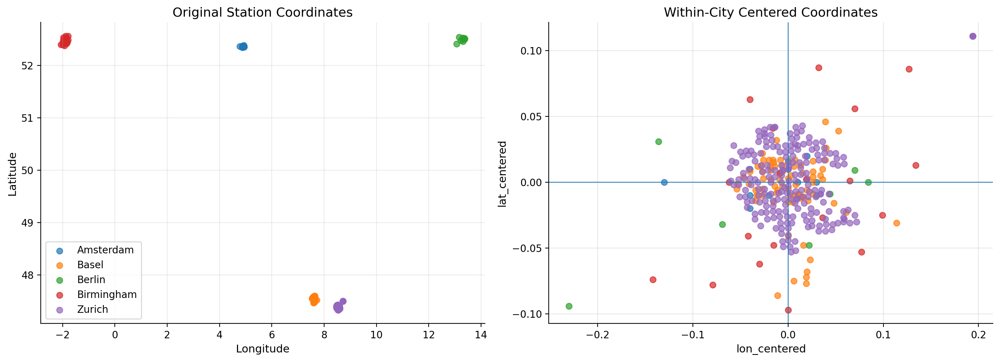

In [53]:
# One point per station for cleaner plotting
station_locations = (
    model_data
    .groupby(["city", "station_number"], observed=True)
    .agg(
        lat=("lat", "first"),
        lon=("lon", "first"),
        lat_centered=("lat_centered", "first"),
        lon_centered=("lon_centered", "first")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original coordinates
for city, data in station_locations.groupby("city", observed=True):
    axes[0].scatter(data["lon"], data["lat"], label=city, alpha=0.7)

axes[0].set_title("Original Station Coordinates")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend()

# Centered coordinates
for city, data in station_locations.groupby("city", observed=True):
    axes[1].scatter(data["lon_centered"], data["lat_centered"], label=city, alpha=0.7)

axes[1].axhline(0, linewidth=0.8)
axes[1].axvline(0, linewidth=0.8)
axes[1].set_title("Within-City Centered Coordinates")
axes[1].set_xlabel("lon_centered")
axes[1].set_ylabel("lat_centered")
axes[1].grid(alpha=0.3)

plt.show()

### 3.7. Final Modelling Dataset

The final candidate modelling dataset contains over **5.2 million station-hour observations** across **22 columns**. It covers **5 retained cities** — Amsterdam, Basel, Berlin, Birmingham, and Zurich — with **316 retained monitoring stations** over the period from **1 January 2020 to 31 December 2022**. However, for the main full-window baseline model, Zurich is excluded because it is not available in the 2022 test period. Therefore, the main model is estimated on **4 cities**: Amsterdam, Basel, Berlin, and Birmingham. Zurich is retained in the candidate dataset only for later temporal-window robustness checks.

The table below describes each variable, its data type, and its role in the analysis.
| Column                     | Description                                                               | Type        | Role                          |
| -------------------------- | ------------------------------------------------------------------------- | ----------- | ----------------------------- |
| `city`                     | City where the station is located                                         | categorical | Feature (city-level control)  |
| `station_number`           | Unique station identifier                                                 | string      | Identifier                    |
| `datetime`                 | Timestamp of the hourly observation                                       | datetime    | Feature source                |
| `value`                    | Hourly mean air temperature (°C)                                          | float       | Target source                 |
| `heat_risk_q85`            | Binary high-heat target based on the city-specific 85th percentile        | int         | Alternative target            |
| `heat_risk_q90`            | Binary high-heat target based on the city-specific 90th percentile        | int         | Main target                   |
| `heat_risk_q95`            | Binary high-heat target based on the city-specific 95th percentile        | int         | Alternative target            |
| `hour`                     | Hour of day extracted from the timestamp                                  | int         | Feature source                |
| `month`                    | Month extracted from the timestamp                                        | int         | Feature source                |
| `day_of_week`              | Day of week extracted from the timestamp, where Monday = 0 and Sunday = 6 | int         | Feature source                |
| `is_weekend`               | Binary indicator equal to 1 for Saturday or Sunday                        | int         | Feature (temporal)            |
| `hour_sin`                 | Sine transformation of hour of day                                        | float       | Feature (temporal)            |
| `hour_cos`                 | Cosine transformation of hour of day                                      | float       | Feature (temporal)            |
| `month_sin`                | Sine transformation of month                                              | float       | Feature (temporal)            |
| `month_cos`                | Cosine transformation of month                                            | float       | Feature (temporal)            |
| `season`                   | Season category derived from month                                        | categorical | EDA / robustness feature      |
| `lat`                      | Station latitude in decimal degrees                                       | float       | Spatial reference             |
| `lon`                      | Station longitude in decimal degrees                                      | float       | Spatial reference             |
| `lat_centered`             | Station latitude minus the city mean latitude                             | float       | Feature (within-city spatial) |
| `lon_centered`             | Station longitude minus the city mean longitude                           | float       | Feature (within-city spatial) |
| `sensor_height_m`          | Height of the sensor above ground in metres                               | float       | Feature (measurement-related) |
| `measurement_interval_min` | Original measurement interval in minutes                                  | integer     | Feature (measurement-related) |

The columns fall into five groups: one city-level control (`city`), one station identifier (`station_number`), one source variable for the target (`value`), three binary target definitions (`heat_risk_q85`, `heat_risk_q90`, `heat_risk_q95`), a set of temporal, spatial, and measurement-related predictors. The main modelling target is `heat_risk_q90`, while `heat_risk_q85` and `heat_risk_q95` are retained for threshold-robustness checks.

A hierarchical structure can be defined using `city`, `station_number`, and `datetime`. This reflects the nested nature of the data: hourly observations are grouped by monitoring station, and stations are grouped within cities. This structure is useful for station-level diagnostics, city-level evaluation, and checking temporal consistency within each monitoring location.

In [54]:
# Final column order for the modelling dataset
final_column_order = [
    "city",
    "station_number",
    "datetime",
    "value",
    "heat_risk_q85",
    "heat_risk_q90",
    "heat_risk_q95",
    "hour",
    "month",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "season",
    "lat",
    "lon",
    "lat_centered",
    "lon_centered",
    "sensor_height_m",
    "measurement_interval_min"
]

model_data = model_data[final_column_order].copy()

# Final dataset summary
final_shape = model_data.shape
final_cities = sorted(model_data["city"].unique())
final_stations = model_data[["city", "station_number"]].drop_duplicates().shape[0]
start_date = model_data["datetime"].min()
end_date = model_data["datetime"].max()

print("Final modelling dataset")
print("-" * 80)
print(f"Rows:              {final_shape[0]:,}")
print(f"Columns:           {final_shape[1]:,}")
print(f"Cities retained:   {len(final_cities)}")
print(f"Stations retained: {final_stations:,}")
print(f"Time horizon:      {start_date}  →  {end_date}\n")

print("Selected cities:")
print(", ".join(final_cities))
print()

show_column_info(
    model_data,
    metrics=["Column", "Data type", "Unique"]
)
print()

print("model_data preview:")
display(model_data.head())

Final modelling dataset
--------------------------------------------------------------------------------
Rows:              5,267,272
Columns:           22
Cities retained:   5
Stations retained: 316
Time horizon:      2020-01-01 00:00:00  →  2022-12-31 23:00:00

Selected cities:
Amsterdam, Basel, Berlin, Birmingham, Zurich

DataFrame column information:


,Column,Data type,Unique
0,city,category,5
1,station_number,string,316
2,datetime,datetime64[ns],26304
3,value,float64,11171
4,heat_risk_q85,int64,2
5,heat_risk_q90,int64,2
6,heat_risk_q95,int64,2
7,hour,int32,24
8,month,int32,12
9,day_of_week,int32,7



model_data preview:


,city,station_number,datetime,value,heat_risk_q85,heat_risk_q90,heat_risk_q95,hour,month,day_of_week,...,hour_cos,month_sin,month_cos,season,lat,lon,lat_centered,lon_centered,sensor_height_m,measurement_interval_min
0,Amsterdam,NLD_AMS_2198,2020-01-01 00:00:00,3.52,0,0,0,0,1,2,...,1.000000,0.5,0.866025,winter,52.37,4.91,0.01,0.0,4.0,5
1,Amsterdam,NLD_AMS_2198,2020-01-01 01:00:00,3.05,0,0,0,1,1,2,...,0.965926,0.5,0.866025,winter,52.37,4.91,0.01,0.0,4.0,5
2,Amsterdam,NLD_AMS_2198,2020-01-01 02:00:00,2.58,0,0,0,2,1,2,...,0.866025,0.5,0.866025,winter,52.37,4.91,0.01,0.0,4.0,5
3,Amsterdam,NLD_AMS_2198,2020-01-01 03:00:00,2.15,0,0,0,3,1,2,...,0.707107,0.5,0.866025,winter,52.37,4.91,0.01,0.0,4.0,5
4,Amsterdam,NLD_AMS_2198,2020-01-01 04:00:00,2.09,0,0,0,4,1,2,...,0.500000,0.5,0.866025,winter,52.37,4.91,0.01,0.0,4.0,5


## 4. Exploratory Data Analysis

This section explores the final modelling dataset before training. The goal is to identify patterns that are directly relevant to the research question: when and where high heat exposure is more likely, whether measurement-related variables may influence the target, and whether any remaining suspicious behaviour should be considered before modelling.

### 4.1 Descriptive Overview

A compact city-level summary of the modelling dataset is provided below. The table reports the number and percentage of observations by city, station coverage, time span, temperature statistics, and heat-risk thresholds.

The distribution of observations across cities is clearly imbalanced. Zurich accounts for about half of the observations, Basel for around one quarter, while the remaining cities contribute much smaller shares; Amsterdam represents only about 2.5% of the dataset. For this reason, city-balanced sample weights will be introduced during the modelling phase – [5.6.3. City-Balanced Sample Weights](#563-city-balanced-sample-weights). These weights will reduce the risk that the pooled model learns mainly from the most represented cities and gives them a disproportionate influence on the final predictions.

Overall, the descriptive overview confirms that the modelling dataset spans diverse cities, temperature regimes, and time periods, providing a reasonable basis for the subsequent exploratory analysis.

In [55]:
city_overview = (
    model_data
    .groupby("city", observed=True)
    .agg(
        observations=("datetime", "size"),
        observation_pct=("datetime", lambda x: len(x) / len(model_data) * 100),
        stations=("station_number", "nunique"),
        start_date=("datetime", "min"),
        end_date=("datetime", "max"),
        mean_temp=("value", "mean"),
        median_temp=("value", "median"),
        min_temp=("value", "min"),
        max_temp=("value", "max"),
        heat_risk_q90_value=("value", lambda x: x.quantile(0.90)),
        heat_risk_q90_pct=("heat_risk_q90", lambda x: x.mean() * 100)
    )
    .reset_index()
    .sort_values("observations", ascending=False)
)

city_overview = city_overview.round({
    "observation_pct": 2,
    "mean_temp": 2,
    "median_temp": 2,
    "min_temp": 2,
    "max_temp": 2,
    "heat_risk_q90_pct": 2
})

print("City-level descriptive overview:")
display(city_overview)

City-level descriptive overview:


,city,observations,observation_pct,stations,start_date,end_date,mean_temp,median_temp,min_temp,max_temp,heat_risk_q90_value,heat_risk_q90_pct
4,Zurich,2948497,55.98,202,2020-01-01,2021-11-30 00:00:00,11.84,11.60,-14.51,45.37,22.61,10.02
1,Basel,1578982,29.98,77,2020-01-01,2022-12-31 23:00:00,13.04,13.20,-12.18,40.38,23.23,10.00
3,Birmingham,402850,7.65,19,2020-01-01,2022-08-26 23:00:00,10.55,10.17,-7.70,37.52,18.36,10.00
2,Berlin,195719,3.72,8,2020-01-01,2022-12-31 23:00:00,11.32,10.65,-13.98,39.99,22.13,10.01
0,Amsterdam,141224,2.68,10,2020-01-01,2022-12-31 23:00:00,11.54,10.96,-16.67,35.45,19.80,10.02


### 4.2. Temporal Patterns

This section examines how high-heat risk varies across time. The goal is to understand whether high-heat events are concentrated in specific seasons, months, hours of the day, or calendar conditions such as weekdays and weekends. These checks help justify the use of cyclic temporal predictors, such as `hour_sin`, `hour_cos`, `month_sin`, and `month_cos`, in the baseline model.

#### 4.2.1. Seasonal and Calendar Patterns

The seasonal distribution confirms that high-heat events occur mainly in summer across all cities, with smaller shares in spring and autumn. This supports the use of month-based cyclic features (`month_sin`, `month_cos`) to capture seasonal variation, while `season` is kept only as an interpretive EDA variable.

The standardized weekday/weekend comparison shows weaker differences: most cities are close to an equal split between weekdays and weekends. This suggests that `is_weekend` is unlikely to be a dominant predictor, but it is retained as a simple calendar control.

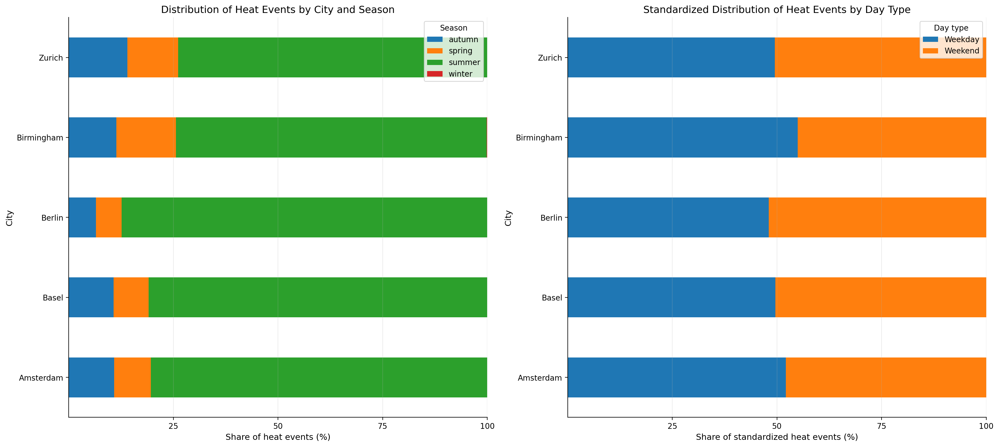

In [56]:
city_col = "city"
temp_col = "value"
target_col = "heat_risk_q90"

city_order = city_percentiles.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Heat-event share by city and season
# Heat-event distribution by city and season
season_table = (
    model_data[model_data[target_col] == 1]
    .groupby([city_col, "season"], observed=True)
    .size()
    .unstack(fill_value=0)
    .loc[city_order]
)

season_table_pct = season_table.div(season_table.sum(axis=1), axis=0) * 100

season_table_pct.plot(
    kind="barh",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Heat Events by City and Season")
axes[0].set_xlabel("Share of heat events (%)")
axes[0].set_ylabel("City")
axes[0].set_xlim(0, 100)
axes[0].set_xticks([25, 50, 75, 100])
axes[0].grid(axis="y", visible=False)
axes[0].legend(title="Season")


# 2. Standardized heat events by weekday/weekend
weekday_table = (
    model_data[model_data[target_col] == 1]
    .assign(day_type=model_data["is_weekend"].map({0: "Weekday", 1: "Weekend"}))
    .groupby([city_col, "day_type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .loc[city_order]
)

weekday_table["Weekday"] = weekday_table["Weekday"] / 5
weekday_table["Weekend"] = weekday_table["Weekend"] / 2

weekday_table_pct = weekday_table.div(weekday_table.sum(axis=1), axis=0) * 100

weekday_table_pct.plot(
    kind="barh",
    stacked=True,
    ax=axes[1]
)

axes[1].set_title("Standardized Distribution of Heat Events by Day Type")
axes[1].set_xlabel("Share of standardized heat events (%)")
axes[1].set_ylabel("City")
axes[1].set_xlim(0, 100)
axes[1].set_xticks([25, 50, 75, 100])
axes[1].grid(axis="y", visible=False)
axes[1].legend(title="Day type")

plt.show()

#### 4.2.2. Hourly and Monthly Patterns of High-Heat Risk

The graph below examines how high-heat risk varies across months and hours of the day. The rates are computed within each city as the percentage of station-hour observations classified as high heat under the main `heat_risk_q90` target. This ensures that the city-specific lines are not directly affected by differences in total observation counts across cities.

The monthly pattern shows a clear seasonal structure, confirming the previous result. High-heat risk is concentrated in the summer months, with the city-balanced average peaking in August. This confirms that high-heat events are strongly seasonal.

The hourly pattern shows a clear daily cycle. High-heat risk increases during the morning, peaks around 14:00, and decreases during the evening and night. This confirms that high-heat events are also strongly related to the time of day.

Overall, the temporal patterns are consistent across cities, although the intensity varies by location. The results support using cyclic month and hour encodings rather than treating time as a simple linear variable.

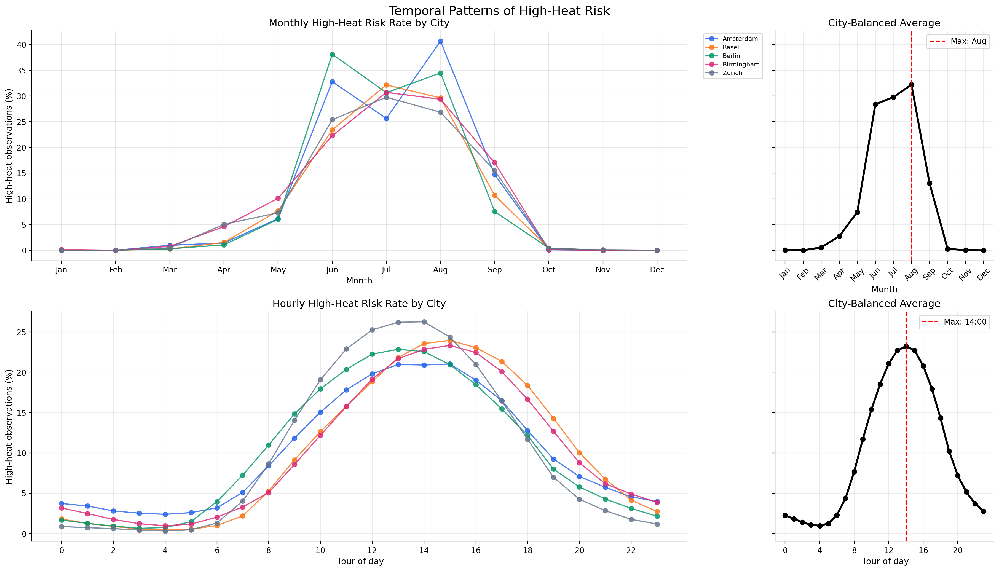

In [57]:
month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

# Monthly heat-risk rate by city
city_month_risk = (
    model_data
    .groupby(["city", "month"], observed=True)
    .agg(
        heat_risk_rate_pct=(target_col, lambda x: x.mean() * 100),
        observations=(target_col, "size")
    )
    .reset_index()
)

monthly_macro_risk = (
    city_month_risk
    .groupby("month", observed=True)
    .agg(heat_risk_rate_pct=("heat_risk_rate_pct", "mean"))
    .reset_index()
)

# Hourly heat-risk rate by city
city_hour_risk = (
    model_data
    .groupby(["city", "hour"], observed=True)
    .agg(
        heat_risk_rate_pct=(target_col, lambda x: x.mean() * 100),
        observations=(target_col, "size")
    )
    .reset_index()
)

hourly_macro_risk = (
    city_hour_risk
    .groupby("hour", observed=True)
    .agg(heat_risk_rate_pct=("heat_risk_rate_pct", "mean"))
    .reset_index()
)

max_month = monthly_macro_risk.loc[monthly_macro_risk["heat_risk_rate_pct"].idxmax(), "month"]
max_hour = hourly_macro_risk.loc[hourly_macro_risk["heat_risk_rate_pct"].idxmax(), "hour"]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 10),
    gridspec_kw={"width_ratios": [3, 1]}, sharey="row"
)

# Row 1: Monthly pattern
ax = axes[0, 0]

for city in sorted(city_month_risk["city"].unique()):
    data = city_month_risk[city_month_risk["city"] == city]
    
    ax.plot(
        data["month"],
        data["heat_risk_rate_pct"],
        marker="o", linewidth=1.5, alpha=0.8,
        color=CITY_COLORS.get(city, "gray"), label=city
    )

ax.set_title("Monthly High-Heat Risk Rate by City")
ax.set_xlabel("Month")
ax.set_ylabel("High-heat observations (%)")
ax.set_xticks(list(month_labels.keys()))
ax.set_xticklabels(list(month_labels.values()))
ax.grid(alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

ax = axes[0, 1]

ax.plot(
    monthly_macro_risk["month"],
    monthly_macro_risk["heat_risk_rate_pct"],
    marker="o", linewidth=2.5, color="black"
)

# Monthly average plot
ax.axvline(max_month, color="red", linestyle="--", linewidth=1.5, label=f"Max: {month_labels[max_month]}")

ax.set_title("City-Balanced Average")
ax.set_xlabel("Month")
ax.set_xticks(list(month_labels.keys()))
ax.set_xticklabels(list(month_labels.values()), rotation=45)
ax.legend()

# Row 2: Hourly pattern
ax = axes[1, 0]

for city in sorted(city_hour_risk["city"].unique()):
    data = city_hour_risk[city_hour_risk["city"] == city]
    
    ax.plot(
        data["hour"],
        data["heat_risk_rate_pct"],
        marker="o", linewidth=1.5, alpha=0.8,
        color=CITY_COLORS.get(city, "gray"), label=city
    )

ax.set_title("Hourly High-Heat Risk Rate by City")
ax.set_xlabel("Hour of day")
ax.set_ylabel("High-heat observations (%)")
ax.set_xticks(range(0, 24, 2))

ax = axes[1, 1]

ax.plot(
    hourly_macro_risk["hour"],
    hourly_macro_risk["heat_risk_rate_pct"],
    marker="o", linewidth=2.5, color="black"
)

# Hourly average plot
ax.axvline(max_hour, color="red", linestyle="--", linewidth=1.5, label=f"Max: {max_hour}:00")

ax.set_title("City-Balanced Average")
ax.set_xlabel("Hour of day")
ax.set_xticks(range(0, 24, 4))
ax.legend()

fig.suptitle("Temporal Patterns of High-Heat Risk", y=1.02)

plt.show()

### 4.3 Spatial Patterns

This section examines how monitoring stations are distributed across space and whether high-heat risk varies within cities. The goal is to check whether station location may help explain differences in heat exposure across the urban monitoring networks.

Raw latitude and longitude are used only for spatial inspection. They are not used directly as numeric predictors because the retained cities are geographically clustered in distinct locations, so raw coordinates would mainly act as proxies for city identity. Between-city spatial context is therefore represented through the city categorical feature.

The station-level spatial analysis focuses instead on within-city variation. For this reason, the model uses median-centered latitude and longitude, which measure each station’s relative position within its own city while reducing the influence of spatially isolated stations.

#### 4.3.1. Spatial Distribution of Monitoring Stations

The map shows the geographic location of the retained monitoring stations across the selected cities. Overall, the stations are located in distinct urban areas across Northern and Central Europe, confirming that the dataset contains multiple urban contexts rather than observations from a single region only. The map is used as a spatial sanity check before modelling and supports the later use of `city` as a categorical control and within-city centered coordinates as spatial predictors.

In [58]:
# One row per station
station_locations = (
    model_data
    .groupby(["city", "station_number"], observed=True)
    .agg(
        lat=("lat", "first"),
        lon=("lon", "first")
    )
    .reset_index()
    .dropna(subset=["lat", "lon"])
)

# Map center
map_center = [
    station_locations["lat"].mean(),
    station_locations["lon"].mean()
]

station_locations_map = folium.Map(
    location=map_center,
    zoom_start=5,
    tiles="CartoDB positron"
)

# Add stations
for _, row in station_locations.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        color=CITY_COLORS.get(row["city"], "gray"),
        fill=True,
        fill_color=CITY_COLORS.get(row["city"], "gray"),
        fill_opacity=0.75,
        popup=f"{row['city']} — station {row['station_number']}"
    ).add_to(station_locations_map)

display(station_locations_map)

# NOTE: If map does not appear uncomment and run this
# from IPython.display import IFrame
# 
# location = "./station_locations_map.html"
# 
# station_locations_map.save(location)
# 
# IFrame(
#     src=location,
#     width="100%",
#     height=600
# )

#### 4.3.2. Station-Level Spatial Pattern of High-Heat Risk

This figure examines whether high-heat risk varies across monitoring stations within each city. The data are aggregated at station level, so each point represents one monitoring station rather than one hourly observation. The plotted value is the percentage of observations at that station classified as high heat under the main `heat_risk_q90` target.

The results show that high-heat risk is not uniform within cities: some stations have higher heat-risk rates than others. However, the plots do not show a clear or consistent latitude-longitude gradient across cities. This means that spatial position may still contain useful information, but the relationship does not appear to be a simple north-south or east-west pattern.

Zurich and Basel provide the clearest station-level view because they have the largest number of monitoring locations. In Zurich, one station is spatially isolated from the main cluster, so its influence should be interpreted cautiously. Amsterdam and Berlin have fewer stations, making their spatial patterns less reliable for interpretation.

Overall, the figure supports keeping within-city spatial features in the modelling framework, but also suggests caution when interpreting spatial effects. Some station-level differences may reflect local urban conditions, while others may be influenced by uneven temporal coverage. In particular, stations with more observations during summer months may show inflated heat-risk rates. For this reason, station-level coverage by city is examined at the end of this section as an additional diagnostic check.

City-level spatial differences are not analysed as a separate numeric gradient because the retained cities are geographically clustered in distinct locations. Raw latitude and longitude would mainly act as proxies for city identity. For this reason, between-city spatial context is represented through the `city` categorical feature, while within-city spatial variation is captured through median-centered coordinates.

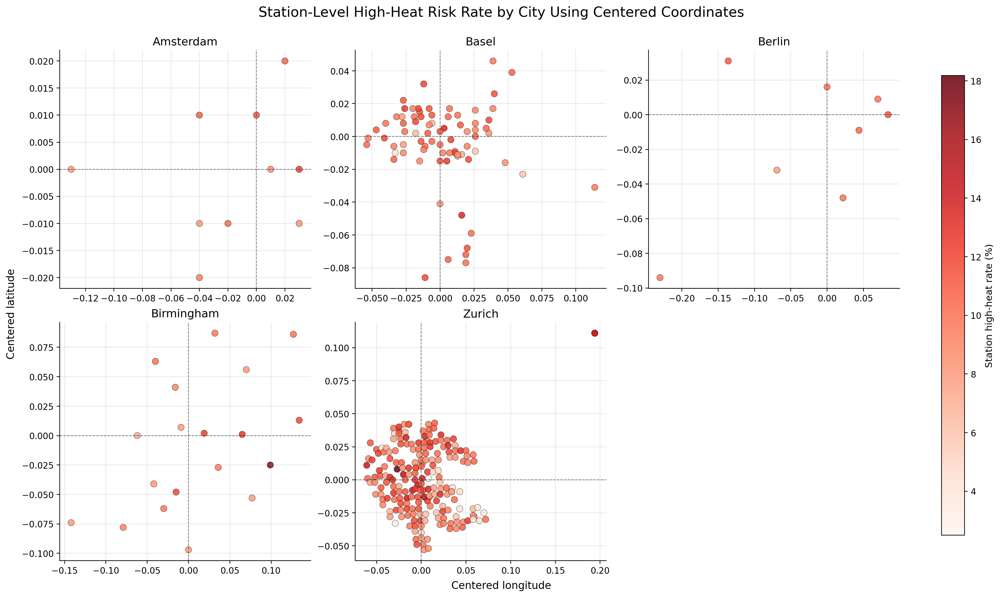

In [59]:
# Station-level heat-risk rate using centered coordinates
station_risk_centered = (
    model_data
    .groupby(["city", "station_number"], observed=True)
    .agg(
        lat_centered=("lat_centered", "first"),
        lon_centered=("lon_centered", "first"),
        observations=(target_col, "size"),
        heat_risk_rate_pct=(target_col, lambda x: x.mean() * 100)
    )
    .reset_index()
)

cities = sorted(station_risk_centered["city"].unique())

n_cols = 3
n_rows = int(np.ceil(len(cities) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(16, 4.5 * n_rows),
    sharex=False, sharey=False, constrained_layout=True
)

axes = axes.flatten()

vmin = station_risk_centered["heat_risk_rate_pct"].min()
vmax = station_risk_centered["heat_risk_rate_pct"].max()

for ax, city in zip(axes, cities):
    data = station_risk_centered[station_risk_centered["city"] == city]

    sc = ax.scatter(
        data["lon_centered"],
        data["lat_centered"],
        c=data["heat_risk_rate_pct"], cmap="Reds",
        vmin=vmin, vmax=vmax,
        s=55, edgecolor="black", linewidth=0.3, alpha=0.85
    )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

    ax.set_title(city)
    ax.grid(alpha=0.3)

# Remove unused axes if number of cities is not multiple of n_cols
for ax in axes[len(cities):]:
    ax.remove()

fig.colorbar(
    sc,
    ax=axes[:len(cities)],
    label="Station high-heat rate (%)",
    shrink=0.9
)

fig.supxlabel("Centered longitude")
fig.supylabel("Centered latitude")

fig.suptitle("Station-Level High-Heat Risk Rate by City Using Centered Coordinates", y=1.05)

plt.show()

### 4.4. Measurement-Related Patterns

The measurement-related summaries do not show strong differences in high-heat risk. Sensor height is grouped into two observed ranges: stations between **0–2 m** have a city-balanced high-heat rate of **9.84%**, while stations between **2–4 m** have a very similar rate of **10.25%**. This suggests that, in this dataset, sensor height does not appear to be strongly associated with the high-heat target.

The measurement interval summary is even more stable: the high-heat rate is approximately **10%** for all observed intervals (**5, and 15 minutes**). This indicates that the original sampling frequency does not introduce an obvious difference in the probability of being classified as high heat.

Overall, these variables do not show strong descriptive relationships with high-heat risk. They are still retained as measurement-related controls, because they may capture minor differences in station setup or data collection procedures, but they are not expected to be dominant predictors.

In [60]:
measurement_data = model_data.copy()

# Sensor height bins
measurement_data["sensor_height_bin"] = pd.cut(
    measurement_data["sensor_height_m"],
    bins=[0, 2, 4, 6, 10, np.inf],
    labels=["0-2 m", "2-4 m", "4-6 m", "6-10 m", ">10 m"],
    include_lowest=True
)

# City-level risk by sensor height bin
height_city_risk = (
    measurement_data
    .dropna(subset=["sensor_height_bin"])
    .groupby(["city", "sensor_height_bin"], observed=True)
    .agg(
        heat_risk_rate_pct=(target_col, lambda x: x.mean() * 100),
        observations=(target_col, "size")
    )
    .reset_index()
)

# City-balanced average by sensor height bin
height_macro_risk = (
    height_city_risk
    .groupby("sensor_height_bin", observed=True)
    .agg(
        heat_risk_rate_pct=("heat_risk_rate_pct", "mean"),
        observations=("observations", "sum")
    )
    .reset_index()
)

# City-level risk by measurement interval
interval_city_risk = (
    measurement_data
    .dropna(subset=["measurement_interval_min"])
    .groupby(["city", "measurement_interval_min"], observed=True)
    .agg(
        heat_risk_rate_pct=(target_col, lambda x: x.mean() * 100),
        observations=(target_col, "size")
    )
    .reset_index()
)

# City-balanced average by measurement interval
interval_macro_risk = (
    interval_city_risk
    .groupby("measurement_interval_min", observed=True)
    .agg(
        heat_risk_rate_pct=("heat_risk_rate_pct", "mean"),
        observations=("observations", "sum")
    )
    .reset_index()
    .sort_values("measurement_interval_min")
)

print("Sensor-height summary:")
display(height_macro_risk.round({"heat_risk_rate_pct": 2}))

print("Measurement-interval summary:")
display(interval_macro_risk.round({"heat_risk_rate_pct": 2}))

Sensor-height summary:


,sensor_height_bin,heat_risk_rate_pct,observations
0,0-2 m,9.84,547532
1,2-4 m,10.25,4719740


Measurement-interval summary:


,measurement_interval_min,heat_risk_rate_pct,observations
0,5,10.01,739793
1,15,10.01,4527479


### 4.5. Station-Level Heat-Risk and Coverage Diagnostics

This section checks whether high-heat risk varies substantially across stations and whether this variation could be related to station-level temporal coverage. The analysis is performed at station level, so each row represents one monitoring station rather than one hourly observation.

The left plot shows that station-level high-heat rates are generally centred around the expected 10% implied by the 90th percentile target. However, the distribution is not perfectly uniform: some stations show unusually low or high high-heat rates, especially in Zurich and Birmingham. These values are not removed automatically, but they are useful to identify stations that may require caution in interpretation.

The right plot shows that most stations have high temporal coverage within their active period, often above 90%. However, some cities contain stations with lower coverage, especially Amsterdam, Berlin, Basel, and Zurich. This matters because stations with incomplete or uneven temporal coverage may have heat-risk rates that are partly affected by when they were active.

Overall, the diagnostics suggest that the target is reasonably distributed across stations, but station-level differences and coverage gaps remain. These patterns do not justify automatic station removal, but they should be considered when interpreting spatial effects and station-level heat-risk estimates.

In [61]:
# Station-level summary for both graphs
station_summary = (
    model_data
    .groupby(["city", "station_number"], observed=True)
    .agg(
        heat_risk_rate_pct=(target_col, lambda x: x.mean() * 100),
        unique_timestamps=("datetime", "nunique"),
        start_date=("datetime", "min"),
        end_date=("datetime", "max")
    )
    .reset_index()
)

station_summary["expected_hours"] = (
    (station_summary["end_date"] - station_summary["start_date"])
    .dt.total_seconds()
    .div(3600)
    .add(1)
    .round()
    .astype(int)
)

station_summary["coverage_pct"] = (
    station_summary["unique_timestamps"] /
    station_summary["expected_hours"] * 100
)

# Summary tables
station_risk_table = (
    station_summary
    .groupby("city", observed=True)
    .agg(
        stations=("station_number", "nunique"),
        median_heat_risk_pct=("heat_risk_rate_pct", "median"),
        min_heat_risk_pct=("heat_risk_rate_pct", "min"),
        max_heat_risk_pct=("heat_risk_rate_pct", "max")
    )
    .reset_index()
)

station_coverage_table = (
    station_summary
    .groupby("city", observed=True)
    .agg(
        stations=("station_number", "nunique"),
        median_coverage_pct=("coverage_pct", "median"),
        min_coverage_pct=("coverage_pct", "min"),
        max_coverage_pct=("coverage_pct", "max")
    )
    .reset_index()
)

print("Station-level high-heat risk summary:")
display(
    station_risk_table.round({
        "median_heat_risk_pct": 2,
        "min_heat_risk_pct": 2,
        "max_heat_risk_pct": 2
    })
)

print("Station-level temporal coverage summary:")
display(
    station_coverage_table.round({
        "median_coverage_pct": 2,
        "min_coverage_pct": 2,
        "max_coverage_pct": 2
    })
)

Station-level high-heat risk summary:


,city,stations,median_heat_risk_pct,min_heat_risk_pct,max_heat_risk_pct
0,Amsterdam,10,10.05,7.81,12.25
1,Basel,77,10.23,4.07,13.49
2,Berlin,8,9.82,7.81,11.37
3,Birmingham,19,9.55,7.15,17.57
4,Zurich,202,10.16,2.50,18.18


Station-level temporal coverage summary:


,city,stations,median_coverage_pct,min_coverage_pct,max_coverage_pct
0,Amsterdam,10,95.40,69.86,100.00
1,Basel,77,83.82,66.40,99.67
2,Berlin,8,98.40,63.43,99.91
3,Birmingham,19,99.88,91.00,100.00
4,Zurich,202,92.64,72.59,100.00


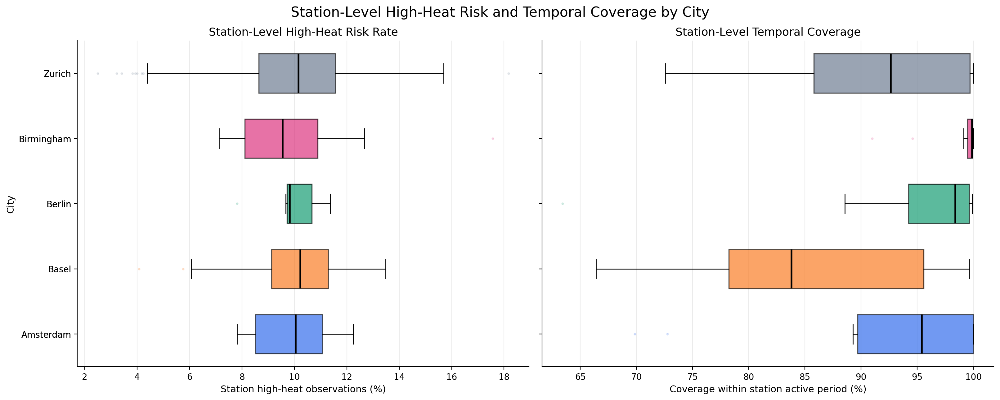

In [62]:
# Data for the two boxplots
city_order = sorted(station_summary["city"].unique())

risk_data = [
    station_summary.loc[station_summary["city"] == city, "heat_risk_rate_pct"]
    for city in city_order
]

coverage_data = [
    station_summary.loc[station_summary["city"] == city, "coverage_pct"]
    for city in city_order
]

# Plot
fig, axes = plt.subplots(
    1, 2, figsize=(16, 6),
    sharey=True, constrained_layout=True
)

bp_risk = axes[0].boxplot(
    risk_data,
    tick_labels=city_order,
    **BOXPLOT_KWARGS
)

# Fill only boxes and color only outliers
for i, city in enumerate(city_order):
    color = CITY_COLORS.get(city, "lightgrey")
    bp_risk["boxes"][i].set_facecolor(color)
    bp_risk["fliers"][i].set_markeredgecolor(color)
    bp_risk["fliers"][i].set_markerfacecolor(color)

axes[0].set_title("Station-Level High-Heat Risk Rate")
axes[0].set_xlabel("Station high-heat observations (%)")
axes[0].set_ylabel("City")
axes[0].grid(axis="y", visible=False)

bp_cov = axes[1].boxplot(
    coverage_data,
    tick_labels=city_order,
    **BOXPLOT_KWARGS
)

# Fill only boxes and color only outliers
for i, city in enumerate(city_order):
    color = CITY_COLORS.get(city, "lightgrey")
    bp_cov["boxes"][i].set_facecolor(color)
    bp_cov["fliers"][i].set_markeredgecolor(color)
    bp_cov["fliers"][i].set_markerfacecolor(color)

axes[1].set_title("Station-Level Temporal Coverage")
axes[1].set_xlabel("Coverage within station active period (%)")
axes[1].grid(axis="y", visible=False)

fig.suptitle("Station-Level High-Heat Risk and Temporal Coverage by City", y=1.05)

plt.show()

### 4.6. Predictor Relationship Check

The correlation matrix shows that most numeric predictors have weak linear correlations with each other and with the main target. This is expected because high-heat risk is likely driven by a combination of temporal, spatial, and city-level factors rather than by one single numeric predictor.

The strongest correlations with `heat_risk_q90` are observed for the cyclic temporal variables, especially `month_cos` (-0.29), `hour_cos` (-0.25), `month_sin` (-0.19), and `hour_sin` (-0.14). This confirms that seasonality and time of day are relevant for high-heat events. The sign of these correlations is not directly interpreted on its own because sine-cosine features work as pairs.

The spatial variables show very weak direct correlations with the target, suggesting that station position does not have a simple linear relationship with high-heat risk. However, this does not mean that spatial information is irrelevant, since spatial effects may vary by city or interact with other predictors.

The highest predictor-predictor correlation is between `sensor_height_m` and `measurement_interval_min` (0.53), suggesting that some measurement settings differ systematically across station networks. This is not high enough to require removing either variable, but it supports treating them as measurement-related controls rather than primary heat drivers.

Overall, the matrix does not show problematic multicollinearity among the main numeric predictors. It supports keeping the selected variables for the baseline model while interpreting final driver importance from the fitted model rather than from pairwise correlations alone.

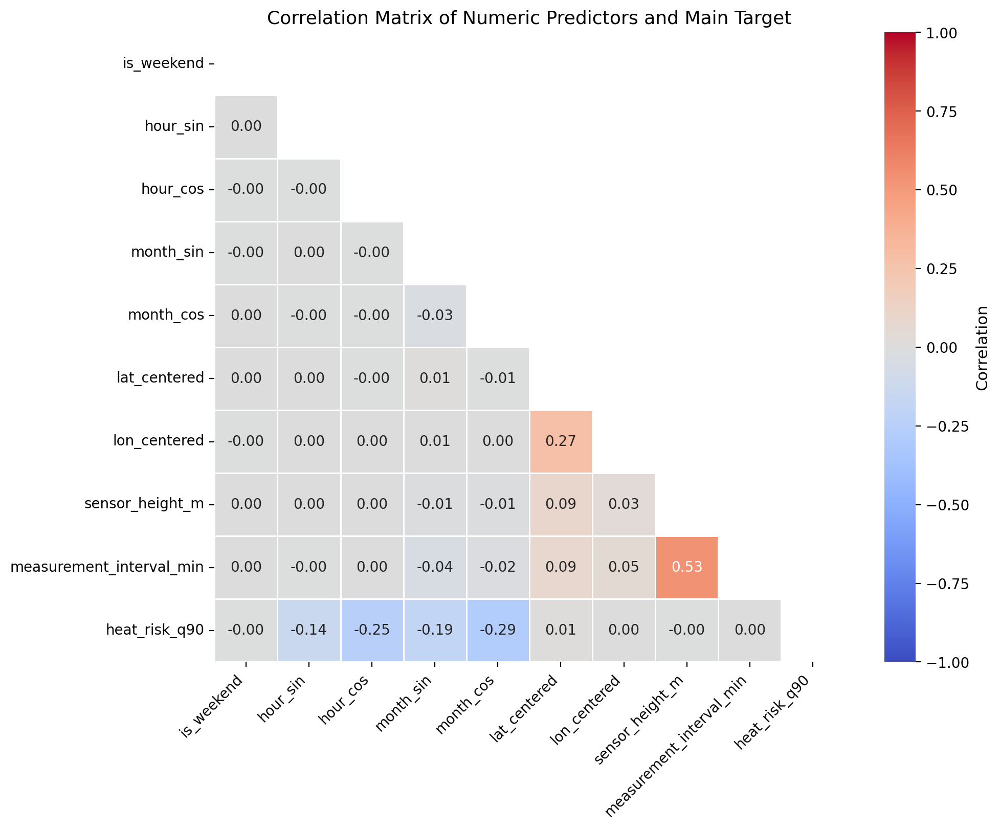

In [63]:
corr_cols = [
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "lat_centered",
    "lon_centered",
    "sensor_height_m",
    "measurement_interval_min",
    target_col,
]

corr_data = model_data[corr_cols].copy()

# Ensure all selected columns are numeric
for col in corr_data.columns:
    corr_data[col] = pd.to_numeric(corr_data[col], errors="coerce")

# Optional sample for speed
sample_size = min(300_000, len(corr_data))

corr_sample = (
    corr_data
    .dropna()
    .sample(n=sample_size, random_state=42)
)

corr_matrix = corr_sample.corr()

# Mask upper triangle and diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix of Numeric Predictors and Main Target")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.grid(False)

plt.show()

### 4.7. Train/Test Split Feasibility Check

The three candidate splits are used to check whether the baseline model is sensitive to the chosen temporal window. The main split trains on **2020–2021** and tests on **2022**, using the four cities available across the full window: Amsterdam, Basel, Berlin, and Birmingham. Zurich is excluded from this main split because it does not reach the 2022 test period. The two alternative splits are kept as temporal robustness checks: one uses **2020 for training and 2021 for testing** with Zurich included, while the other uses a shifted mid-year split from **2020–mid 2021** to **mid 2021–mid 2022** using the four full-window cities.

The class balance is reasonably close to the expected **10%** high-heat rate, but it is not identical across train and test sets. This is expected because the `heat_risk_q90` target is defined using city-specific thresholds over the full modelling dataset, not separately within each train/test period. Therefore, individual years or subperiods can contain more or fewer high-heat observations depending on weather conditions, seasonal coverage, and station availability.

In the main split, the training set has a lower high-heat share (**8.92%**), while the 2022 test set has a higher share (**12.31%**). This suggests that 2022 contains relatively more observations above the city-specific 90th percentile, making it a more demanding test period. In the 2020–2021 robustness split, the pattern is reversed: 2020 has a higher high-heat share (**11.41%**) and 2021 a lower one (**7.89%**). The mid-year robustness split has both train and test below 10%, with the test period again lower (**7.90%**).

Overall, the splits are not perfectly balanced, but they are acceptable for evaluation because they reflect realistic temporal variation rather than artificial random sampling. The differences between train and test class shares should be considered when interpreting performance: if the model performs consistently across these candidate splits, the results are less likely to depend on one specific year or temporal boundary.

In [64]:
# Candidate split 1: main full-window baseline
main_split = {
    "label": "Main split (2020-2021, test 2022)",
    "cities": ["Amsterdam", "Basel", "Berlin", "Birmingham"],
    "train_start": "2020-01-01",
    "train_end": "2022-01-01",
    "test_start": "2022-01-01",
    "test_end": "2023-01-01"
}

# Candidate split 2: robustness check including Zurich
robust_split_zurich = {
    "label": "Robustness Zurich (train 2020, test 2021)",
    "cities": ["Amsterdam", "Basel", "Berlin", "Birmingham", "Zurich"],
    "train_start": "2020-01-01",
    "train_end": "2021-01-01",
    "test_start": "2021-01-01",
    "test_end": "2022-01-01"
}

# Candidate split 3: robustness check with shifted mid-year boundary
robust_split_midyear = {
    "label": "Robustness midyear (train 2020-mid 2021, test mid 2021-mid 2022)",
    "cities": ["Amsterdam", "Basel", "Berlin", "Birmingham"],
    "train_start": "2020-01-01",
    "train_end": "2021-07-01",
    "test_start": "2021-07-01",
    "test_end": "2022-07-01"
}

candidate_splits = [
    main_split,
    robust_split_zurich,
    robust_split_midyear
]

split_tables = []

for split in candidate_splits:

    split_summary = []

    for part in ["train", "test"]:
        start = pd.Timestamp(split[f"{part}_start"])
        end = pd.Timestamp(split[f"{part}_end"])

        temp = model_data.loc[
            model_data["city"].isin(split["cities"]) &
            (model_data["datetime"] >= start) &
            (model_data["datetime"] < end)
        ]

        split_summary.append({
            "candidate": split["label"],
            "set": part,
            "rows": len(temp),
            "cities": temp["city"].nunique(),
            "stations": temp[["city", "station_number"]].drop_duplicates().shape[0],
            "start_date": temp["datetime"].min(),
            "end_date": temp["datetime"].max(),
            "heat_risk_pct": temp[target_col].mean() * 100
        })

    split_summary = pd.DataFrame(split_summary)
    split_tables.append(split_summary)

    print(split["label"])
    print(f"Cities included: {', '.join(split['cities'])}")
    display(
        split_summary
        .drop(columns="candidate")
        .round({"heat_risk_pct": 2})
    )

Main split (2020-2021, test 2022)
Cities included: Amsterdam, Basel, Berlin, Birmingham


,set,rows,cities,stations,start_date,end_date,heat_risk_pct
0,train,1579692,4,114,2020-01-01,2021-12-31 23:00:00,8.92
1,test,739083,4,104,2022-01-01,2022-12-31 23:00:00,12.31


Robustness Zurich (train 2020, test 2021)
Cities included: Amsterdam, Basel, Berlin, Birmingham, Zurich


,set,rows,cities,stations,start_date,end_date,heat_risk_pct
0,train,2242028,5,316,2020-01-01,2020-12-31 23:00:00,11.41
1,test,2286161,5,316,2021-01-01,2021-12-31 23:00:00,7.89


Robustness midyear (train 2020-mid 2021, test mid 2021-mid 2022)
Cities included: Amsterdam, Basel, Berlin, Birmingham


,set,rows,cities,stations,start_date,end_date,heat_risk_pct
0,train,1158133,4,114,2020-01-01,2021-06-30 23:00:00,9.03
1,test,809870,4,112,2021-07-01,2022-06-30 23:00:00,7.90


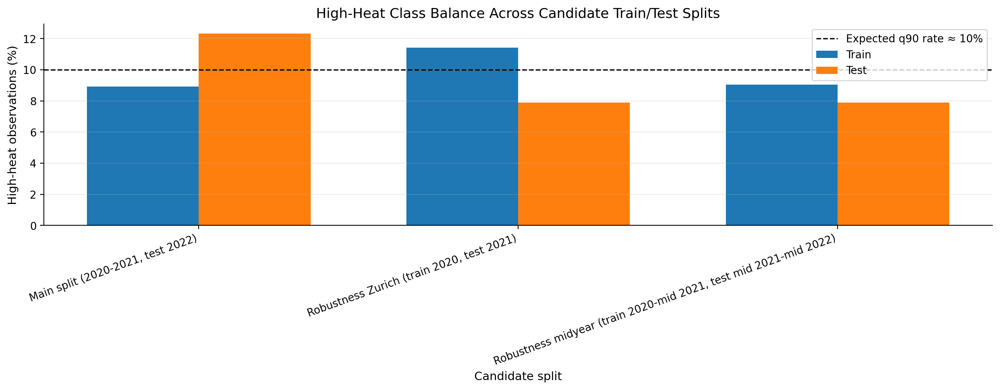

In [65]:
# Combine summaries for plotting
split_summary_all = pd.concat(split_tables, ignore_index=True)

# Plot high-heat class balance across candidate splits
plot_data = split_summary_all.copy()

split_labels = [split["label"] for split in candidate_splits]

x = np.arange(len(split_labels))
width = 0.35

train_vals = (plot_data[plot_data["set"] == "train"].set_index("candidate").loc[split_labels, "heat_risk_pct"])
test_vals = (plot_data[plot_data["set"] == "test"].set_index("candidate").loc[split_labels, "heat_risk_pct"])

plt.figure(figsize=(13, 5))

plt.bar(x - width / 2, train_vals, width, label="Train")
plt.bar(x + width / 2, test_vals, width, label="Test")

plt.axhline(10, linestyle="--", linewidth=1.2, color="black", label="Expected q90 rate ≈ 10%")

plt.title("High-Heat Class Balance Across Candidate Train/Test Splits")
plt.xlabel("Candidate split")
plt.ylabel("High-heat observations (%)")
plt.xticks(x, split_labels, rotation=20, ha="right")
plt.grid(axis="x", visible=False)
plt.legend()

plt.show()

### 4.8. EDA Summary and Modelling Implications

The exploratory analysis provides several implications for the baseline modelling stage. First, high-heat events are clearly structured by time: seasonal and hourly patterns are visible, supporting the use of cyclic temporal predictors such as `hour_sin`, `hour_cos`, `month_sin`, and `month_cos`.

Second, the city-level summaries show that observations are not evenly distributed across cities. Zurich and Basel contribute a much larger share of the data than smaller networks such as Amsterdam or Berlin. This motivates the use of city-balanced sample weights during model training, so that the pooled model is not dominated by the most represented cities.

Third, spatial diagnostics show that high-heat risk varies across stations, although there is no simple or consistent latitude-longitude gradient. For this reason, within-city centered coordinates are retained as spatial predictors, while `city` is used to control for broader between-city differences.

Fourth, measurement-related variables show only weak descriptive relationships with high-heat risk. Sensor height and measurement interval are therefore retained as control variables rather than interpreted as primary heat-risk drivers.

Given the size and structure of the dataset, the EDA relies on targeted summaries and visual diagnostics rather than broad unsupervised exploration. A full pairplot is not included because the dataset contains millions of station-hour observations, which would make it computationally expensive and difficult to interpret due to severe overplotting. PCA is also not applied because the predictor set is limited, deliberately engineered, and substantively interpretable. Replacing the original variables with principal components would reduce the transparency of the subsequent coefficient analysis without providing a clear dimensionality-reduction benefit.

Finally, station-level coverage diagnostics and candidate train/test split checks show that the dataset is suitable for chronological modelling, but not perfectly balanced across time, cities, and stations. These limitations should be considered when interpreting model performance and driver rankings. The next stage therefore uses an interpretable pooled classification model with city controls, city-balanced sample weights, and chronological validation.

## 5. Model Development

Following data cleaning, feature engineering, and exploratory analysis, the research question is formalised as a supervised binary-classification problem. The modelling pipeline combines all selected cities in a pooled dataset, preserves the chronological structure of the observations, applies consistent preprocessing, and estimates several models with complementary methodological roles.

The framework includes a dummy classifier, an unregularized logistic regression, an L2-regularized logistic regression, and a deliberately simple random forest. The dummy model provides a minimum reference, the logistic specifications support interpretable driver analysis, and the random forest provides a flexible nonlinear comparison.

Helper functions used in this section are defined in [0.4.3. Modelling Helper Functions](#043-modelling-helper-functions).

### 5.1. Problem Restatement

The objective is to identify the temporal, spatial, measurement-related, and city-level factors associated with high heat exposure across the selected European cities. The problem is formulated as a supervised binary-classification task in which each observation represents one monitoring station at one hourly timestamp.

The target variable is `heat_risk_q90`, defined as:

$$
Y_i=
\begin{cases}
1, & \text{if temperature exceeds the city-specific 90th percentile},\\
0, & \text{otherwise}.
\end{cases}
$$

High heat is therefore defined relative to each city’s own temperature distribution rather than through a common absolute threshold. The fitted models estimate the probability that a station-hour observation belongs to this city-relative high-heat category.

### 5.2. Inputs and Expected Outputs

The predictor set contains four feature groups:

* temporal features: `hour_sin`, `hour_cos`, `month_sin`, `month_cos`, and `is_weekend`;
* within-city spatial features: `lat_centered` and `lon_centered`;
* measurement-related controls: `sensor_height_m` and `measurement_interval_min`;
* city-level control: `city`.

The cyclical variables preserve the periodic structure of hour and month. The centred coordinates represent the relative location of each station within its city, while `city` controls for broader differences between urban contexts.

Temperature and temperature-derived predictors are excluded because they directly determine the target and would introduce target leakage.

Each fitted model produces an estimated probability:

$$
\hat p_i=P(Y_i=1\mid X_i).
$$

Using the default classification threshold of 0.50, the corresponding binary prediction is:

$$
\hat Y_i=
\begin{cases}
1, & \text{if } \hat p_i\geq 0.50,\\
0, & \text{if } \hat p_i<0.50.
\end{cases}
$$

The main model outputs are therefore class-1 probabilities and their corresponding default-threshold classifications. The fitted logistic models also provide coefficients and odds ratios, while the random forest provides feature-importance estimates.

### 5.3. Modelling Strategy

Three modelling strategies can be considered for a multi-city dataset, each answering a slightly different question and implying a different form of generalisation.

**1. City-specific models** — one model is trained separately for each city, asking: within each city, which factors are associated with high heat exposure? This approach can produce city-specific driver rankings useful for local policy and targeted interventions. However, it does not provide a shared cross-city ranking and may produce less stable estimates for cities with shorter temporal coverage or fewer observations.

**2. Pooled model without `city`** — one model is trained on all cities without including city identity as a predictor, asking: which factors are associated with high heat exposure across the pooled dataset without using city-specific information? This specification is more transferable in structure because it cannot rely on estimated city-specific baseline effects. However, it does not automatically guarantee generalisability. If the selected cities are not representative of broader European contexts, or if some cities are strongly overrepresented, the fitted relationships may still reflect the composition of the available sample.

**3. Pooled model with `city`** — one model is trained on all cities with `city` included as a categorical predictor, asking: after controlling for city-level differences, which factors are most strongly associated with high heat exposure across the selected cities? The `city` feature controls for persistent city-level heterogeneity, including differences in baseline climate, urban structure, and sensor-network design, while shared associations with temporal, spatial, and measurement-related predictors are estimated across the pooled dataset.

The main analysis adopts the third strategy. A pooled model with `city` best matches the research question because it produces one common driver ranking while accounting for systematic baseline differences among the selected cities. A pooled specification without `city` may additionally be considered as a robustness check to assess whether the main coefficient directions and driver ranking depend strongly on the inclusion of city-specific controls.

The temporal structure of the data is preserved through a chronological design: models are trained on 2020–2021 and tested on 2022, while regularization tuning uses expanding-window validation within the training period. The implementation is described in [5.6.2. Chronological Train/Test Split](#562-chronological-traintest-split).

All valid observations are retained. Unequal city representation is addressed through city-balanced sample weights computed from the training set rather than by excluding cities or randomly downsampling observations. The weighting procedure is described in [5.6.3. City-Balanced Sample Weights](#563-city-balanced-sample-weights).

### 5.4. Candidate Models and Rationale

Four classification models are included, each serving a distinct methodological purpose. They are fitted using the same predictor set, chronological training period, preprocessing structure, and city-balanced sample weights, so that differences between them reflect their modelling assumptions rather than differences in data preparation.

1. **Dummy classifier** — this provides the minimum reference model. It does not use the predictors and assigns every observation the positive-class probability estimated from the weighted training prevalence. It therefore represents the information available from the target distribution alone and establishes a benchmark that models using the selected predictors should outperform.

2. **Unregularized logistic regression** — this is the main interpretable specification. Logistic regression is appropriate because the target is binary and the model produces both predicted probabilities and directly interpretable coefficients. The sign of each coefficient indicates whether a predictor is associated with higher or lower high-heat log odds, holding the remaining variables constant. Because numerical predictors are standardised, their coefficient magnitudes can be compared on a common scale, while exponentiated coefficients provide odds ratios.

3. **L2-regularized logistic regression** — this is included to assess the stability of the unregularized estimates. The L2 penalty shrinks coefficients toward zero and can produce more stable estimates when predictors contain overlapping information, without removing variables from the model. Comparing the two logistic specifications therefore indicates whether the main coefficient directions and relative magnitudes remain consistent under regularization. The regularization parameter $C$ is selected through expanding-window, time-aware cross-validation within the training period.

4. **Random forest** — a deliberately simple forest is fitted as a nonlinear comparison. Unlike logistic regression, it does not assume that predictor effects are additive and linear on the log-odds scale. It can therefore represent nonlinear relationships and interactions that are not explicitly included in the logistic specifications. The forest is constrained rather than extensively tuned because its purpose is to test whether relevant nonlinear structure remains uncaptured, not to maximise predictive performance through a large hyperparameter search.

Together, these models provide a progression from a prevalence-only benchmark to interpretable linear specifications and a more flexible nonlinear alternative. This model set supports the primary objective of identifying stable and interpretable heat-risk drivers while testing whether the conclusions depend strongly on regularization or functional-form assumptions. More complex ensemble methods are not pursued because they would introduce additional computational and interpretive complexity without directly supporting the central analytical objective.

### 5.5. Main Modelling Assumptions

The general project assumptions are reported in [1.5. Success Criteria and Assumptions](#15-success-criteria-and-assumptions). This subsection focuses only on the modelling framework assumptions:

* the city-specific 90th percentile provides a meaningful definition of relative high heat within each city;
* the selected predictors capture relevant temporal, spatial, measurement-related, and city-level information without introducing target leakage;
* the chronological split provides a meaningful assessment of whether relationships estimated from earlier observations remain informative in a later period;
* the expanding-window validation design is appropriate for selecting the regularization strength without using future observations to predict earlier ones;
* city-balanced sample weights appropriately limit the influence of unequal city sample sizes during model estimation;
* `city`, `lat_centered`, and `lon_centered` capture sufficient between-city and within-city spatial structure for a pooled model;
* the logistic specifications provide a useful approximation of additive relationships on the log-odds scale;
* the random forest is sufficiently flexible to detect relevant nonlinear structure while remaining a controlled comparison;
* the estimated relationships represent predictive associations rather than causal effects.

### 5.6. Models Implementation

The modelling workflow is implemented through a sequence of reproducible steps. The target and feature matrices are first defined, followed by the chronological split and construction of city-balanced sample weights. A shared preprocessing structure is then combined with each classifier in a pipeline.

The dummy classifier and unregularized logistic regression are fitted directly on the complete training period. The L2-regularized logistic regression first undergoes time-aware hyperparameter selection and is then refitted on the full training set. The random forest is fitted using a fixed, deliberately constrained specification.

For every fitted model, class-1 probabilities and binary predictions at the default threshold of 0.50 are stored using consistent variable structures.

#### 5.6.1. Model Inputs

The modelling framework uses `heat_risk_q90` as the binary target. The predictor set contains cyclical temporal features, within-city spatial features, measurement-related controls, and `city` as a categorical control.

The features are grouped by analytical role so that the same definitions can be reused consistently throughout preprocessing, model fitting, interpretation, and robustness analysis. Temperature and temperature-derived variables are excluded because they directly determine the target and would introduce target leakage.

In [66]:
# Target variable
target_col = "heat_risk_q90"

# Columns used as predictors in the baseline model
temporal_features = [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "is_weekend"
]

spatial_features = [
    "lat_centered",
    "lon_centered"
]

measurement_features = [
    "sensor_height_m",
    "measurement_interval_min"
]

categorical_features = [
    "city"
]

feature_cols = (
    temporal_features
    + spatial_features
    + measurement_features
    + categorical_features
)

print("Target column:")
print(target_col)

print("\nFeature columns:")
for col in feature_cols:
    print(f"- {col}")

Target column:
heat_risk_q90

Feature columns:
- hour_sin
- hour_cos
- month_sin
- month_cos
- is_weekend
- lat_centered
- lon_centered
- sensor_height_m
- measurement_interval_min
- city


#### 5.6.2. Chronological Train/Test Split

The data are divided chronologically:

- **Training:** 1 January 2020, 00:00 $\rightarrow$ 31 December 2021, 23:00 
- **Validation:** 1 January 2022, 00:00 $\rightarrow$ 31 December 2022, 23:00  

This design preserves temporal ordering and prevents later observations from contributing to model estimation. The resulting feature matrices and target vectors retain the original row indices, allowing their alignment to be verified explicitly.

For regularization tuning, the training observations are ordered by timestamp and divided using an expanding-window design. Each fold is trained on an earlier period and validated on the immediately following period. Splits are constructed from unique hourly timestamps so that observations recorded at the same time cannot appear in both training and validation.

In [67]:
main_train_data, main_test_data, main_X_train, main_X_test, main_y_train, main_y_test = make_model_split(
    df=model_data,
    split_config=main_split,
    feature_cols=feature_cols,
    target_col=target_col,
    verbose=True
)

# Dataset lengths
assert len(main_train_data) == len(main_X_train) == len(main_y_train)
assert len(main_test_data) == len(main_X_test) == len(main_y_test)

# Index alignment
assert main_train_data.index.equals(main_X_train.index)
assert main_train_data.index.equals(main_y_train.index)
assert main_test_data.index.equals(main_X_test.index)
assert main_test_data.index.equals(main_y_test.index)

# No overlap between training and test observations
assert main_train_data.index.intersection(main_test_data.index).empty

# Chronological separation
assert (
    main_train_data["datetime"].max()
    < main_test_data["datetime"].min()
), "Training and test periods overlap."

# Correct feature structure
assert list(main_X_train.columns) == feature_cols
assert list(main_X_test.columns) == feature_cols

# Binary target with no missing values
assert not main_y_train.isna().any()
assert not main_y_test.isna().any()

assert set(main_y_train.unique()).issubset({0, 1})
assert set(main_y_test.unique()).issubset({0, 1})

print("\nChronological split checks completed successfully.")

print(
    f"Training period: "
    f"{main_train_data['datetime'].min()} to "
    f"{main_train_data['datetime'].max()}"
)

print(
    f"Test period: "
    f"{main_test_data['datetime'].min()} to "
    f"{main_test_data['datetime'].max()}"
)

print(f"Training observations: {len(main_train_data):,}")
print(f"Test observations: {len(main_test_data):,}")
print(f"Training positive rate: {main_y_train.mean():.4f}")
print(f"Test positive rate: {main_y_test.mean():.4f}")

Main split (2020-2021, test 2022)
Cities included: Amsterdam, Basel, Berlin, Birmingham


,set,rows,cities,stations,start_date,end_date,positive_class_pct
0,train,1579692,4,114,2020-01-01,2021-12-31 23:00:00,8.92
1,test,739083,4,104,2022-01-01,2022-12-31 23:00:00,12.31



Chronological split checks completed successfully.
Training period: 2020-01-01 00:00:00 to 2021-12-31 23:00:00
Test period: 2022-01-01 00:00:00 to 2022-12-31 23:00:00
Training observations: 1,579,692
Test observations: 739,083
Training positive rate: 0.0892
Test positive rate: 0.1231


#### 5.6.3. City-Balanced Sample Weights

The number of training observations differs substantially across cities. To prevent the most represented cities from dominating model estimation, city-balanced sample weights are computed using the training set only.

The weight assigned to an observation from city $c$ is:

$$
w_c = \frac{N}{K \cdot N_c},
$$

where:

* $N$ is the total number of training observations;
* $K$ is the number of cities;
* $N_c$ is the number of training observations from city $c$.

This weighting rule gives each city approximately equal total influence on the fitting objective. With four cities in the training set, each contributes 25% of the total training weight. This reduces the influence of highly represented cities, particularly Basel, while retaining all valid station-hour observations.

The weights are not model predictors. They affect only how strongly each training observation contributes during model fitting and are not applied again when generating predicted probabilities.

In [68]:
main_sample_weight_train = city_balanced_weights(
    train_data=main_train_data,
    verbose=True
)

# Sample-weight alignment and validity
assert len(main_sample_weight_train) == len(main_train_data)
assert main_sample_weight_train.index.equals(
    main_train_data.index
)

assert np.isfinite(main_sample_weight_train).all()
assert (main_sample_weight_train > 0).all()

# Confirm equal total training weight across cities
weight_check = (
    pd.DataFrame({
        "city": main_train_data["city"],
        "sample_weight": main_sample_weight_train
    })
    .groupby("city", observed=True)["sample_weight"]
    .agg(
        observations="size",
        individual_weight="first",
        total_weight="sum"
    )
    .reset_index()
)

weight_check["total_weight_share"] = (
    weight_check["total_weight"]
    / weight_check["total_weight"].sum()
)

assert np.allclose(
    weight_check["total_weight"],
    weight_check["total_weight"].mean(),
    rtol=1e-10,
    atol=1e-8
), "Cities do not contribute equal total training weight."

expected_share = 1 / weight_check["city"].nunique()

assert np.allclose(
    weight_check["total_weight_share"],
    expected_share,
    rtol=1e-10,
    atol=1e-8
), "City weight shares are not balanced."

Training city-balanced weights:


,city,observations,sample_weight,total_weight,observations_pct,total_weight_pct
0,Amsterdam,134591,2.9342,394923.0,8.52,25.0
1,Basel,998336,0.3956,394923.0,63.20,25.0
2,Berlin,130144,3.0345,394923.0,8.24,25.0
3,Birmingham,316621,1.2473,394923.0,20.04,25.0


#### 5.6.4. Preprocessing Pipeline

A shared preprocessing pipeline is defined for all models. Numerical predictors are standardised using:

$$
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j},
$$

where $\mu_j$ and $\sigma_j$ are estimated from the relevant training data.

Standardisation places the numerical variables on comparable scales and supports comparison of logistic-regression coefficient magnitudes. `StandardScaler` is preferred to `RobustScaler` because the selected predictors are already bounded, centred, or limited in range, and the exploratory analysis does not indicate extreme numerical outliers requiring robust scaling. Scaling is not necessary for the random forest, but the same preprocessing structure is retained across models to preserve consistency.

The categorical `city` feature is transformed through one-hot encoding. One city category is omitted as the reference level, avoiding exact linear dependence in the logistic-regression design matrix. Unknown categories are handled safely so that the preprocessing pipeline remains applicable to potential unseen-city extensions.

Combining preprocessing and model fitting within a single pipeline ensures that all transformations are learned from training data only and applied consistently to validation and test observations.


In [69]:
# Feature groups
numeric_features = (
    temporal_features
    + spatial_features
    + measurement_features
)

categorical_features = [
    "city"
]

# Final missing-value check before modelling
assert not main_X_train.isna().any().any(), "main_X_train contains missing values."
assert not main_X_test.isna().any().any(), "main_X_test contains missing values."

# Numeric preprocessing:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

# Combined preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline defined successfully.")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Preprocessing pipeline defined successfully.
Numeric features: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'lat_centered', 'lon_centered', 'sensor_height_m', 'measurement_interval_min']
Categorical features: ['city']


#### 5.6.4. Dummy Baseline

A dummy classifier is used as the simplest reference model. In this project, it acts as a minimum benchmark for comparison: a useful predictive model should provide better discrimination and identification of high-heat observations than this simple rule.

It does not use any input predictors and only learns the class distribution from the training data. Therefore, the same predicted probability is assigned to every observation:

$$
\hat{p}_i =
P(Y_i=1 \mid X_i)
\overset{\text{independent of } X_i}{=}
P(Y_i=1),
$$

$$
\hat{p}_i =
\hat{p}
\qquad
\text{for all } i.
$$

With `strategy="prior"`, the classifier estimates the weighted proportion of high-heat observations, $\hat{p}$, in the training data:

$$
\hat{p} =
\frac{\sum_{i=1}^{n} w_i y_i}
{\sum_{i=1}^{n} w_i},
$$

where:

- $y_i$ is the observed target;
- $w_i$ is the city-balanced sample weight.

The dummy baseline shows the performance achievable without learning temporal, spatial, measurement-related, or city-level patterns. Since $\hat{p}$ is constant across all observations and the weighted prevalence of high heat is below $0.5$, such that $\hat{p}<0.5$, the model predicts the non-high-heat majority class for every observation. It is therefore unable to identify high-heat events. Its role is not to provide a meaningful predictive or explanatory model, but to define a minimum reference point for evaluating the later models.

In [70]:
# Dummy classifier pipeline
dummy_clf = DummyClassifier(
    strategy="prior",
    random_state=42
)

# Fit model with city-balanced sample weights
dummy_clf.fit(
    main_X_train,
    main_y_train,
    sample_weight=main_sample_weight_train
)

print("Dummy baseline fitted successfully.")
display(dummy_clf)

Dummy baseline fitted successfully.


,strategy,'prior'
,random_state,42
,constant,None


#### 5.6.5. Logistic Regression

Logistic regression is used as the first model that learns relationships between the predictors and the binary high-heat target. It combines the input features into a linear score and then converts this score into a probability between $0$ and $1$:

$$
\hat{p}_i =
P(Y_i=1 \mid X_i) =
\frac{1}{1+e^{-z_i}}
\qquad \text{with} \qquad
z_i = \beta_0+\sum_{j=1}^{p}\beta_j x_{ij},
$$

where:

- $\beta_0$ is the intercept,
- $x_{ij}$ is the value of predictor $j$ for observation $i$,
- and $\beta_j$ is the estimated coefficient associated with that predictor.

The model coefficients are estimated by minimizing the weighted binary cross-entropy loss:

$$
\mathcal{L}(\boldsymbol{\beta}) =
-\frac{1}{\sum_{i=1}^{n} w_i}
\sum_{i=1}^{n}
w_i
\left[
y_i \log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right],
$$

where:

- $y_i$ is the observed class,
- $\hat{p}_i$ is the predicted probability of high heat,
- and $w_i$ is the city-balanced sample weight.

Logistic regression is appropriate because the target is binary and the model provides directly interpretable coefficients. Each coefficient $\beta_j$ represents the change in the log-odds of high heat associated with the corresponding predictor, holding the other variables constant. Positive coefficients indicate higher odds of high heat, while negative coefficients indicate lower odds. Coefficients and odds ratios are related as follows:

$$
\text{OR}_j=e^{\beta_j}
\quad\Longleftrightarrow\quad
\beta_j=\log(\text{OR}_j).
$$

This makes logistic regression particularly useful for identifying the direction and relative magnitude of the factors associated with high-heat risk. City-balanced sample weights are also used during fitting so that each training city has equal total influence on the estimated relationships.

> **Note.** Scikit-learn applies L2 regularization by default in `LogisticRegression`, with `C=1.0` (`C` is the inverse of the regularization strength, so smaller values imply stronger regularization). In this model, regularization is explicitly removed by setting `C=np.inf`. Although the empirical results may be very similar because of the large sample size and the limited number of predictors, the two specifications are not mathematically equivalent. In general, keeping the scikit-learn default is reasonable; however, for the purpose of this project, the unregularized specification is used to provide a clear baseline for comparison with the regularized logistic regression model.

In [71]:
# Logistic regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        C=np.inf,
        max_iter=1000,
        class_weight=None,
        random_state=42,
    ))
])

# Fit model with city-balanced sample weights
log_reg_pipeline.fit(
    main_X_train,
    main_y_train,
    model__sample_weight=main_sample_weight_train
)

print("Logistic regression fitted successfully.")
display(log_reg_pipeline)

Logistic regression fitted successfully.


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 5.6.6. Regularized Logistic Regression

The regularized logistic regression extends the previous model by adding an L2 penalty to the weighted binary cross-entropy loss. This penalty discourages excessively large coefficients and can improve model stability and reduce overfitting:

$$
\mathcal{L}_{\text{L2}}(\boldsymbol{\beta}) =
-\frac{1}{\sum_{i=1}^{n} w_i}
\sum_{i=1}^{n}
w_i
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
+
\frac{\lambda}{2}\sum_{j=1}^{p}\beta_j^2,
$$

where:
- $\lambda$ controls the strength of the L2 penalty.

In scikit-learn, regularization is controlled through $C$, which is inversely related to $\lambda$:

$$
\lambda \propto \frac{1}{C}.
$$

Therefore, smaller values of $C$ produce stronger coefficient shrinkage, while larger values produce weaker regularization. Unlike L1 regularization, the L2 penalty generally retains all predictors rather than setting some coefficients exactly to zero. This is appropriate because the feature set is limited and theory-driven, it preserves related features such as the sine and cosine time variables, and the aim is to retain and interpret all selected predictors rather than perform automatic feature selection.

The value of $C$ is assessed using three-fold time-aware cross-validation (`n_splits=3`) within the training period. The observations are first ordered chronologically, and the folds are constructed from unique hourly timestamps rather than individual rows. This is important because the number of available station observations varies over time due to missing data and differences in data availability. Splitting by timestamp creates folds with comparable temporal durations and ensures that all station observations recorded during the same hour remain in the same fold.

An expanding-window, or forward-chaining, procedure is used. The two-year training period is divided into four approximately equal temporal blocks of about six months each:

- **Fold 1:**  
  **Training:** 1 January 2020, 00:00 $\rightarrow$ 1 July 2020, 17:00  
  **Validation:** 1 July 2020, 18:00 $\rightarrow$ 31 December 2020, 11:00  

- **Fold 2:**  
  **Training:** 1 January 2020, 00:00 $\rightarrow$ 31 December 2020, 11:00  
  **Validation:** 31 December 2020, 12:00 $\rightarrow$ 2 July 2021, 05:00  

- **Fold 3:**  
  **Training:** 1 January 2020, 00:00 $\rightarrow$ 2 July 2021, 05:00  
  **Validation:** 2 July 2021, 06:00 $\rightarrow$ 31 December 2021, 23:00  

The training window expands across folds, while each validation period occurs strictly after the observations used for fitting. This differs from ordinary or blocked $k$-fold cross-validation, in which each block is held out in turn and the model is trained on all remaining blocks. In a temporal setting, that procedure could use later observations to predict an earlier validation period, introducing look-ahead bias.

Forward-chaining avoids this problem and reflects the final evaluation setting, where the model is trained on earlier years and applied to a later test period. The resulting folds have comparable temporal durations, although neither the number of observations nor the class distribution is forced to be equal across folds.

Candidate values of $C$ are compared using four complementary scorers:

- **negative log loss**, which evaluates the quality of the predicted probabilities and is used as the primary selection criterion;
- **average precision**, which evaluates the ranking of the minority high-heat class across possible thresholds;
- **ROC-AUC**, which evaluates the overall separation between high-heat and non-high-heat observations;
- **balanced accuracy**, which evaluates classification performance on both classes at the default threshold of $0.5$.

The time-aware grid search selected $C=0.001$ because it achieved the highest mean negative log loss across the validation folds. This value also produced the highest mean average precision and balanced accuracy, while its ROC-AUC was only marginally below the maximum obtained at $C=0.01$. Since $C=0.001$ provided the strongest overall cross-validation performance, it was retained as the final regularization parameter.Through the `refit="neg_log_loss"` procedure, the selected model was then automatically fitted on the complete training set using city-balanced sample weights.

This model is included to assess whether L2 regularization improves predictive performance and produces more stable estimates of the heat-risk drivers compared with the unregularized logistic regression.

In [72]:
# Chronologically ordered training data for time-aware cross-validation
cv_order = (
    main_train_data
    .sort_values("datetime", kind="mergesort")
    .index
)

main_X_train_cv = main_X_train.loc[cv_order]
main_y_train_cv = main_y_train.loc[cv_order]
main_sample_weight_train_cv = main_sample_weight_train.loc[cv_order]

# Datetimes aligned with the positional rows used by GridSearchCV
ordered_datetimes = (
    pd.to_datetime(main_train_data.loc[cv_order, "datetime"])
    .reset_index(drop=True)
)

datetime_values = ordered_datetimes.to_numpy()

# Unique timestamps are already chronological because the rows were sorted
unique_datetimes = ordered_datetimes.drop_duplicates().to_numpy()

# Create time-aware folds using unique timestamps rather than individual rows
timestamp_splitter = TimeSeriesSplit(n_splits=3)
time_cv_splits = []

for train_time_idx, validation_time_idx in timestamp_splitter.split(
    unique_datetimes
):
    train_end = unique_datetimes[train_time_idx[-1]]
    validation_start = unique_datetimes[validation_time_idx[0]]
    validation_end = unique_datetimes[validation_time_idx[-1]]

    # Convert timestamp boundaries back into positional row indices
    train_idx = np.flatnonzero(datetime_values <= train_end)

    validation_idx = np.flatnonzero(
        (datetime_values >= validation_start)
        & (datetime_values <= validation_end)
    )

    time_cv_splits.append((train_idx, validation_idx))

# Check temporal boundaries and summarize each fold
fold_rows = []

for fold, (train_idx, validation_idx) in enumerate(
    time_cv_splits,
    start=1
):
    train_dates = ordered_datetimes.iloc[train_idx]
    validation_dates = ordered_datetimes.iloc[validation_idx]

    train_start = train_dates.min()
    train_end = train_dates.max()
    validation_start = validation_dates.min()
    validation_end = validation_dates.max()

    strict_separation = train_end < validation_start

    fold_rows.append({
        "fold": fold,
        "training_start": train_start,
        "training_end": train_end,
        "training_observations": len(train_idx),
        "training_timestamps": train_dates.nunique(),
        "validation_start": validation_start,
        "validation_end": validation_end,
        "validation_observations": len(validation_idx),
        "validation_timestamps": validation_dates.nunique(),
        "strict_chronological_separation": strict_separation,
    })

time_cv_summary = pd.DataFrame(fold_rows)

# Ensure strict chronological separation in every fold
assert time_cv_summary["strict_chronological_separation"].all(), (
    "Temporal overlap detected in one or more cross-validation folds."
)

print("Time-aware expanding-window splitting check:")
display(time_cv_summary)

Time-aware expanding-window splitting check:


,fold,training_start,training_end,training_observations,training_timestamps,validation_start,validation_end,validation_observations,validation_timestamps,strict_chronological_separation
0,1,2020-01-01,2020-07-01 17:00:00,284652,4386,2020-07-01 18:00:00,2020-12-31 11:00:00,448447,4386,True
1,2,2020-01-01,2020-12-31 11:00:00,733099,8772,2020-12-31 12:00:00,2021-07-02 05:00:00,428047,4386,True
2,3,2020-01-01,2021-07-02 05:00:00,1161146,13158,2021-07-02 06:00:00,2021-12-31 23:00:00,418546,4386,True


In [73]:
# Pipeline and cross-validation search
cv_log_reg_search_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=42
    ))
])

scorers = [
    "neg_log_loss",
    "average_precision",
    "roc_auc",
    "balanced_accuracy"
]

cv_log_reg_search = GridSearchCV(
    estimator=cv_log_reg_search_pipeline,
    param_grid={
        "model__C": np.logspace(-6, 1, 8)
    },
    scoring=scorers,
    refit="neg_log_loss",
    cv=time_cv_splits,
    n_jobs=-1,
    return_train_score=True
)

# Fit using city-balanced sample weights
cv_log_reg_search.fit(
    main_X_train_cv,
    main_y_train_cv,
    model__sample_weight=main_sample_weight_train_cv
)

# Automatically selected model according to mean CV negative log loss
cv_log_reg_pipeline = cv_log_reg_search.best_estimator_

best_C = float(cv_log_reg_search.best_params_["model__C"])

print(f"Best C by negative log loss: {best_C:.0e}")
print(f"\nRegularized logistic regression fitted successfully: C = {best_C:.0e}.")
display(cv_log_reg_pipeline)

Best C by negative log loss: 1e-03

Regularized logistic regression fitted successfully: C = 1e-03.


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [74]:
# Summarize results for every value of C
metric_labels = {
    "neg_log_loss": "Neg. Log Loss",
    "average_precision": "Average Precision",
    "roc_auc": "ROC-AUC",
    "balanced_accuracy": "Balanced Accuracy"
}

result_columns = ["param_model__C"] + [
    f"{stat}_test_{metric}"
    for metric in metric_labels
    for stat in ("mean", "std", "rank")
]

rename_map = {"param_model__C": "C"}
rename_map.update({
    f"{stat}_test_{metric}": f"{stat.title()} {label}"
    for metric, label in metric_labels.items()
    for stat in ("mean", "std", "rank")
})

cv_results_summary = (
    pd.DataFrame(cv_log_reg_search.cv_results_)[result_columns]
    .rename(columns=rename_map)
    .assign(C=lambda df: df["C"].astype(float))
    .sort_values("C")
    .reset_index(drop=True)
)

formatters = {
    "C": "{:.0e}",
    **{
        col: "{:.4f}"
        for col in cv_results_summary.columns
        if col.startswith(("Mean", "Std"))
    }
}

print("\nCross-validation results for all regularization strengths:")
display(cv_results_summary.style.format(formatters))


Cross-validation results for all regularization strengths:


,C,Mean Neg. Log Loss,Std Neg. Log Loss,Rank Neg. Log Loss,Mean Average Precision,Std Average Precision,Rank Average Precision,Mean ROC-AUC,Std ROC-AUC,Rank ROC-AUC,Mean Balanced Accuracy,Std Balanced Accuracy,Rank Balanced Accuracy
0,1e-06,-0.2981,0.0777,8,0.4509,0.0520,8,0.9171,0.0146,8,0.5000,0.0000,7
1,1e-05,-0.2524,0.0709,7,0.4582,0.0395,7,0.9176,0.0163,7,0.5000,0.0000,7
2,1e-04,-0.2081,0.0636,3,0.4639,0.0254,6,0.9177,0.0191,6,0.5497,0.0390,6
3,1e-03,-0.1925,0.0560,1,0.4678,0.0271,1,0.9207,0.0175,5,0.6346,0.0522,1
4,1e-02,-0.2054,0.0721,2,0.4666,0.0260,2,0.9214,0.0172,1,0.6307,0.0807,2
5,1e-01,-0.2119,0.0802,4,0.4655,0.0247,3,0.9211,0.0174,2,0.6304,0.0843,5
6,1e+00,-0.2127,0.0812,5,0.4654,0.0246,4,0.9210,0.0174,3,0.6304,0.0846,3
7,1e+01,-0.2128,0.0814,6,0.4654,0.0245,5,0.9210,0.0174,4,0.6304,0.0847,4


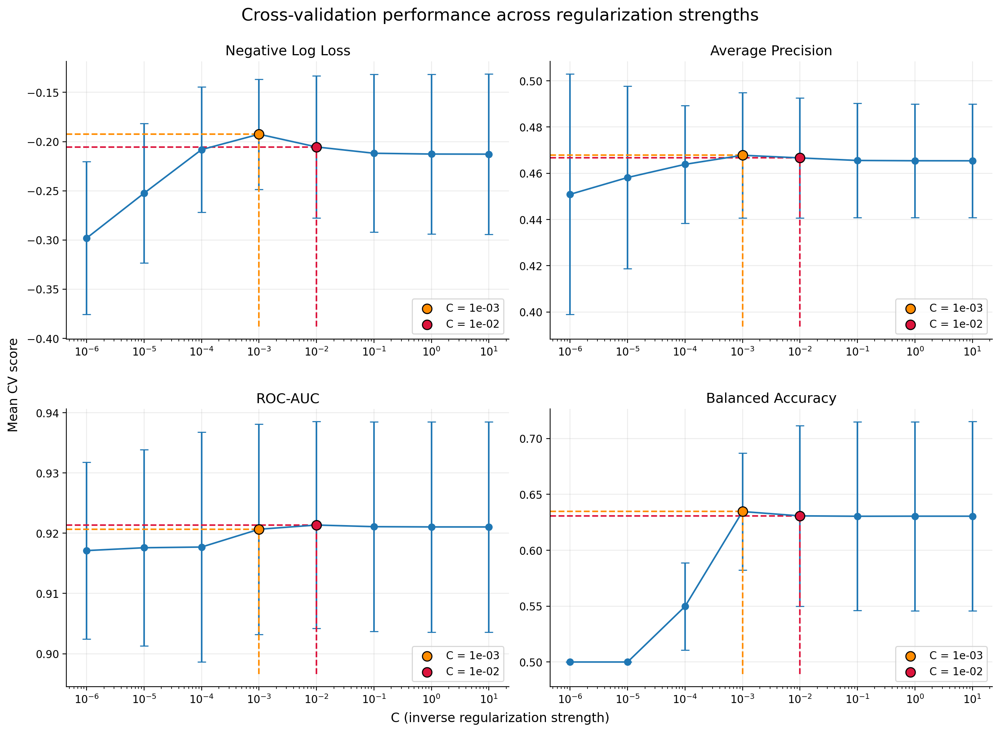

In [75]:
# Candidate regularization strengths
candidate_Cs = {
    0.001: "darkorange",
    0.01: "crimson"
}

metrics_to_plot = [
    ("Mean Neg. Log Loss", "Std Neg. Log Loss", "Negative Log Loss"),
    ("Mean Average Precision", "Std Average Precision", "Average Precision"),
    ("Mean ROC-AUC", "Std ROC-AUC", "ROC-AUC"),
    ("Mean Balanced Accuracy", "Std Balanced Accuracy", "Balanced Accuracy")
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), gridspec_kw={"hspace": 0.10})
axes = axes.flatten()

for ax, (mean_col, std_col, title) in zip(axes, metrics_to_plot):
    ax.errorbar(
        cv_results_summary["C"],
        cv_results_summary[mean_col],
        yerr=cv_results_summary[std_col],
        marker="o",
        capsize=4
    )

    ax.set_xscale("log")

    # Current lower limits used as projection starting points
    x_min = ax.get_xlim()[0]
    y_min = ax.get_ylim()[0]

    for candidate_C, color in candidate_Cs.items():
        candidate_score = cv_results_summary.loc[
            np.isclose(cv_results_summary["C"], candidate_C),
            mean_col
        ].iloc[0]

        # Vertical projection: from bottom of plot to candidate point
        ax.vlines(
            x=candidate_C,
            ymin=y_min, ymax=candidate_score,
            color=color, linestyle="--"
        )

        # Horizontal projection: from y-axis to candidate point
        ax.hlines(
            y=candidate_score,
            xmin=x_min, xmax=candidate_C,
            color=color, linestyle="--"
        )

        ax.scatter(
            candidate_C, candidate_score,
            color=color, edgecolor="black", s=80,
            zorder=3, label=f"C = {candidate_C:.0e}"
        )

    ax.set_title(title)
    ax.legend(loc="lower right")

fig.suptitle("Cross-validation performance across regularization strengths", y=1.05)
fig.supxlabel("C (inverse regularization strength)")
fig.supylabel("Mean CV score")

plt.show()

#### 5.6.7. Random Forest

The random forest is included as a nonlinear comparison model. Unlike logistic regression, it does not assume a linear relationship between the predictors and the log-odds of high heat. Instead, it combines multiple decision trees, allowing the model to capture nonlinear effects and interactions between predictors.

Each tree is fitted on a bootstrap sample of the training observations and considers a random subset of predictors at each split. For an observation with predictor vector $\mathbf{x}_i$, let $L_b(\mathbf{x}_i)$ denote the terminal leaf reached in tree $b$. The probability predicted by that tree is the weighted proportion of high-heat training observations within the leaf:

$$
\hat{p}_{ib} =
P_b(Y_i=1\mid \mathbf{x}_i) =
\frac{
\sum_{k \in L_b(\mathbf{x}_i)} w_k y_k
}{
\sum_{k \in L_b(\mathbf{x}_i)} w_k
},
$$

where:

- $i$ identifies the observation being predicted;
- $b$ identifies the tree;
- $k$ indexes the training observations contained in the terminal leaf;
- $y_k$ is the observed class of training observation $k$;
- $w_k$ is its city-balanced sample weight;
- and $L_b(\mathbf{x}_i)$ is the terminal leaf assigned to observation $i$ by tree $b$.

The final random-forest probability is obtained by averaging the probabilities produced by all $B$ trees:

$$
\hat{p}_i =
\hat{p}_{\mathrm{RF}}(\mathbf{x}_i) =
\frac{1}{B}
\sum_{b=1}^{B}
\hat{p}_{ib},
$$

with $B=100$ in this analysis. Averaging across trees reduces the instability and overfitting associated with a single decision tree.

Unlike logistic regression, the random forest does not estimate all model parameters by minimizing one global loss function. Each tree is instead constructed recursively by choosing the split that produces the largest reduction in weighted Gini impurity. For a node with weighted high-heat proportion $p$, binary Gini impurity is defined as:

$$
G =
1-p^2-(1-p)^2 =
2p(1-p).
$$

A value close to zero indicates that most observations in the node belong to the same class, while larger values indicate a more mixed node. The algorithm therefore selects splits that create increasingly homogeneous child nodes.

The forest is intentionally constrained to balance model flexibility, computational efficiency, and generalization:

- `n_estimators=100` fits 100 trees, providing a sufficiently stable ensemble while keeping computation manageable;
- `max_depth=20` limits the maximum depth of each tree and prevents excessively complex decision rules;
- `min_samples_leaf=100` requires each terminal leaf to contain at least 100 observations, producing smoother and more generalizable predictions;
- `max_features="sqrt"` considers only the square root of the available predictors at each split, increasing diversity between trees;
- `max_samples=0.5` trains each tree on a bootstrap sample containing 50% of the training observations, further increasing tree diversity and reducing computation;
- `class_weight=None` is retained because city-balanced sample weights are already supplied during model fitting, while the classification threshold is assessed separately.

The random forest is fitted on the complete training set using the same city-balanced sample weights as the logistic-regression models. Extensive hyperparameter tuning is not performed because the forest is used primarily to assess whether nonlinear relationships and interactions provide a meaningful predictive improvement over the simpler and more interpretable logistic-regression models.

The model therefore serves as a nonlinear robustness comparison rather than as the main explanatory model. Its predictive performance and feature importance are compared with the logistic-regression results to assess whether the identified heat-risk drivers remain relevant under a more flexible model structure.

In [76]:
# Random forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=20,
        min_samples_leaf=100,
        max_features="sqrt",
        max_samples=0.5,
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit random forest with city-balanced sample weights
rf_pipeline.fit(
    main_X_train,
    main_y_train,
    model__sample_weight=main_sample_weight_train
)

print("Random forest fitted successfully.")
display(rf_pipeline)

Random forest fitted successfully.


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Model Validation and Robustness

This section evaluates the fitted models on held-out test data and assesses whether the main conclusions are stable under alternative modelling choices. The analysis first compares the dummy baseline, logistic-regression specifications, and random forest using a common evaluation workflow. Based on predictive performance, interpretability, and stability, one model is selected as the primary model for the remaining analyses.

After model selection, the section tunes the classification threshold to reflect the decision objective of prioritising high-heat detection while still limiting false alerts. The selected threshold is then used for city-level diagnostics and prediction-error analysis, so that the reported classification results correspond to the final decision rule rather than the default 0.50 cutoff.

Finally, the robustness checks examine whether the main driver patterns remain consistent across alternative time splits, heat-risk target definitions, and feature subsets. This helps distinguish stable model findings from results that depend strongly on one specific split, threshold definition, or feature configuration.

Helper functions used in this section are defined in [0.4.4. Evaluation Helper Functions](#044-evaluation-helper-functions).

### 6.1. Model Comparison and Selection

The four fitted models are first evaluated on the same chronological test set using their predicted class-1 probabilities and binary classifications at the default threshold of $0.50$. Test observations are evaluated without city-balancing weights, so the reported metrics describe performance on the observed 2022 station-hour sample.

To ensure a consistent comparison, the fitted models are stored in a common dictionary and processed through the same evaluation workflow. For each model, the code generates and stores:

* predicted high-heat probabilities;
* test classification metrics;
* a confusion matrix.

These outputs are then used to compare overall performance, ROC and precision–recall curves, and confusion matrices. At this stage, all threshold-dependent metrics are calculated using the default cutoff, while classification-threshold tuning is conducted separately.

The main evaluation metrics used in this section are summarised below. Average precision is threshold-independent because it evaluates the ranking of predicted probabilities across possible cutoffs. The remaining metrics are threshold-dependent because they rely on binary class predictions, which in this comparison are computed using the default threshold of $0.50$.

| Metric | Formula | Interpretation |
|---|---|---|
| **Average precision (PR-AUC/AP)** | $$\sum_n (R_n-R_{n-1})P_n$$ | Summarises precision-recall performance across thresholds; especially useful for the imbalanced high-heat class. |
| **Accuracy** | $$\frac{TP+TN}{TP+TN+FP+FN}$$ | Measures the overall share of correct predictions, but can be misleading when the negative class dominates. |
| **Balanced accuracy** | $$\frac{\text{Recall}+\text{Specificity}}{2}$$ | Gives equal weight to performance on the positive and negative classes. |
| **Precision** | $$\frac{TP}{TP+FP}$$ | Measures how reliable positive high-heat predictions are. |
| **Recall** | $$\frac{TP}{TP+FN}$$ | Measures how many actual high-heat observations are detected. |
| **Specificity** | $$\frac{TN}{TN+FP}$$ | Measures how many non-high-heat observations are correctly rejected. |
| **F1-score** | $$2\frac{\text{Precision}\times\text{Recall}}{\text{Precision}+\text{Recall}}$$ | Combines precision and recall with equal weight. |

At this stage, all threshold-dependent metrics are calculated using the default cutoff of $0.50$. Classification-threshold tuning is conducted separately after the primary model has been selected, so that the final decision rule can be aligned with the objective of prioritising high-heat detection while still limiting false alerts.

The primary model is selected based on predictive performance, stability, and interpretability. All subsequent threshold tuning, model interpretation, diagnostic analysis, and robustness checks are then conducted using this selected model.

In [77]:
# Store fitted models
models = {
    "Dummy Baseline": dummy_clf,
    "Logistic Regression": log_reg_pipeline,
    "CV Logistic Regression": cv_log_reg_pipeline,
    "Random Forest": rf_pipeline,
}

main_probabilities  = {}
main_metrics = {}
main_conf_matrices  = {}

# Predict, evaluate, and store confusion matrices
for model_name, model in models.items():
    y_proba = model.predict_proba(main_X_test)[:, 1]

    main_probabilities [model_name] = y_proba

    main_metrics[model_name] = evaluate_classifier(
        y_true=main_y_test,
        y_proba=y_proba,
        model_name=model_name,
    )

    main_conf_matrices[model_name] = make_confusion_matrix(
        y_true=main_y_test,
        y_proba=y_proba,
    )

print("Predicted probabilities, test classification metrics, and confusion matrices stored successfully.")

Predicted probabilities, test classification metrics, and confusion matrices stored successfully.


#### 6.1.1. Overall Performance Metrics

The dummy baseline achieves an accuracy of 0.8769 because most test observations belong to the non-high-heat class. However, its balanced accuracy is 0.50 and its precision, recall, and F1-score are all zero, confirming that it predicts no high-heat events at the default threshold. Its PR-AUC of 0.1231 corresponds to the positive-class prevalence and provides the appropriate minimum reference for the fitted models.

The unregularized logistic regression provides the strongest overall performance. Its ROC-AUC of 0.9483 indicates strong separation between high-heat and non-high-heat observations, while its PR-AUC of 0.6810 shows a substantial improvement over the prevalence baseline in identifying the minority class. At the default threshold of 0.50, precision is high at 0.7892, meaning that most observations classified as high heat are correct. Recall is considerably lower at 0.2733, however, indicating that the model identifies only about 27% of the actual high-heat events. The model is therefore accurate in the positive predictions it makes but conservative in assigning the positive class.

The L2-regularized logistic regression produces very similar threshold-independent performance, with ROC-AUC of 0.9480 and PR-AUC of 0.6799. This indicates that regularization does not materially alter the model’s ability to rank observations by heat risk. Its lower recall, balanced accuracy, and F1-score at the default threshold suggest that coefficient shrinkage produces slightly more conservative classifications, although the differences from the unregularized specification remain small.

The random forest also performs substantially better than the dummy baseline, reaching ROC-AUC of 0.9381 and PR-AUC of 0.6488. However, it does not improve upon either logistic specification. Its lower recall and F1-score at the default threshold indicate that the additional nonlinear flexibility does not translate into stronger identification of high-heat observations under the current feature set and fixed forest specification.

Overall, the unregularized logistic regression provides the strongest combination of probability ranking, minority-class performance, and interpretability. The similar results of the regularized model support the stability of the logistic specification, while the random forest provides no evidence that a more flexible nonlinear model offers a clear predictive advantage. Because all threshold-dependent metrics are calculated using the default cutoff of 0.50, the low recall observed across the fitted models should be reconsidered through time-aware classification-threshold selection.

In [78]:
# Combine model results
main_results = pd.concat(
    main_metrics .values(),
    ignore_index=True
)

main_cols = [
    "model", "threshold", "log_loss",
    "roc_auc", "pr_auc", "accuracy",
    "balanced_accuracy", "precision",
    "recall", "specificity", "f1",
]

print("Model comparison on main test set:")
display(main_results[main_cols].round(4))

Model comparison on main test set:


,model,threshold,log_loss,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,Dummy Baseline,0.5,0.3782,0.5000,0.1231,0.8769,0.5000,0.0000,0.0000,1.0000,0.000
1,Logistic Regression,0.5,0.2003,0.9483,0.6810,0.9015,0.6315,0.7892,0.2733,0.9898,0.406
2,CV Logistic Regression,0.5,0.2019,0.9480,0.6799,0.9001,0.6215,0.7985,0.2520,0.9911,0.383
3,Random Forest,0.5,0.2107,0.9381,0.6488,0.8961,0.6052,0.7764,0.2193,0.9911,0.342


#### 6.1.2. ROC and Precision–Recall Curves

The ROC curves show that all three fitted models separate high-heat from non-high-heat observations substantially better than the dummy baseline. The unregularized and L2-regularized logistic regressions are almost indistinguishable across the full range of thresholds, with ROC-AUC values close to 0.95. This indicates that coefficient regularization has little effect on the ordering of observations by predicted heat risk. The random forest also performs strongly, but its curve lies slightly below the logistic specifications, consistent with its lower ROC-AUC of approximately 0.94.

The precision–recall curves provide the more informative comparison for the imbalanced target because they focus directly on performance for the high-heat class. Both logistic models achieve an average precision of approximately 0.68, substantially above the positive-class prevalence of 0.123. Their curves remain closely aligned, again showing that regularization does not materially change minority-class ranking performance. The random forest reaches a lower average precision of approximately 0.65 and generally provides less precision than the logistic models at comparable recall levels.

Overall, the curves show no predictive advantage from the additional nonlinear flexibility of the random forest. The two logistic specifications provide the strongest and most stable probability ranking, while the unregularized model retains the advantage of direct coefficient interpretation. These curves evaluate performance across all possible classification thresholds and therefore do not determine the final operational cutoff.

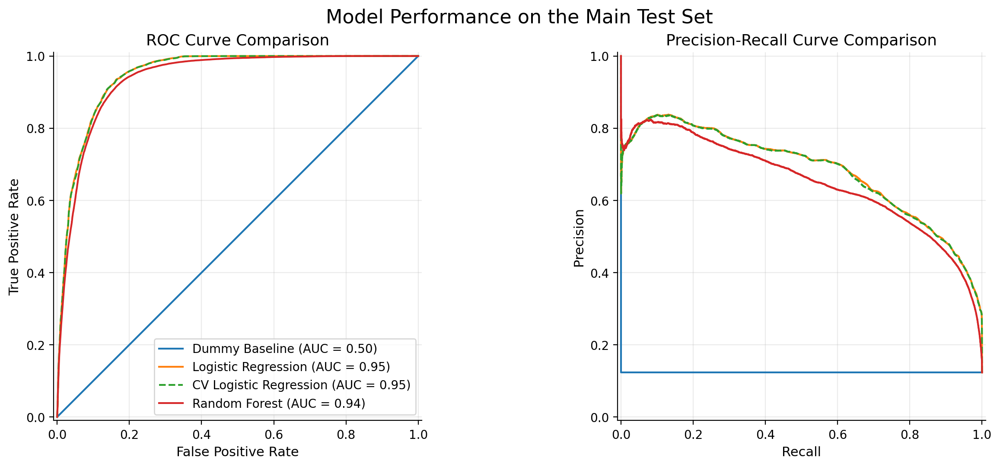

In [79]:
# ROC and Precision-Recall curve comparison side by side
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
for model_name, y_proba in main_probabilities.items():
    roc_display = RocCurveDisplay.from_predictions(
        main_y_test,
        y_proba,
        name=model_name,
        ax=ax_roc
    )

    if model_name == "CV Logistic Regression":
        roc_display.line_.set_linestyle("--")

ax_roc.set_title("ROC Curve Comparison")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")

# Precision-Recall curve
for model_name, y_proba in main_probabilities.items():
    pr_display = PrecisionRecallDisplay.from_predictions(
        main_y_test,
        y_proba,
        name=model_name,
        ax=ax_pr
    )

    if model_name == "CV Logistic Regression":
        pr_display.line_.set_linestyle("--")

ax_pr.set_title("Precision-Recall Curve Comparison")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.legend().remove()

fig.suptitle("Model Performance on the Main Test Set", y=1.05)

plt.show()

#### 6.1.3. Confusion Matrices

The confusion matrices show that the default threshold of 0.50 produces conservative high-heat classifications across all fitted models.

The dummy baseline predicts every observation as non-high heat. It therefore correctly classifies all 648,079 negative observations but misses all 91,004 high-heat events. This confirms that its high accuracy is driven entirely by class imbalance and does not reflect any ability to identify the minority class.

The unregularized logistic regression detects the largest number of high-heat events, with 24,874 true positives, while producing 6,642 false positives. However, it still misses 66,130 actual high-heat observations. This reflects the combination of high precision and low recall observed in the overall metrics: positive predictions are generally reliable, but many high-heat events remain below the default probability cutoff.

The L2-regularized logistic regression is slightly more conservative. It produces fewer false positives than the unregularized model, but also identifies fewer true high-heat events, resulting in 22,929 true positives and 68,075 false negatives. Coefficient shrinkage therefore leads to fewer positive classifications at the default threshold.

The random forest is the most conservative of the three fitted models. It produces the fewest false positives, but also the fewest true positives and the largest number of false negatives. Its additional nonlinear flexibility does not improve detection of high-heat events under the default decision rule.

Overall, the unregularized logistic regression provides the most favourable trade-off at the 0.50 threshold, identifying more high-heat observations while maintaining a relatively low number of false alarms. Nevertheless, all fitted models miss most positive cases, indicating that the default threshold is too restrictive for an application in which failure to detect high-heat exposure is important.


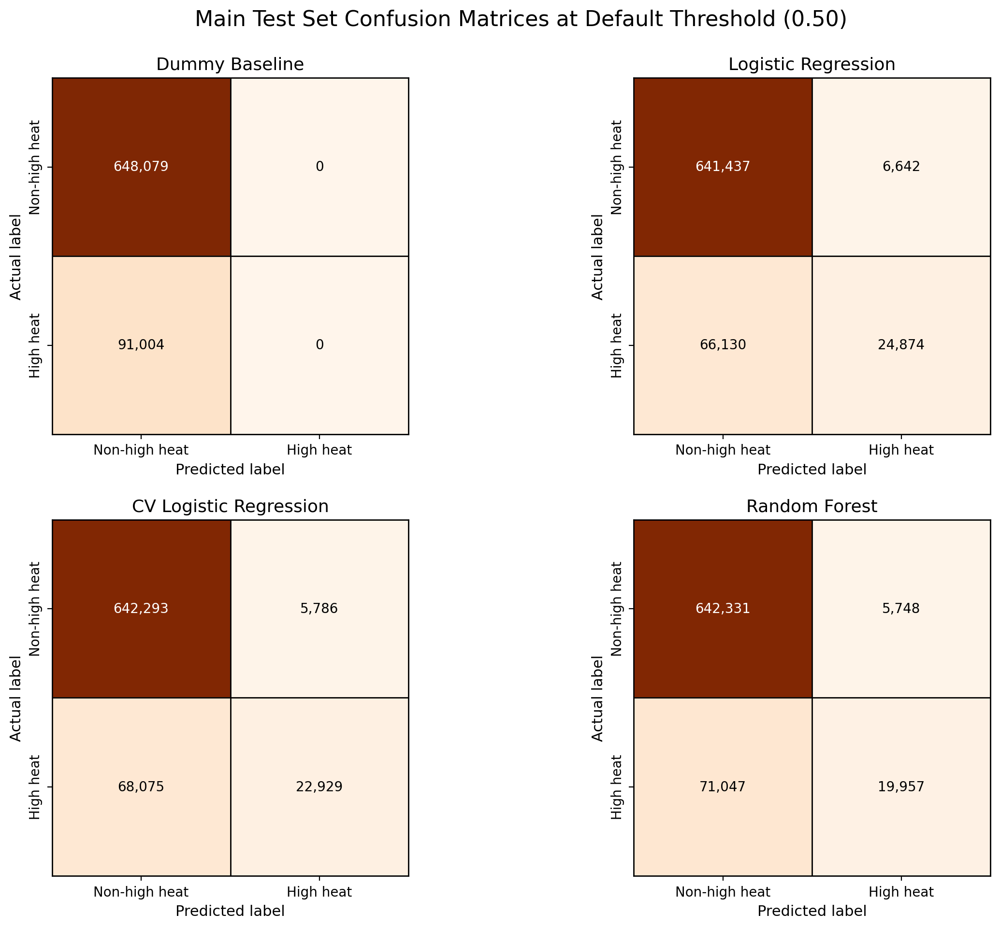

In [80]:
# Confusion matrices side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 9), gridspec_kw={"hspace": 0.05})

vmax = max(cm.to_numpy().max() for cm in main_conf_matrices.values())

axes = axes.flatten()

for ax, (model_name, cm) in zip(axes, main_conf_matrices.items()):
    cm = cm.to_numpy()

    ax.imshow(cm, cmap="Oranges", vmin=0, vmax=vmax)

    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Non-high heat", "High heat"])
    ax.set_yticklabels(["Non-high heat", "High heat"], rotation=90, va="center")

    # Internal cell borders
    ax.axhline(0.5, color="black", linewidth=1)
    ax.axvline(0.5, color="black", linewidth=1)

    # Outer border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.grid(False)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:,}",
                ha="center", va="center",
                color="white" if cm[i, j] > vmax / 2 else "black"
            )

fig.suptitle("Main Test Set Confusion Matrices at Default Threshold (0.50)", y=1.05)

plt.show()

#### 6.1.4. Primary Model Selection

The unregularized logistic regression is selected as the primary model. It provides the strongest overall performance among the candidate specifications, with the highest ROC-AUC and PR-AUC and the most favourable balanced accuracy, recall, and F1-score at the default threshold. Although the differences from the L2-regularized logistic regression are small, the unregularized model also offers the most direct interpretation of coefficient directions, magnitudes, and odds ratios.

The L2-regularized logistic regression produces almost identical ROC and precision–recall performance, indicating that coefficient shrinkage does not materially improve probability ranking. It is therefore retained as a supporting specification for assessing whether the identified relationships remain stable under regularization rather than as the primary model.

The random forest performs substantially better than the dummy baseline but does not improve upon either logistic specification. Its lower ROC-AUC and PR-AUC provide no evidence that the additional nonlinear flexibility yields a clear predictive advantage with the selected features. It is retained as a nonlinear robustness comparison through Gini-based feature importance.

The primary model is selected mainly on the basis of threshold-independent probability ranking and interpretability. ROC-AUC and PR-AUC evaluate model performance across the full range of possible thresholds and are therefore unaffected by the choice of a single classification cutoff. Although tuning a separate threshold for each model could alter threshold-dependent measures such as recall, precision, F1-score, and balanced accuracy, this would be necessary primarily if the final model were selected for a specific operational classification objective. In the present analysis, threshold tuning is instead used to refine the decision rule of the already selected interpretable model. The unregularized logistic-regression probabilities are therefore used for subsequent time-aware classification-threshold tuning.


In [81]:
selected_model_name = "Logistic Regression"
selected_model_pipeline = log_reg_pipeline
print(f"{selected_model_name} selected as the primary model successfully.")

Logistic Regression selected as the primary model successfully.


### 6.2. Decision-Threshold Tuning

The primary output of this analysis is an interpretable ranking of urban heat risk drivers. Beyond ranking, however, the selected model is also intended to support an operational decision: issuing a heat alert. This requires converting predicted probabilities into a binary decision, which in turn requires choosing a classification threshold.

The default threshold of $0.5$ implicitly treats false positives and false negatives as equally costly. In a heat-alert setting this assumption does not hold: a false negative means no warning is issued ahead of a dangerous heat exposure, whereas a false positive only triggers an unnecessary precaution. Since missing an event is costlier than a false alarm, the threshold should be selected accordingly rather than left at $0.5$.

This cost asymmetry constrains which metric is appropriate for threshold selection. Symmetric metrics such as accuracy, balanced accuracy, and the F1-score weight both error types equally and are therefore inconsistent with the cost structure described above. The relevant alternative is the $F_\beta$-score, which generalizes F1 by assigning recall $\beta^2$ times the relative weight of precision:

$$
F_\beta = (1+\beta^2)\cdot\frac{P \cdot R}{\beta^2 P + R}
$$

where:

* $P$ is precision, the proportion of predicted high-heat observations that are actual high-heat events;
* $R$ is recall, the proportion of actual high-heat events correctly identified by the model;
* $\beta$ controls the relative importance assigned to recall and precision.

At $\beta = 1$, precision and recall are weighted equally; as $\beta \to \infty$, $F_\beta$ converges to recall alone. Values of $\beta > 1$ therefore penalize missed events more heavily than false alarms, consistent with the asymmetry stated above.

$F_1$, $F_2$, and $F_3$ are computed jointly across the threshold grid to make the resulting precision–recall trade-off visible at each level of $\beta$. The value of $\beta$ used for the final threshold, however, is fixed in advance from the cost reasoning above, rather than chosen after observing which score produces the most favorable result — doing the latter would reintroduce, through model selection, the same symmetric bias the $F_\beta$-score is meant to avoid. 

Because missed high-heat events are considered more consequential than false alarms, recall should receive greater importance than precision. At the same time, false alerts remain operationally relevant, making an objective dominated almost entirely by recall inappropriate. The $F_2$-score $(\beta=2)$ is therefore adopted as the primary threshold-selection criterion because it represents a moderate preference for recall, while $F_1$ and $F_3$ are reported as sensitivity analyses.

A more rigorous alternative to choosing $\beta$ is to specify the relative costs of the two classification errors directly. For a well-calibrated classifier, the cost-minimizing threshold is:

$$
t^* = \frac{c_{FP}}{c_{FP} + c_{FN}}
$$

where:

* $t^*$ is the cost-minimizing classification threshold;
* $c_{FP}$ is the cost of issuing a false alert;
* $c_{FN}$ is the cost of failing to detect a high-heat event.

As the relative cost of false negatives increases, $t^*$ decreases. The model consequently classifies more observations as high heat, increasing recall at the cost of more false alarms.

A cost ratio of $c_{FP}:c_{FN} = 1:4$, for instance, implies $t^{*} = 0.20$. Given that such cost estimates are necessarily approximate in this setting, $t^{*}$ is used here not as a replacement for the $F_\beta$-based threshold, but as an independent check on it: if $t^{*}$ falls close to the threshold that maximizes the chosen $F_\beta$, this indicates that $\beta$ is a reasonable proxy for the underlying cost structure, and the two thresholds can be reported jointly to support the final choice.

#### 6.2.1. Time-Aware Out-of-Fold Predictions

The classification threshold is selected using time-aware out-of-fold predictions generated from the training data, following the same temporal validation principle used to evaluate the regularization parameter $C$ in [5.6.6. Regularized Logistic Regression](#566-regularized-logistic-regression). This approach provides a more reliable estimate of performance on unseen observations than predictions obtained by evaluating a model on the same data used for its estimation.

With in-sample predictions, each observation is scored by a model that has already used its outcome during fitting. The resulting probabilities may therefore be overly confident, leading to optimistic estimates of precision and recall and, consequently, to a threshold that may not generalize well to new data. Out-of-fold predictions avoid this problem. The training period is divided into sequential folds, and each validation observation is scored by a model fitted only on earlier observations. No observation is therefore evaluated by a model that has seen its own outcome, and the chronological ordering of the data is preserved.

The resulting out-of-fold probabilities approximate the conditions under which the final model will be applied to unseen data. They are therefore used to evaluate candidate thresholds and compare the associated precision–recall trade-offs.

In [82]:
# Empty array for validation probabilities
# The initial temporal block remains empty because no earlier data exist
oof_proba = np.full(len(main_X_train_cv), np.nan)
oof_fold = np.full(len(main_X_train_cv), -1)

# Generate probabilities for each future validation period
for fold, (train_idx, validation_idx) in enumerate(
    time_cv_splits,
    start=1
):
    fold_model = clone(selected_model_pipeline)

    fold_model.fit(
        main_X_train_cv.iloc[train_idx],
        main_y_train_cv.iloc[train_idx],
        model__sample_weight=main_sample_weight_train_cv.iloc[train_idx]
    )

    oof_proba[validation_idx] = fold_model.predict_proba(
        main_X_train_cv.iloc[validation_idx]
    )[:, 1]

    oof_fold[validation_idx] = fold

# Keep only observations that belonged to a validation fold
oof_mask = ~np.isnan(oof_proba)

oof_y_true = (
    main_y_train_cv
    .iloc[np.flatnonzero(oof_mask)]
    .to_numpy()
)

oof_y_proba = oof_proba[oof_mask]
oof_dates = ordered_datetimes.iloc[np.flatnonzero(oof_mask)]
oof_fold_labels = oof_fold[oof_mask]

# Confirm that every retained observation has one valid OOF probability
expected_oof_rows = sum(
    len(validation_idx)
    for _, validation_idx in time_cv_splits
)

assert oof_mask.sum() == expected_oof_rows
assert np.isfinite(oof_y_proba).all()
assert ((oof_y_proba >= 0) & (oof_y_proba <= 1)).all()

print("Time-aware out-of-fold probabilities generated successfully.")

Time-aware out-of-fold probabilities generated successfully.


#### 6.2.2. Optimal Thresholds and Sensitivity Analysis

The left panel shows how the threshold that maximizes the $F_\beta$-score changes as greater importance is assigned to recall. The optimal threshold decreases from $0.154$ for $F_1$ to $0.104$ for $F_2$ and $0.030$ for $F_3$. This pattern is expected: increasing $\beta$ favours the detection of a larger proportion of high-heat events and therefore produces a more permissive classification rule. The selected $F_2$ threshold lies between the more conservative $F_1$ solution and the substantially more aggressive $F_3$ solution, consistently with the intended moderate preference for recall. All three optimal thresholds are considerably below the default cutoff of $0.50$, indicating that the default decision rule is poorly aligned with the asymmetric objective of the analysis.

The right panel provides a cost-based interpretation of the selected threshold. As the cost of a false negative increases relative to that of a false positive, the cost-minimizing threshold $t^*$ decreases. The selected $F_2$ threshold of approximately $0.104$ corresponds numerically to a false-negative cost about $8.6$ times the false-positive cost:

$$
\frac{c_{FN}}{c_{FP}} =
\frac{1-t^*}{t^*} =
\frac{1-0.104}{0.104}
\approx 8.6.
$$

The proximity of the $F_2$ threshold to the cost-based thresholds associated with cost ratios between approximately $1{:}8$ and $1{:}10$ supports its interpretation as a recall-oriented decision rule. This comparison is used only to interpret the selected threshold and assess whether it is consistent with a strong preference for avoiding false negatives. It does not imply that the true false-negative cost is exactly $8.6$ times the false-positive cost, since that conclusion would require well-calibrated probabilities and independently justified error costs.

By comparison, $F_1$ assigns equal importance to precision and recall and therefore does not fully reflect the asymmetric decision objective. Its optimal threshold of $0.154$ corresponds numerically to a more moderate implied cost ratio of approximately $1{:}5.5$. Conversely, the $F_3$ threshold of $0.030$ implies a cost ratio of approximately $1{:}32.6$, representing a substantially more aggressive alert policy in which avoiding missed events dominates the cost of false alarms. The $F_2$ threshold therefore provides an intermediate decision rule: it gives clear priority to recall without requiring the extreme cost asymmetry implied by the $F_3$ solution.


In [83]:
# Candidate probability thresholds
thresholds = np.linspace(0.01, 0.99, 199)

threshold_rows = []

for threshold in thresholds:
    oof_y_pred = (oof_y_proba >= threshold).astype(int)

    threshold_rows.append({
        "model": selected_model_name,
        "threshold": threshold,
        "f1": fbeta_score(oof_y_true, oof_y_pred, beta=1, zero_division=0),
        "f2": fbeta_score(oof_y_true, oof_y_pred, beta=2, zero_division=0),
        "f3": fbeta_score(oof_y_true, oof_y_pred, beta=3, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_rows)

print("F1, F2, and F3 scores for each threshold stored successfully.")

F1, F2, and F3 scores for each threshold stored successfully.


In [84]:
threshold_objectives = {
    "F1-score": "f1",
    "F2-score": "f2",
    "F3-score": "f3",
}

threshold_objective = "F2-score"

threshold_summary = pd.DataFrame([
    {
        "objective": objective_name,
        "metric": metric_column,
        "threshold": float(
            threshold_results.loc[
                threshold_results[metric_column].idxmax(),
                "threshold"
            ]
        ),
        "score": float(threshold_results[metric_column].max()),
    }
    for objective_name, metric_column in threshold_objectives.items()
])

selected_thresholds = dict(zip(
    threshold_summary["objective"],
    threshold_summary["threshold"]
))
selected_threshold = selected_thresholds[threshold_objective]

print("F-score-optimal thresholds stored successfully.")
print(f"Selected {threshold_objective} threshold: {selected_threshold:.3f}")
display(threshold_summary.round({"threshold": 3, "score": 4}))

F-score-optimal thresholds stored successfully.
Selected F2-score threshold: 0.104


,objective,metric,threshold,score
0,F1-score,f1,0.154,0.4701
1,F2-score,f2,0.104,0.6024
2,F3-score,f3,0.030,0.7100


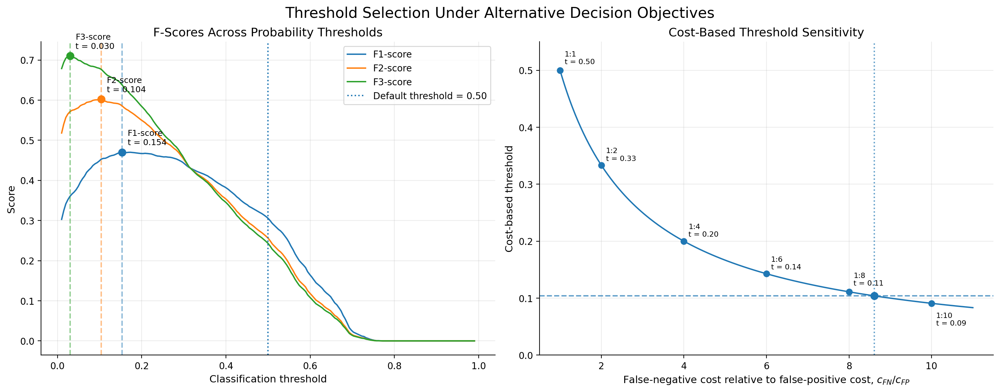

In [85]:
equivalent_cost_ratio = (1 - selected_threshold) / selected_threshold
max_cost_ratio = max(10, np.ceil(equivalent_cost_ratio) + 2)
cost_ratios = np.linspace(1, max_cost_ratio, 300)
cost_thresholds = 1 / (1 + cost_ratios)

reference_ratios = np.array([1, 2, 4, 6, 8, 10])
reference_thresholds = 1 / (1 + reference_ratios)
label_offsets = {
    1: (5, 7),
    2: (5, 5),
    4: (5, 5),
    6: (5, 5),
    8: (5, 7),
    10: (5, -24),
}

fig, (ax_score, ax_cost) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left panel: F-beta scores across thresholds
for row in threshold_summary.itertuples(index=False):
    line, = ax_score.plot(
        threshold_results["threshold"],
        threshold_results[row.metric],
        label=row.objective
    )

    ax_score.scatter(
        row.threshold, row.score,
        color=line.get_color(), s=60, zorder=3
    )

    ax_score.axvline(row.threshold, color=line.get_color(), linestyle="--", alpha=0.5)

    ax_score.annotate(
        f"{row.objective}\nt = {row.threshold:.3f}",
        xy=(row.threshold, row.score), xytext=(6, 8),
        textcoords="offset points", fontsize=9
    )

ax_score.axvline(0.5, linestyle=":", linewidth=1.5, label="Default threshold = 0.50")

ax_score.set(
    xlabel="Classification threshold",
    ylabel="Score",
    title="F-Scores Across Probability Thresholds"
)

ax_score.legend()

# Right panel: cost-based thresholds
cost_line, = ax_cost.plot(
    cost_ratios, cost_thresholds,
    label=r"$t^* = 1/(1+c_{FN}/c_{FP})$"
)

ax_cost.scatter(
    reference_ratios, reference_thresholds,
    color=cost_line.get_color(), s=40, zorder=3
)

for ratio, threshold in zip(reference_ratios, reference_thresholds):
    ax_cost.annotate(
        f"1:{ratio}\nt = {threshold:.2f}",
        xy=(ratio, threshold), xytext=label_offsets[ratio],
        textcoords="offset points", fontsize=8
    )

# F2-optimal threshold
ax_cost.axhline(selected_threshold, linestyle="--",alpha=0.7, label=f"F2-optimal threshold = {selected_threshold:.3f}"
)

# Equivalent cost ratio
ax_cost.axvline(equivalent_cost_ratio, linestyle=":", alpha=0.7, label=(
    "Equivalent cost ratio "
    rf"$c_{{FP}}:c_{{FN}} \approx 1:{equivalent_cost_ratio:.1f}$"
))

ax_cost.scatter(
    equivalent_cost_ratio, selected_threshold,
    s=60, zorder=4
)

ax_cost.set(
    xlabel=("False-negative cost relative to false-positive cost, $c_{FN}/c_{FP}$"),
    ylabel="Cost-based threshold",
    title="Cost-Based Threshold Sensitivity"
)

ax_cost.set_xlim(0.5, max_cost_ratio + 0.5)
ax_cost.set_ylim(0, 0.55)

fig.suptitle("Threshold Selection Under Alternative Decision Objectives", y=1.05)

plt.show()

#### 6.2.3. Performance Metrics Across Alternative Thresholds

The table compares the threshold-dependent performance metrics of the selected logistic regression at the default cutoff of $0.50$ and at the thresholds that maximize $F_1$, $F_2$, and $F_3$. Because the fitted model and predicted probabilities remain unchanged, differences across rows arise exclusively from the classification threshold.

At the default threshold, precision is high at $78.9%$, but recall is only $27.3%$, indicating that most high-heat events remain undetected. The $F_1$-optimal threshold increases recall to $70.0%$, while precision falls to $35.4%$. The selected $F_2$ threshold further increases recall to $77.2%$, with precision of $32.1%$, providing an intermediate balance between event detection and false alerts. By comparison, the $F_3$ threshold raises recall to $93.7%$, but reduces precision to $22.3%$, reflecting a substantially more aggressive classification rule.

As the threshold decreases, overall accuracy falls from $90.2%$ at the default cutoff to $83.0%$ under the $F_2$ rule. This occurs because the majority of observations belong to the non-high-heat class, so the additional false positives generated by a lower threshold have a strong effect on overall accuracy. Balanced accuracy, however, rises from $63.2%$ to $80.4%$ because the improvement in high-heat recall more than compensates for the reduction in specificity when the two classes are weighted equally.

Relative to $F_1$, the $F_2$ threshold improves recall by approximately $7.2$ percentage points and balanced accuracy by $1.8$ points, while accuracy decreases by only $2.6$ points. It therefore provides a more favourable trade-off for a recall-oriented application. Moving from $F_2$ to $F_3$, by contrast, reduces accuracy by a further $13.3$ percentage points, while balanced accuracy increases by only $0.1$ point. This indicates that balanced performance has effectively plateaued: the additional gain in recall is obtained mainly through a substantial increase in false positives and a marked reduction in specificity.

The $F_2$-optimal threshold therefore produces a marked improvement in the detection of high-heat events relative to the default cutoff and improves the recall-oriented trade-off relative to $F_1$, without accepting the disproportionate loss in accuracy, precision, and specificity associated with the $F_3$ solution.

In [86]:
best_threshold_rows = []

for row in threshold_summary.itertuples(index=False):
    best_results = evaluate_classifier(
        y_true=oof_y_true,
        y_proba=oof_y_proba,
        model_name=selected_model_name,
        threshold=row.threshold,
    )

    best_results["optimized_for"] = row.objective
    best_threshold_rows.append(best_results)

threshold_comparison = pd.concat(best_threshold_rows, ignore_index=True)

default_row = main_metrics[selected_model_name].copy()
default_row["optimized_for"] = "Default threshold"

display_comparison = pd.concat(
    [default_row, threshold_comparison],
    ignore_index=True
)

display_comparison = display_comparison[[
    "model",
    "optimized_for",
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "f2",
    "f3",
    "predicted_positive_rate",
]].reset_index(drop=True)

print("Default and F-score-optimal classification thresholds:")
display(display_comparison.round(4))

Default and F-score-optimal classification thresholds:


,model,optimized_for,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,f2,f3,predicted_positive_rate
0,Logistic Regression,Default threshold,0.5000,0.9015,0.6315,0.7892,0.2733,0.9898,0.4060,0.3144,0.2924,0.0426
1,Logistic Regression,F1-score,0.1535,0.8562,0.7861,0.3538,0.7004,0.8718,0.4701,0.5856,0.6379,0.1803
2,Logistic Regression,F2-score,0.1040,0.8302,0.8041,0.3205,0.7721,0.8360,0.4530,0.6024,0.6768,0.2194
3,Logistic Regression,F3-score,0.0298,0.6969,0.8051,0.2230,0.9374,0.6728,0.3603,0.5714,0.7100,0.3828


#### 6.2.4. Confusion Matrices Across Alternative Thresholds

The confusion matrices confirm the trade-offs identified in the preceding metric comparison. The default threshold produces very few false positives but misses a large share of high-heat events. Lowering the threshold progressively reduces false negatives, while increasing the number of false alerts.

The $F_1$ threshold improves event detection but remains relatively conservative, whereas the $F_3$ threshold nearly eliminates missed events at the cost of a substantial increase in false positives. The $F_2$ threshold provides a more balanced intermediate solution: it detects most high-heat events without adopting the markedly more aggressive classification behaviour associated with $F_3$.

These results support the use of the $F_2$-optimal threshold as the final decision rule for this application, since it reflects the priority assigned to avoiding missed high-heat events while maintaining a more manageable false-alert rate.

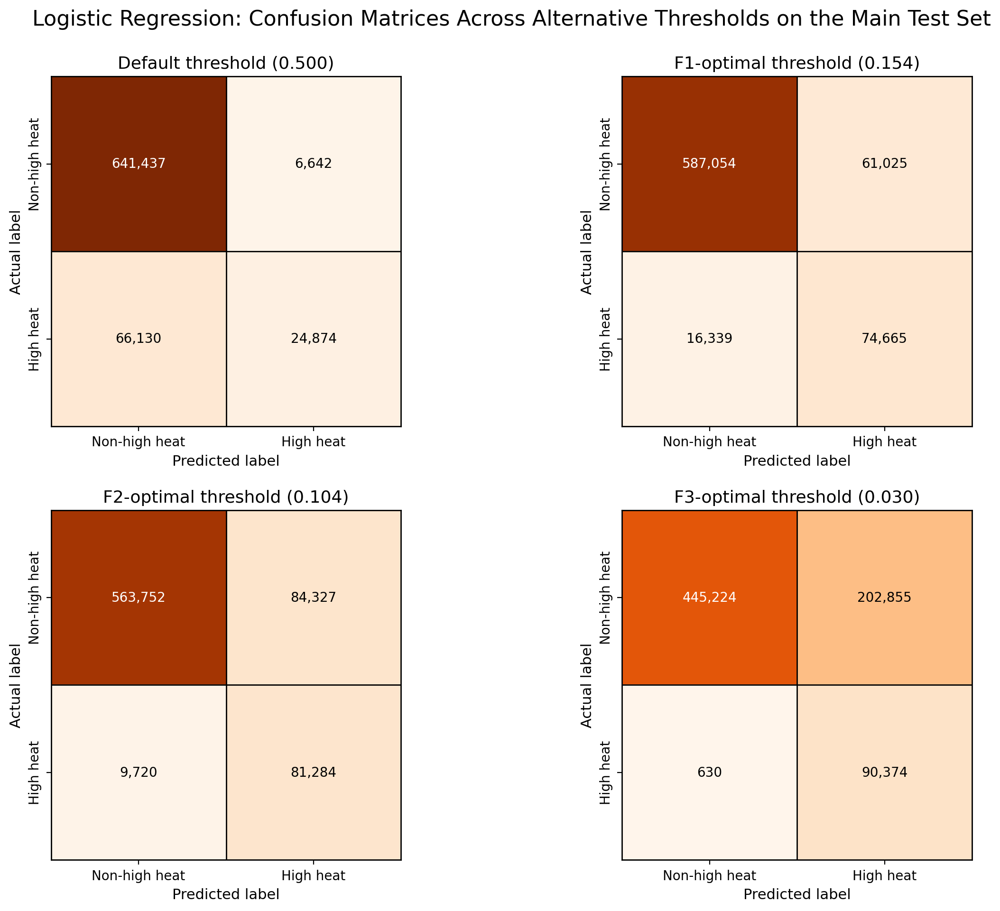

In [87]:
# Confusion matrices at the default and optimized thresholds
final_conf_matrices = {"Default threshold (0.500)": main_conf_matrices[selected_model_name]}

for objective_name, threshold in selected_thresholds.items():
    short_name = objective_name.replace("-score", "")

    final_conf_matrices[
        f"{short_name}-optimal threshold ({threshold:.3f})"
    ] = make_confusion_matrix(
        y_true=main_y_test,
        y_proba=main_probabilities[selected_model_name],
        threshold=threshold,
    )

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 9), gridspec_kw={"hspace": 0.05})

axes = axes.flatten()

vmax = max(cm.to_numpy().max() for cm in final_conf_matrices.values())

for ax, (threshold_name, cm_df) in zip(axes, final_conf_matrices.items()):
    cm = cm_df.to_numpy()

    ax.imshow(
        cm, cmap="Oranges",
        vmin=0, vmax=vmax
    )

    ax.set_title(threshold_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Non-high heat", "High heat"])
    ax.set_yticklabels(["Non-high heat", "High heat"], rotation=90, va="center")

    # Internal cell borders
    ax.axhline(0.5, color="black", linewidth=1)
    ax.axvline(0.5, color="black", linewidth=1)

    # Outer border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.grid(False)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:,}",
                ha="center", va="center",
                color=(
                    "white"
                    if cm[i, j] > vmax / 2
                    else "black"
                )
            )

fig.suptitle(f"{selected_model_name}: Confusion Matrices Across Alternative Thresholds on the Main Test Set", y=1.05)

plt.show()

### 6.3. Main Model Interpretation

The coefficient plots summarize the direction and relative magnitude of the predictors in the main logistic regression. Positive coefficients are associated with higher predicted heat risk, while negative coefficients are associated with lower predicted heat risk, holding the other variables constant. Numerical predictors are standardized, so their coefficients represent a one-standard-deviation increase. City coefficients instead represent differences relative to Amsterdam, the omitted reference category.

Temporal variables dominate the model. `month_cos` is the strongest predictor, with a coefficient of -2.19, followed by `month_sin` at -1.37. The hour components are also important, with coefficients of -1.09 for `hour_cos` and -0.70 for `hour_sin`. Because month and hour are represented through sine–cosine pairs, the individual signs should not be read as simple increasing or decreasing effects. Taken jointly, their large magnitudes show that annual seasonality is the main source of variation in predicted heat risk, followed by the daily cycle.

Basel is the second-ranked coefficient overall, with a value of -1.80 relative to Amsterdam. This indicates a substantial residual difference between Basel and Amsterdam under otherwise comparable temporal and measurement conditions. It does not necessarily mean that Basel is systematically colder or has lower absolute heat exposure, particularly because high heat is defined relative to each city’s own temperature distribution. The coefficient may instead reflect differences in station composition, local climatic patterns, data coverage, or monitoring practices that are not fully captured by the other predictors. Berlin, at 0.03, and Birmingham, at approximately -0.01, show almost no remaining difference from Amsterdam.

Among the remaining numerical predictors, `measurement_interval_min` is the most relevant, ranking sixth with a coefficient of 0.68. Longer measurement intervals are therefore associated with higher predicted heat risk after controlling for the other predictors. Since this variable describes data collection rather than the physical environment, the result is more likely to reflect monitoring or sample-composition differences than a direct heat mechanism.

Sensor height, centered longitude, centered latitude, and weekend status all have coefficients close to zero. Their contribution is therefore limited once seasonality, time of day, and city-level differences are included. In particular, the near-zero weekend coefficient suggests no meaningful systematic difference between weekday and weekend heat risk.

Overall, the model identifies annual seasonality and the daily cycle as the main predictors of high-heat events. Basel also shows a substantial city-specific difference relative to Amsterdam, while most spatial and measurement characteristics add comparatively little. The ranking combines standardized numerical coefficients and categorical city effects on the same log-odds scale, but comparisons between these two predictor types should remain cautious because they represent different kinds of changes. These results describe conditional associations within the fitted model and should not be interpreted causally.

In [88]:
# Interpret the final logistic-regression model
preprocessor = selected_model_pipeline.named_steps["preprocessor"]
encoder = preprocessor.named_transformers_["categorical"].named_steps["encoder"]
reference_city = encoder.categories_[0][encoder.drop_idx_[0]]

log_reg_interpretation = (
    get_logistic_coefficients(
        pipeline=selected_model_pipeline,
        model_name=selected_model_name
    )
    .assign(
        direction=lambda df: np.select(
            [df["coefficient"] > 0, df["coefficient"] < 0],
            ["Higher odds", "Lower odds"],
            default="No association"
        ),
        interpretation_unit=lambda df: np.where(
            df["is_city_effect"],
            f"Relative to {reference_city}",
            "Per one standard-deviation increase"
        )
    )
)

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,interpretation_unit,abs_coefficient
0,Logistic Regression,month_cos,-2.193,0.112,-88.8,per 1-SD increase or binary change,2.193
1,Logistic Regression,City: Basel,-1.799,0.165,-83.5,relative to Amsterdam,1.799
2,Logistic Regression,month_sin,-1.366,0.255,-74.5,per 1-SD increase or binary change,1.366
3,Logistic Regression,hour_cos,-1.086,0.338,-66.2,per 1-SD increase or binary change,1.086
4,Logistic Regression,hour_sin,-0.701,0.496,-50.4,per 1-SD increase or binary change,0.701
5,Logistic Regression,measurement_interval_min,0.683,1.979,97.9,per 1-SD increase or binary change,0.683
6,Logistic Regression,sensor_height_m,0.049,1.051,5.1,per 1-SD increase or binary change,0.049
7,Logistic Regression,lon_centered,0.035,1.035,3.5,per 1-SD increase or binary change,0.035
8,Logistic Regression,City: Berlin,0.026,1.026,2.6,relative to Amsterdam,0.026
9,Logistic Regression,lat_centered,0.018,1.018,1.8,per 1-SD increase or binary change,0.018


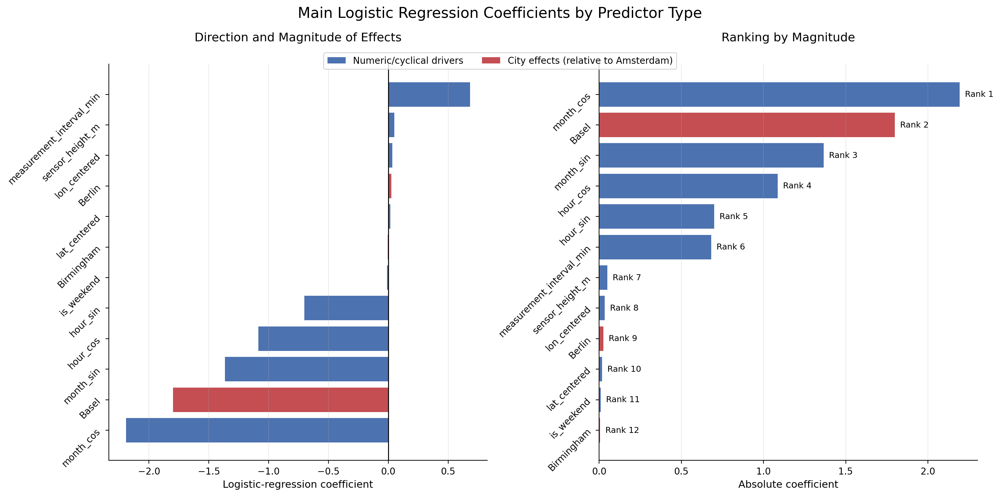

In [89]:
plot_driver_importance(
    plot_data=_prepare_driver_plot_data(log_reg_interpretation),
    title="Main Logistic Regression Coefficients by Predictor Type",
    signed_value_label="Logistic-regression coefficient",
    importance_label="Absolute coefficient",
    reference_city=reference_city,
    figsize=(15, 7),
)

### 6.4. Model Diagnostics

This section checks how the selected logistic-regression model behaves after threshold tuning. The goal is to verify whether performance is stable across cities, months, hours, and different data subsets, and to identify where prediction errors are concentrated. Because several diagnostics use hard class labels rather than only predicted probabilities, they must be computed with the selected $F_2$-optimal threshold rather than the default $0.50$ cutoff. The resulting error patterns and performance metrics therefore depend on this threshold choice and should be interpreted as diagnostics of the final decision rule, not just of the fitted probability model.

#### 6.4.1. City-Level Diagnostics

City-level diagnostics are used to check whether the single pooled model performs consistently across the selected cities. This does not involve training separate city-specific models. Instead, the already trained pooled logistic regression model is applied to the test set, and performance metrics are computed separately for each city.

As already stated, the four cities differ substantially in sample size: Basel accounts for 580,646 of the test observations, compared with 86,229 for Birmingham, 65,575 for Berlin, and only 6,633 for Amsterdam. Basel therefore dominates the pooled test set and drives most of the aggregate metrics reported earlier, while Amsterdam contributes a comparatively small and noisier sample. Observed high-heat rates also vary somewhat across cities, from 11.5% in Berlin to 16.7% in Amsterdam, even though the target is defined relative to each city's own training-period distribution; this indicates that the 2022 test year did not reproduce the training-period quantile exactly in every city, with Amsterdam showing the largest deviation. At the selected threshold of 0.104, predicted high-heat rates are higher than observed rates in all four cities, ranging from roughly 1.8 to 2.1 times the observed rate. This is expected given the recall-oriented threshold chosen for the alert-system objective and should not be read as a city-specific miscalibration.

Basel, Berlin, and Birmingham perform similarly to one another across all metrics, with ROC-AUC between 0.943 and 0.950, PR-AUC between 0.638 and 0.703, and F1-scores between 0.595 and 0.644. Amsterdam is the consistent outlier, scoring lowest on every metric reported: ROC-AUC (0.889), PR-AUC (0.567), accuracy (0.788), balanced accuracy (0.805), precision (0.431), recall (0.831), specificity (0.779), and F1-score (0.567), alongside the highest log loss (0.302). Because this gap appears uniformly across both threshold-independent metrics (ROC-AUC, PR-AUC, log loss) and threshold-dependent metrics (precision, recall, F1), it is unlikely to be an artifact of the chosen threshold. The most plausible explanation is sample size: with under 7,000 test observations, Amsterdam's metrics are estimated on a much smaller and therefore noisier sample than the other three cities, and the pooled model has comparatively little Amsterdam-specific signal to learn from despite the city-balanced training weights.

In [90]:
# Create prediction dataframe for city-level evaluation
test_index = main_X_test.index
selected_prediction_df = main_test_data.loc[
    test_index,
    ["city", "station_number", "datetime"],
].assign(
    y_true=main_y_test.loc[test_index].to_numpy(),
    y_proba=main_probabilities[selected_model_name],
)

# Evaluate selected model by city at the tuned decision threshold
log_reg_city_results = evaluate_by_city(
    df_pred=selected_prediction_df,
    model_name=selected_model_name,
    threshold=selected_threshold
)

Logistic Regression performance by city at threshold 0.1040:


,city,observations,positive_class_pct,model,threshold,log_loss,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,Basel,580646,12.40,Logistic Regression,0.104,0.2022,0.9503,0.7027,0.8777,0.8843,0.5038,0.8931,0.8755,0.6442
1,Birmingham,86229,12.00,Logistic Regression,0.104,0.1930,0.9434,0.6692,0.8560,0.8665,0.4490,0.8804,0.8527,0.5947
2,Berlin,65575,11.51,Logistic Regression,0.104,0.1836,0.9488,0.6378,0.8599,0.8862,0.4472,0.9204,0.8520,0.6019
3,Amsterdam,6633,16.75,Logistic Regression,0.104,0.3017,0.8886,0.5668,0.7876,0.8048,0.4305,0.8308,0.7789,0.5671


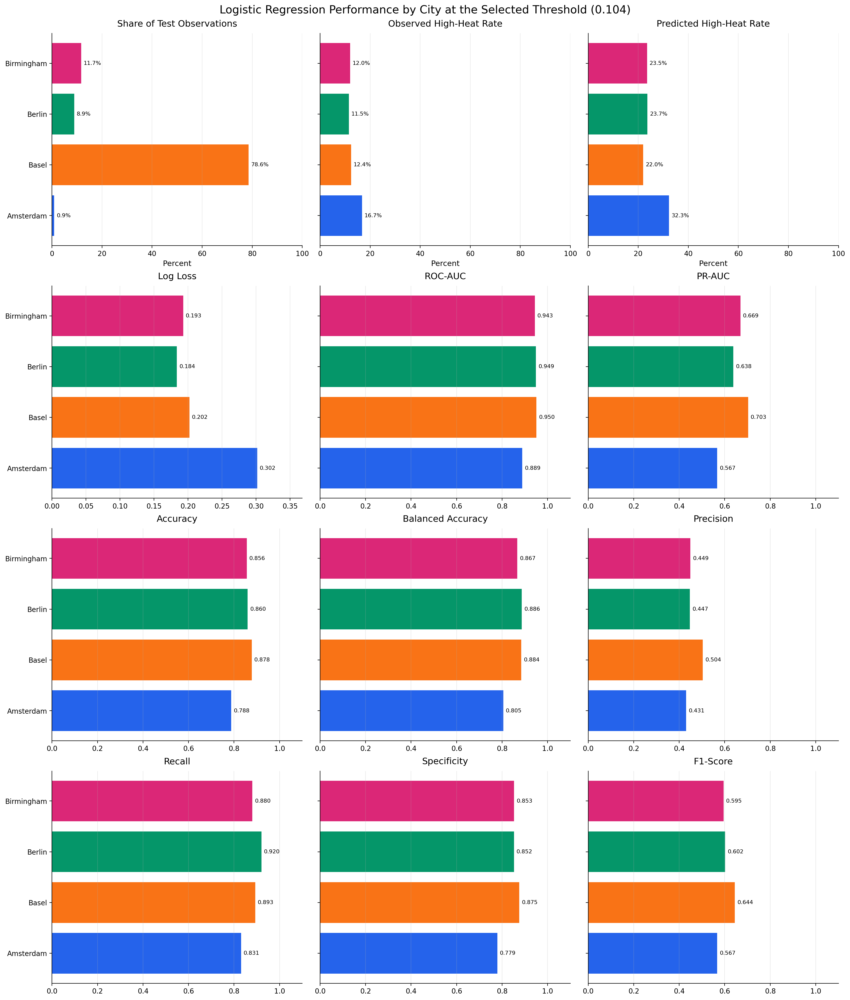

In [91]:
plot_city_performance(
    city_results=log_reg_city_results,
    model_name=selected_model_name,
    threshold=selected_threshold,
    city_colours=CITY_COLORS,
)

#### 6.4.2. Prediction Error Analysis

The error diagnostics show that the selected threshold shifts the model toward detecting high-heat events, resulting in substantially more false positives than false negatives. This is consistent with the F2-based decision rule: the model accepts more false alerts in exchange for reducing missed high-heat events.

Errors are concentrated in the warm season. Misclassification rates increase sharply between May and September, when false positives account for most errors. False negatives remain comparatively limited, although they are present throughout the warmer months. Outside the main heat season, the error rate is close to zero. This suggests that the model identifies the broad seasonal structure correctly but has difficulty distinguishing genuinely high-heat observations from moderately warm conditions during the period of greatest temperature variability.

The hourly pattern is similar. Errors are rare overnight and in the early morning, then rise from the morning onward and remain elevated during daytime and early evening hours. False positives again dominate, indicating that the model frequently assigns high-heat labels during generally warm parts of the day even when the city-specific heat threshold is not exceeded. False negatives become somewhat more visible during the evening and night, but remain much less frequent overall.

The probability-bucket analysis shows that most false positives occur immediately above the selected threshold, particularly between probabilities of 0.1 and 0.3. The misclassification rate then generally decreases as predicted probability increases, indicating that higher-confidence positive predictions are more reliable. False negatives are almost entirely located below the threshold and receive relatively low predicted probabilities.

The boxplots reinforce this pattern. True negatives are concentrated close to zero, while true positives receive the highest probabilities, with a median of approximately 0.41. False negatives lie below the threshold, with a median around 0.06, whereas false positives are mostly low-confidence positive predictions, with a median around 0.20. The model therefore separates the two classes reasonably well, but there is substantial overlap among observations receiving moderate predicted probabilities.

Overall, the main weakness of the tuned classifier is not failure to detect high-heat events, but reduced precision near the decision boundary. The selected threshold successfully limits false negatives, as intended, but generates additional false alerts during warm months and daytime hours. This represents the operational trade-off introduced by the recall-oriented threshold rather than evidence of widespread high-confidence model failure.

In [92]:
err, diagnostic_tables = outcome_share_table(
    df_pred=selected_prediction_df,
    threshold=selected_threshold,
    test_data=main_test_data,
    verbose=False
)

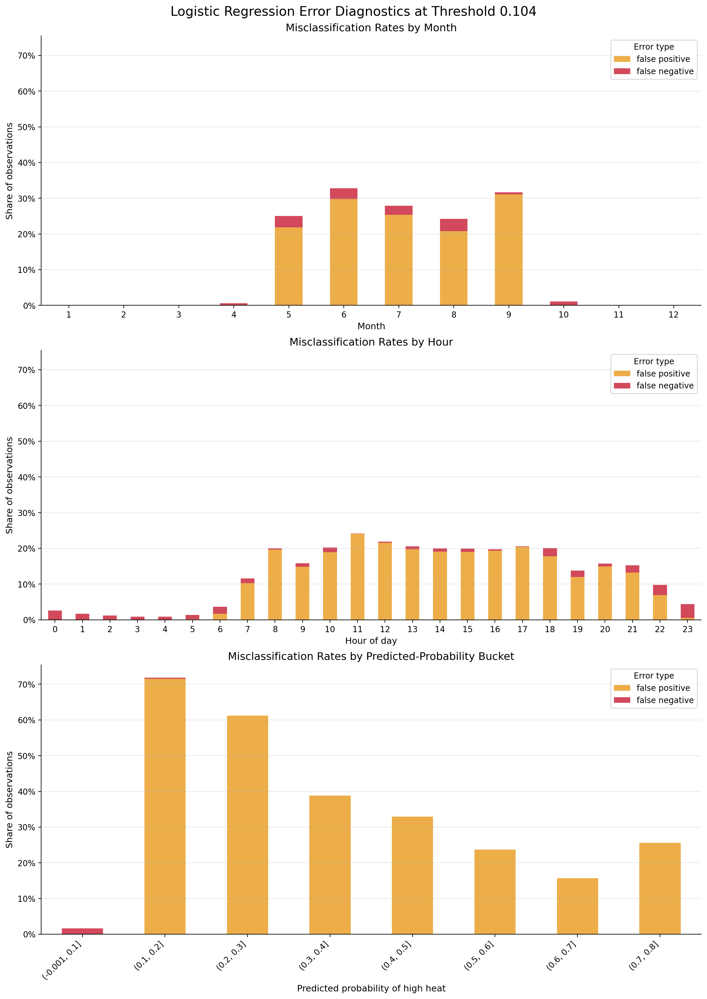

In [93]:
plot_outcome_share_diagnostics(
    df_pred=selected_prediction_df,
    threshold=selected_threshold,
    test_data=main_test_data,
    model_name=selected_model_name,
)

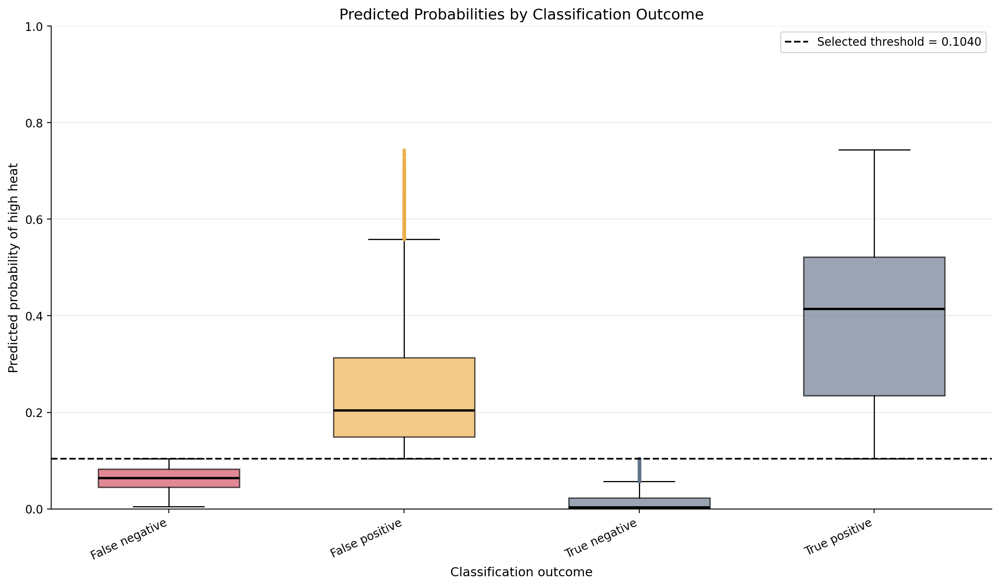

In [94]:
plot_probability_by_outcome(
    err=err,
    threshold=selected_threshold,
    boxplot_kwargs=BOXPLOT_KWARGS,
)

### 6.5. Robustness Checks

This section assesses whether the main findings from the selected logistic-regression model are stable under alternative modelling choices. The goal is not to optimise performance further, but to test whether the identified driver patterns and model conclusions depend strongly on one specific train/test split, target definition, or feature configuration.

So far, the analysis has relied on the main chronological split, the `heat_risk_q90` target, and the full feature set. A driver-focused interpretation is more credible if the main coefficient directions and rankings remain broadly consistent when these choices are varied. The robustness checks therefore compare model performance and coefficient patterns across alternative time splits, alternative heat-risk percentile thresholds, and different feature subsets.

Each robustness check changes one component at a time while keeping the remaining modelling workflow as consistent as possible. This makes it easier to interpret any changes in performance or coefficients as consequences of the tested modelling choice rather than of unrelated changes in the pipeline.

#### 6.5.1. Comparison with Regularized Logistic Regression

The regularized logistic regression is used to check whether the main driver interpretation depends on the unregularized specification. The comparison shows that the strongest predictors remain highly consistent across the two models. In both cases, the cyclical month and hour variables dominate the coefficient ranking, confirming that seasonal and daily temporal structure is the main source of predictive signal.

Regularization mainly shrinks smaller and less stable coefficients toward zero. This is especially visible for the city effects: Basel is the second-largest coefficient in the unregularized model, but becomes much smaller under L2 regularization. Berlin and Birmingham remain close to zero in both specifications. This suggests that the strongest temporal patterns are robust, while some city-specific differences are more sensitive to regularization and should be interpreted cautiously.

The ranking of the largest numeric and cyclical predictors is nevertheless stable. `month_cos`, `month_sin`, `hour_cos`, and `hour_sin` remain among the most important predictors, and their signs are unchanged. `measurement_interval_min` is much less stable: it is positive in the unregularized model, but shrinks strongly and changes sign under L2 regularization. This suggests that its apparent association is sensitive to model specification and should not be treated as a robust driver.

Overall, the regularized model supports the main interpretation from the unregularized logistic regression: high-heat risk is primarily driven by annual seasonality and the daily cycle. At the same time, the shrinkage of city effects indicates that residual between-city differences are less robust than the temporal effects and should not be overinterpreted as standalone causal drivers.

In [95]:
# Extract regularized logistic-regression coefficients
reg_coeffs = get_logistic_coefficients(
    pipeline=cv_log_reg_pipeline,
    model_name="Regularized Logistic Regression",
)

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,interpretation_unit,abs_coefficient
0,Regularized Logistic Regression,month_cos,-2.065,0.127,-87.3,per 1-SD increase or binary change,2.065
1,Regularized Logistic Regression,month_sin,-1.288,0.276,-72.4,per 1-SD increase or binary change,1.288
2,Regularized Logistic Regression,hour_cos,-1.056,0.348,-65.2,per 1-SD increase or binary change,1.056
3,Regularized Logistic Regression,hour_sin,-0.681,0.506,-49.4,per 1-SD increase or binary change,0.681
4,Regularized Logistic Regression,measurement_interval_min,-0.141,0.869,-13.1,per 1-SD increase or binary change,0.141
5,Regularized Logistic Regression,City: Basel,-0.077,0.926,-7.4,relative to Amsterdam,0.077
6,Regularized Logistic Regression,sensor_height_m,0.048,1.049,4.9,per 1-SD increase or binary change,0.048
7,Regularized Logistic Regression,lon_centered,0.034,1.035,3.5,per 1-SD increase or binary change,0.034
8,Regularized Logistic Regression,City: Berlin,0.031,1.032,3.2,relative to Amsterdam,0.031
9,Regularized Logistic Regression,lat_centered,0.017,1.018,1.8,per 1-SD increase or binary change,0.017


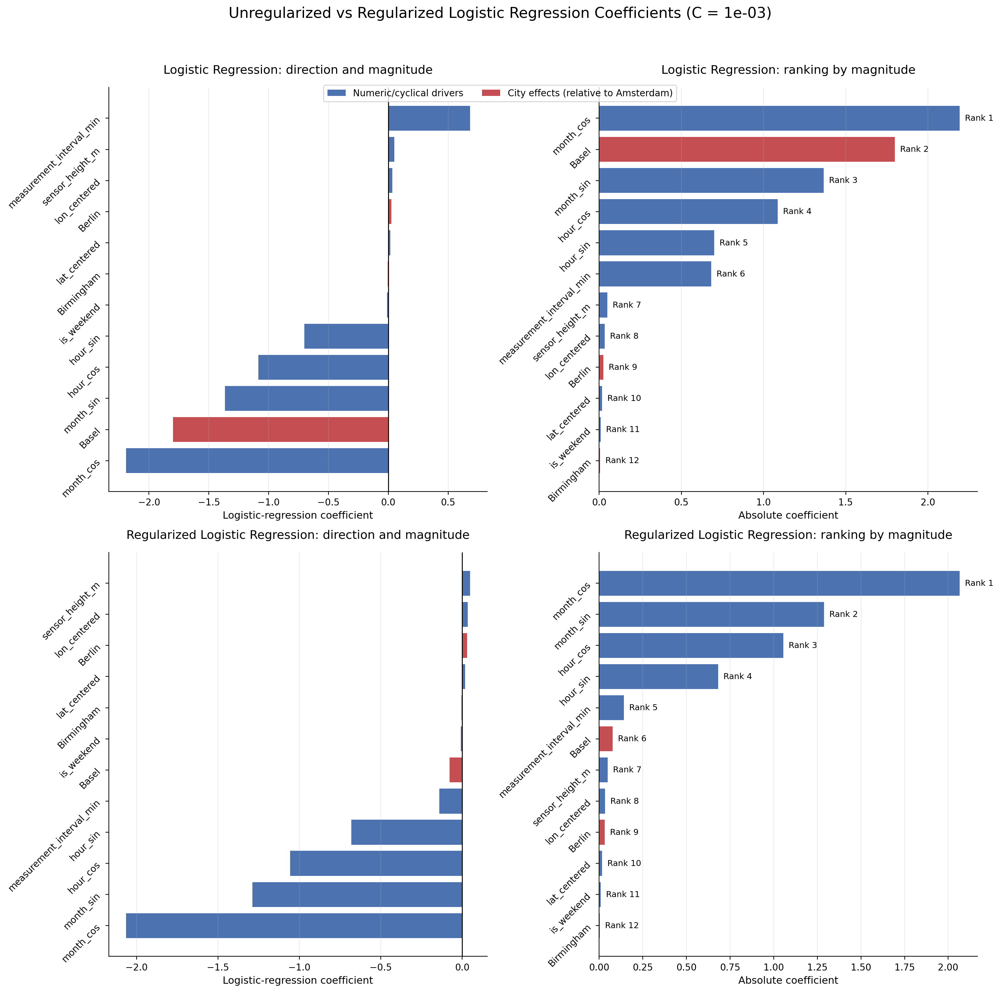

In [96]:
logistic_comparison_coeffs = pd.concat(
    [log_reg_interpretation, reg_coeffs],
    ignore_index=True,
)

plot_driver_importance(
    plot_data=_prepare_driver_plot_data(logistic_comparison_coeffs),
    title=f"Unregularized vs Regularized Logistic Regression Coefficients (C = {best_C:.0e})",
    signed_value_label="Logistic-regression coefficient",
    importance_label="Absolute coefficient",
    reference_city=reference_city,
    figsize=(15, 14),
)

cleanup_vars("logistic_comparison_coeffs", verbose=False)

#### 6.5.2. Comparison with Random Forest

The random forest is used as a nonlinear comparison to assess whether the main driver ranking changes when the model is allowed to capture nonlinear relationships and interactions. Unlike logistic regression, the random forest does not provide signed coefficients, so the comparison focuses on feature-importance rankings rather than direction of association.

The two models identify a very similar set of dominant predictors. In both cases, the cyclical temporal variables are ranked as the most important drivers: `month_cos`, `month_sin`, `hour_cos`, and `hour_sin` remain at the top of the ranking. This supports the conclusion that annual seasonality and the daily cycle carry most of the predictive signal for high-heat risk.

The random forest gives comparatively little importance to most city indicators and measurement variables. Basel, which appears as a large city effect in the unregularized logistic regression, receives very low random-forest importance. This suggests that the Basel coefficient in the logistic model should be interpreted cautiously: it may reflect a model-specific adjustment relative to the Amsterdam reference category rather than a robust standalone driver.

Spatial variables and sensor metadata remain secondary in both models. Centered longitude and latitude appear only with small importance, while sensor height, weekend status, and measurement interval contribute little compared with the temporal predictors. The random forest therefore does not provide evidence that strong nonlinear spatial or measurement effects are being missed by the logistic specification.

Overall, the random-forest comparison supports the main interpretation of the logistic model. The dominant driver structure is stable across a linear, interpretable model and a more flexible nonlinear model: high-heat risk is primarily explained by seasonal and daily temporal patterns, while city, spatial, and measurement features play a more limited role.

In [97]:
# Extract random-forest feature importances
rf_importances = get_random_forest_importances(
    pipeline=rf_pipeline,
    model_name="Random Forest",
)

Random Forest feature importances (Gini, sorted by magnitude)


,model,feature,importance
0,Random Forest,month_cos,0.3696
1,Random Forest,month_sin,0.2292
2,Random Forest,hour_cos,0.2156
3,Random Forest,hour_sin,0.1186
4,Random Forest,lon_centered,0.0155
5,Random Forest,lat_centered,0.0132
6,Random Forest,City: Birmingham,0.0090
7,Random Forest,sensor_height_m,0.0089
8,Random Forest,City: Berlin,0.0078
9,Random Forest,is_weekend,0.0065


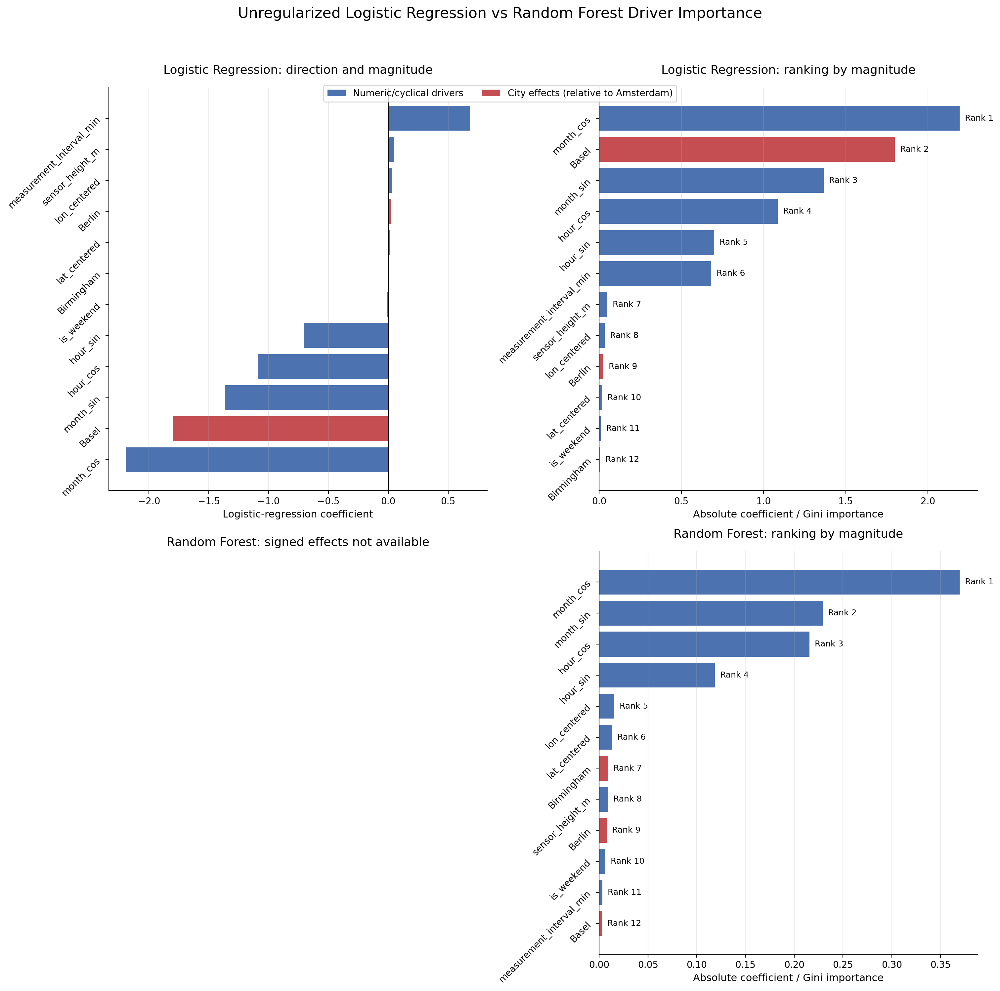

In [98]:
logistic_rf_comparison = pd.concat(
    [
        _prepare_driver_plot_data(log_reg_interpretation),
        _prepare_driver_plot_data(rf_importances),
    ],
    ignore_index=True,
)

plot_driver_importance(
    plot_data=logistic_rf_comparison,
    title="Unregularized Logistic Regression vs Random Forest Driver Importance",
    signed_value_label="Logistic-regression coefficient",
    importance_label="Absolute coefficient / Gini importance",
    reference_city=reference_city,
    figsize=(15, 14),
)

cleanup_vars("logistic_rf_comparison", verbose=False)

#### 6.5.3. Stability Across Alternative Time Splits

The time-split robustness check evaluates whether the main coefficient patterns depend on the specific chronological split used in the baseline model. The main split is compared with two alternatives: one focused on Zurich with an earlier train/test window, and one using a midyear split that shifts the test period forward in time.

The strongest temporal predictors remain broadly stable across the alternative splits. In all specifications, `month_cos`, `month_sin`, `hour_cos`, and `hour_sin` remain among the dominant coefficients and keep the same general direction. This supports the conclusion that seasonal and daily-cycle effects are not artifacts of one particular train/test period.

The coefficient for `measurement_interval_min` is also consistently positive across splits, although its magnitude varies. This suggests that measurement interval captures some systematic difference in the data structure or monitoring process, but its interpretation should remain cautious because it reflects data collection rather than a direct physical heat mechanism.

City effects are less stable. Basel remains negative in all available comparisons, but its magnitude changes substantially across splits. Zurich appears only in the Zurich robustness split and therefore cannot be compared directly with the main split. Berlin and Birmingham remain close to zero or change only modestly, indicating limited residual city-specific signal for those cities after controlling for the other predictors.

Overall, the robustness check supports the main driver interpretation: temporal structure is the most stable source of predictive signal. Some city-specific coefficients vary more strongly across split definitions, so they should be treated as conditional model adjustments rather than robust standalone findings.

In [99]:
period_results = []
period_coeffs = []

for split in candidate_splits:
    evaluation, _, coefficients = fit_evaluate_model(
        split_config=split,
        target_col="heat_risk_q90",
        verbose=True,
    )
    period_results.append(evaluation.assign(split=split["label"]))
    period_coeffs.append(coefficients.assign(model=split["label"]))

Model: Logistic Regression
Target: heat_risk_q90
Split: Main split (2020-2021, test 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: All selected features

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,month_cos,-2.193,0.112,-88.8,False,per 1-SD increase or binary change,2.193
1,Logistic Regression,City: Basel,-1.799,0.165,-83.5,True,relative to Amsterdam,1.799
2,Logistic Regression,month_sin,-1.366,0.255,-74.5,False,per 1-SD increase or binary change,1.366
3,Logistic Regression,hour_cos,-1.086,0.338,-66.2,False,per 1-SD increase or binary change,1.086
4,Logistic Regression,hour_sin,-0.701,0.496,-50.4,False,per 1-SD increase or binary change,0.701
5,Logistic Regression,measurement_interval_min,0.683,1.979,97.9,False,per 1-SD increase or binary change,0.683
6,Logistic Regression,sensor_height_m,0.049,1.051,5.1,False,per 1-SD increase or binary change,0.049
7,Logistic Regression,lon_centered,0.035,1.035,3.5,False,per 1-SD increase or binary change,0.035
8,Logistic Regression,City: Berlin,0.026,1.026,2.6,True,relative to Amsterdam,0.026
9,Logistic Regression,lat_centered,0.018,1.018,1.8,False,per 1-SD increase or binary change,0.018



Model: Logistic Regression
Target: heat_risk_q90
Split: Robustness Zurich (train 2020, test 2021)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham', 'Zurich']
Feature subset: All selected features

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,month_cos,-2.032,0.131,-86.9,False,per 1-SD increase or binary change,2.032
1,Logistic Regression,City: Basel,-1.327,0.265,-73.5,True,relative to Amsterdam,1.327
2,Logistic Regression,month_sin,-1.308,0.270,-73.0,False,per 1-SD increase or binary change,1.308
3,Logistic Regression,hour_cos,-1.115,0.328,-67.2,False,per 1-SD increase or binary change,1.115
4,Logistic Regression,City: Zurich,-1.087,0.337,-66.3,True,relative to Amsterdam,1.087
5,Logistic Regression,hour_sin,-0.668,0.513,-48.7,False,per 1-SD increase or binary change,0.668
6,Logistic Regression,measurement_interval_min,0.392,1.479,47.9,False,per 1-SD increase or binary change,0.392
7,Logistic Regression,City: Birmingham,-0.189,0.828,-17.2,True,relative to Amsterdam,0.189
8,Logistic Regression,City: Berlin,-0.169,0.845,-15.5,True,relative to Amsterdam,0.169
9,Logistic Regression,lon_centered,0.044,1.045,4.5,False,per 1-SD increase or binary change,0.044



Model: Logistic Regression
Target: heat_risk_q90
Split: Robustness midyear (train 2020-mid 2021, test mid 2021-mid 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: All selected features

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,month_cos,-2.217,0.109,-89.1,False,per 1-SD increase or binary change,2.217
1,Logistic Regression,City: Basel,-1.750,0.174,-82.6,True,relative to Amsterdam,1.750
2,Logistic Regression,month_sin,-1.472,0.229,-77.1,False,per 1-SD increase or binary change,1.472
3,Logistic Regression,hour_cos,-1.024,0.359,-64.1,False,per 1-SD increase or binary change,1.024
4,Logistic Regression,measurement_interval_min,0.756,2.130,113.0,False,per 1-SD increase or binary change,0.756
5,Logistic Regression,hour_sin,-0.675,0.509,-49.1,False,per 1-SD increase or binary change,0.675
6,Logistic Regression,City: Birmingham,-0.123,0.885,-11.5,True,relative to Amsterdam,0.123
7,Logistic Regression,City: Berlin,0.085,1.088,8.8,True,relative to Amsterdam,0.085
8,Logistic Regression,sensor_height_m,0.051,1.053,5.3,False,per 1-SD increase or binary change,0.051
9,Logistic Regression,lon_centered,0.039,1.040,4.0,False,per 1-SD increase or binary change,0.039


In [100]:
period_results_df = pd.concat(period_results, ignore_index=True)

print("Logistic regression performance across time splits")
display(period_results_df[["split", *main_cols]].round(4))

Logistic regression performance across time splits


,split,model,threshold,log_loss,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,"Main split (2020-2021, test 2022)",Logistic Regression,0.104,0.2003,0.9483,0.6810,0.8728,0.8815,0.4908,0.8932,0.8699,0.6335
1,"Robustness Zurich (train 2020, test 2021)",Logistic Regression,0.104,0.1781,0.9259,0.4431,0.7917,0.8595,0.2672,0.9399,0.7790,0.4161
2,"Robustness midyear (train 2020-mid 2021, test ...",Logistic Regression,0.104,0.1761,0.9198,0.4152,0.8166,0.8659,0.2916,0.9245,0.8074,0.4434


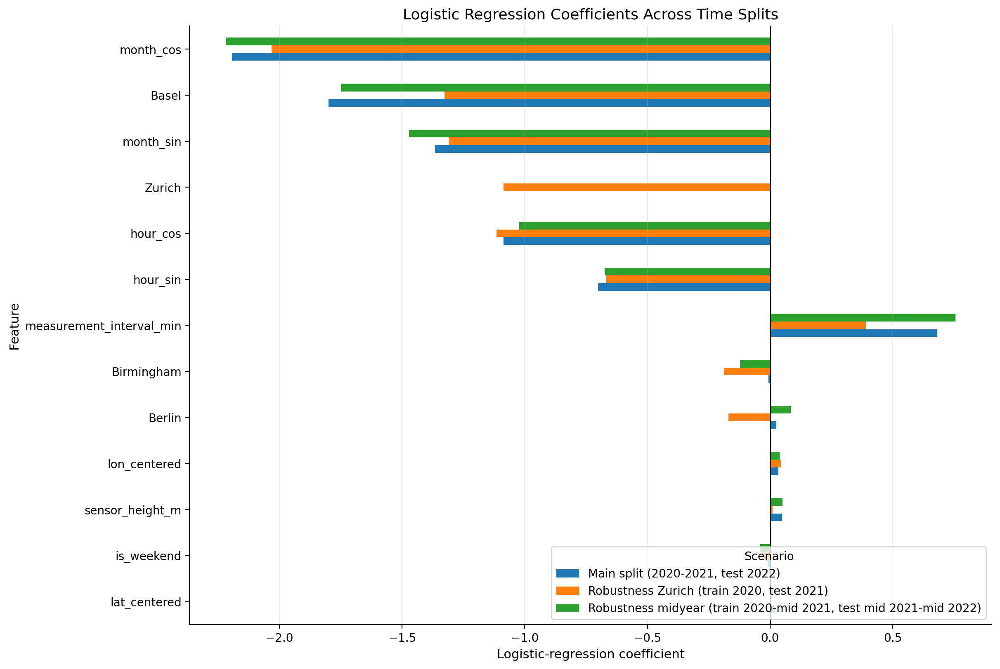

In [101]:
period_coeffs_all = pd.concat(period_coeffs, ignore_index=True)

plot_coefficient_robustness(
    coefficients=period_coeffs_all,
    title="Logistic Regression Coefficients Across Time Splits",
    figsize=(12, 8),
)

#### 6.5.4. Stability Across Alternative Heat-Risk Thresholds

This robustness check evaluates whether the main driver interpretation depends on the percentile used to define high heat. The model is refitted using three alternative binary targets: `heat_risk_q85`, `heat_risk_q90`, and `heat_risk_q95`. These correspond to increasingly strict definitions of high heat, with `q95` identifying only the most extreme observations.

The main coefficient structure is broadly stable across the three target definitions. The cyclical temporal variables remain the dominant predictors in all specifications: `month_cos`, `month_sin`, `hour_cos`, and `hour_sin` keep large magnitudes and consistent signs. This indicates that the annual seasonal cycle and the daily cycle remain the central drivers regardless of whether high heat is defined more broadly or more strictly.

The coefficient for `measurement_interval_min` is also consistently positive across the three thresholds, although its interpretation should remain cautious because it describes the monitoring process rather than a direct environmental mechanism. Spatial variables, sensor height, and weekend status remain close to zero, suggesting limited additional explanatory power once temporal structure and city effects are included.

City effects are less stable than the temporal predictors. Basel remains negative across all target definitions, but its magnitude changes as the heat-risk threshold becomes stricter. Berlin and Birmingham also vary more at the most extreme threshold, especially under `heat_risk_q95`. This suggests that city-specific coefficients are more sensitive to how the positive class is defined and should therefore be interpreted as conditional model adjustments rather than robust standalone effects.

Overall, the robustness check supports the main conclusion that temporal seasonality and daily-cycle effects are the most stable predictors of high-heat risk. The exact size of some city coefficients changes with the target definition, but the dominant temporal driver ranking remains consistent.

In [102]:
target_cols = ["heat_risk_q85", "heat_risk_q90", "heat_risk_q95"]

percentile_results = []
percentile_coeffs = []

for tcol in target_cols:
    evaluation, _, coefficients = fit_evaluate_model(
        split_config=main_split,
        target_col=tcol,
        verbose=True,
    )

    percentile_results.append(evaluation.assign(target=tcol))
    percentile_coeffs.append(coefficients.assign(model=tcol))

Model: Logistic Regression
Target: heat_risk_q85
Split: Main split (2020-2021, test 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: All selected features

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,month_cos,-2.277,0.103,-89.7,False,per 1-SD increase or binary change,2.277
1,Logistic Regression,City: Basel,-1.559,0.210,-79.0,True,relative to Amsterdam,1.559
2,Logistic Regression,month_sin,-1.477,0.228,-77.2,False,per 1-SD increase or binary change,1.477
3,Logistic Regression,hour_cos,-1.034,0.356,-64.4,False,per 1-SD increase or binary change,1.034
4,Logistic Regression,hour_sin,-0.677,0.508,-49.2,False,per 1-SD increase or binary change,0.677
5,Logistic Regression,measurement_interval_min,0.600,1.821,82.1,False,per 1-SD increase or binary change,0.600
6,Logistic Regression,City: Berlin,0.210,1.234,23.4,True,relative to Amsterdam,0.210
7,Logistic Regression,City: Birmingham,0.175,1.191,19.1,True,relative to Amsterdam,0.175
8,Logistic Regression,sensor_height_m,0.105,1.111,11.1,False,per 1-SD increase or binary change,0.105
9,Logistic Regression,lon_centered,0.039,1.040,4.0,False,per 1-SD increase or binary change,0.039



Model: Logistic Regression
Target: heat_risk_q90
Split: Main split (2020-2021, test 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: All selected features

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,month_cos,-2.193,0.112,-88.8,False,per 1-SD increase or binary change,2.193
1,Logistic Regression,City: Basel,-1.799,0.165,-83.5,True,relative to Amsterdam,1.799
2,Logistic Regression,month_sin,-1.366,0.255,-74.5,False,per 1-SD increase or binary change,1.366
3,Logistic Regression,hour_cos,-1.086,0.338,-66.2,False,per 1-SD increase or binary change,1.086
4,Logistic Regression,hour_sin,-0.701,0.496,-50.4,False,per 1-SD increase or binary change,0.701
5,Logistic Regression,measurement_interval_min,0.683,1.979,97.9,False,per 1-SD increase or binary change,0.683
6,Logistic Regression,sensor_height_m,0.049,1.051,5.1,False,per 1-SD increase or binary change,0.049
7,Logistic Regression,lon_centered,0.035,1.035,3.5,False,per 1-SD increase or binary change,0.035
8,Logistic Regression,City: Berlin,0.026,1.026,2.6,True,relative to Amsterdam,0.026
9,Logistic Regression,lat_centered,0.018,1.018,1.8,False,per 1-SD increase or binary change,0.018



Model: Logistic Regression
Target: heat_risk_q95
Split: Main split (2020-2021, test 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: All selected features

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,City: Basel,-2.188,0.112,-88.8,True,relative to Amsterdam,2.188
1,Logistic Regression,month_cos,-2.149,0.117,-88.3,False,per 1-SD increase or binary change,2.149
2,Logistic Regression,month_sin,-1.349,0.260,-74.0,False,per 1-SD increase or binary change,1.349
3,Logistic Regression,hour_cos,-1.097,0.334,-66.6,False,per 1-SD increase or binary change,1.097
4,Logistic Regression,hour_sin,-0.688,0.503,-49.7,False,per 1-SD increase or binary change,0.688
5,Logistic Regression,measurement_interval_min,0.680,1.974,97.4,False,per 1-SD increase or binary change,0.680
6,Logistic Regression,City: Birmingham,-0.648,0.523,-47.7,True,relative to Amsterdam,0.648
7,Logistic Regression,City: Berlin,-0.526,0.591,-40.9,True,relative to Amsterdam,0.526
8,Logistic Regression,sensor_height_m,-0.115,0.891,-10.9,False,per 1-SD increase or binary change,0.115
9,Logistic Regression,lon_centered,0.061,1.063,6.3,False,per 1-SD increase or binary change,0.061


In [103]:
percentile_results_df = pd.concat(percentile_results, ignore_index=True)

print("Logistic regression performance across heat-risk thresholds")
display(percentile_results_df[["target", *main_cols]].round(4))

Logistic regression performance across heat-risk thresholds


,target,model,threshold,log_loss,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,heat_risk_q85,Logistic Regression,0.104,0.2413,0.9448,0.7729,0.8430,0.8713,0.5330,0.9151,0.8274,0.6737
1,heat_risk_q90,Logistic Regression,0.104,0.2003,0.9483,0.6810,0.8728,0.8815,0.4908,0.8932,0.8699,0.6335
2,heat_risk_q95,Logistic Regression,0.104,0.1464,0.9550,0.5214,0.9243,0.8636,0.4728,0.7932,0.9340,0.5924


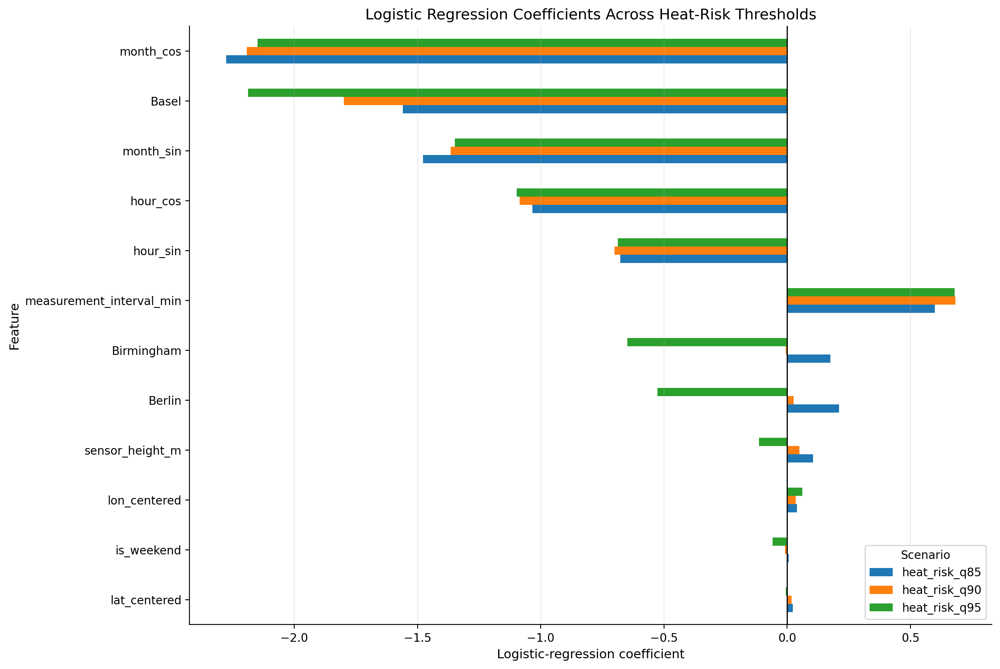

In [104]:
percentile_coeffs_all = pd.concat(percentile_coeffs, ignore_index=True)

plot_coefficient_robustness(
    coefficients=percentile_coeffs_all,
    title="Logistic Regression Coefficients Across Heat-Risk Thresholds",
    figsize=(12, 8),
)

#### 6.5.5. Stability Across Feature Subsets

The feature-subset robustness check evaluates how much predictive signal is carried by different groups of predictors. Three reduced models are fitted: temporal features plus city, spatial features plus city, and measurement features plus city. The city indicator is retained in each case as a common control, so the comparison focuses on the additional contribution of each feature family.

The temporal subset clearly contains the strongest signal. When only temporal variables and city effects are included, the largest coefficients remain the cyclical month and hour terms. This confirms that annual seasonality and the daily cycle are the dominant drivers of high-heat risk in the available feature set.

The spatial-only and measurement-only subsets show much weaker structure. Spatial coordinates have coefficients close to zero, suggesting that the centered latitude and longitude variables add limited predictive information on their own. Measurement features also provide limited explanatory power, although `measurement_interval_min` retains a positive coefficient when measurement variables are considered separately.

The city effects vary across subsets because the meaning of the city coefficients changes depending on which other predictors are included. For example, in the temporal subset, city effects represent residual differences after controlling for seasonality and time of day; in the spatial or measurement subsets, they also absorb temporal variation that is no longer explicitly modelled. These coefficients should therefore not be compared across subsets as fixed city effects.

Overall, this robustness check reinforces the main interpretation: the model's predictive signal is driven primarily by temporal structure. Spatial and measurement variables do not appear to provide strong standalone explanatory power, although they may still contribute modestly when combined with the full feature set.

In [105]:
feature_subset_configs = {
    "Temporal + city": temporal_features,
    "Spatial + city": spatial_features,
    "Measurement + city": measurement_features,
}

subset_results = []
subset_coeffs = []

for subset_name, subset_numeric_features in feature_subset_configs.items():
    subset_feature_cols = subset_numeric_features + categorical_features
    subset_preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, subset_numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )
    subset_pipeline = Pipeline(steps=[
        ("preprocessor", subset_preprocessor),
        ("model", clone(selected_model_pipeline.named_steps["model"])),
    ])

    evaluation, _, coefficients = fit_evaluate_model(
        split_config=main_split,
        target_col=target_col,
        input_feature_cols=subset_feature_cols,
        model_pipeline=subset_pipeline,
        model_name=selected_model_name,
        feature_subset_name=subset_name,
        threshold=selected_threshold,
        verbose=True,
    )

    subset_results.append(evaluation.assign(subset=subset_name))
    subset_coeffs.append(coefficients.assign(model=subset_name))

Model: Logistic Regression
Target: heat_risk_q90
Split: Main split (2020-2021, test 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: Temporal + city

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,month_cos,-2.190,0.112,-88.8,False,per 1-SD increase or binary change,2.190
1,Logistic Regression,month_sin,-1.363,0.256,-74.4,False,per 1-SD increase or binary change,1.363
2,Logistic Regression,hour_cos,-1.085,0.338,-66.2,False,per 1-SD increase or binary change,1.085
3,Logistic Regression,hour_sin,-0.700,0.497,-50.3,False,per 1-SD increase or binary change,0.700
4,Logistic Regression,City: Basel,-0.460,0.631,-36.9,True,relative to Amsterdam,0.460
5,Logistic Regression,City: Birmingham,-0.165,0.848,-15.2,True,relative to Amsterdam,0.165
6,Logistic Regression,City: Berlin,-0.137,0.872,-12.8,True,relative to Amsterdam,0.137
7,Logistic Regression,is_weekend,-0.009,0.991,-0.9,False,per 1-SD increase or binary change,0.009



Model: Logistic Regression
Target: heat_risk_q90
Split: Main split (2020-2021, test 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: Spatial + city

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,City: Basel,-0.138,0.871,-12.9,True,relative to Amsterdam,0.138
1,Logistic Regression,City: Birmingham,-0.042,0.959,-4.1,True,relative to Amsterdam,0.042
2,Logistic Regression,City: Berlin,-0.042,0.959,-4.1,True,relative to Amsterdam,0.042
3,Logistic Regression,lon_centered,0.030,1.030,3.0,False,per 1-SD increase or binary change,0.030
4,Logistic Regression,lat_centered,0.009,1.009,0.9,False,per 1-SD increase or binary change,0.009



Model: Logistic Regression
Target: heat_risk_q90
Split: Main split (2020-2021, test 2022)
Cities: ['Amsterdam', 'Basel', 'Berlin', 'Birmingham']
Feature subset: Measurement + city

Reference city: Amsterdam
Numeric-feature odds ratios refer to a one-standard-deviation increase because numeric predictors were standardized.


,model,feature,coefficient,odds_ratio,odds_change_pct,is_city_effect,interpretation_unit,abs_coefficient
0,Logistic Regression,City: Basel,-0.923,0.398,-60.2,True,relative to Amsterdam,0.923
1,Logistic Regression,measurement_interval_min,0.436,1.547,54.7,False,per 1-SD increase or binary change,0.436
2,Logistic Regression,City: Birmingham,0.198,1.219,21.9,True,relative to Amsterdam,0.198
3,Logistic Regression,City: Berlin,0.142,1.153,15.3,True,relative to Amsterdam,0.142
4,Logistic Regression,sensor_height_m,0.063,1.066,6.6,False,per 1-SD increase or binary change,0.063


In [106]:
subset_results_df = pd.concat(subset_results, ignore_index=True)

print("Logistic regression performance across feature subsets")
display(subset_results_df[["subset", *main_cols]].round(4))

Logistic regression performance across feature subsets


,subset,model,threshold,log_loss,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,specificity,f1
0,Temporal + city,Logistic Regression,0.104,0.2004,0.9482,0.6806,0.8719,0.8810,0.4890,0.8930,0.8690,0.6320
1,Spatial + city,Logistic Regression,0.104,0.3802,0.5021,0.1257,0.8769,0.5000,0.0000,0.0000,1.0000,0.0000
2,Measurement + city,Logistic Regression,0.104,0.3803,0.4979,0.1237,0.8690,0.5006,0.1344,0.0117,0.9894,0.0216


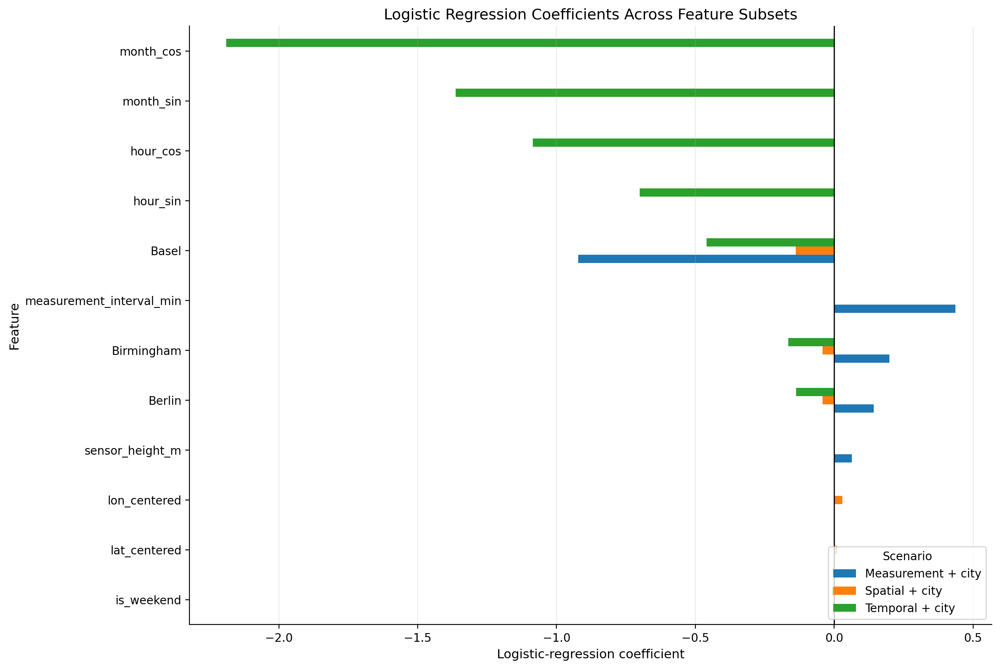

In [107]:
subset_coeffs_all = pd.concat(subset_coeffs, ignore_index=True)

plot_coefficient_robustness(
    coefficients=subset_coeffs_all,
    title="Logistic Regression Coefficients Across Feature Subsets",
    figsize=(12, 8),
)

### 6.6. Summary of Validation Findings

The validation analysis supports the choice of unregularized logistic regression as the primary model. It performs substantially better than the dummy baseline, matches or slightly improves on the regularized logistic model, and remains more interpretable than the random forest. The random forest does not provide clear predictive gains, suggesting that the selected feature set does not contain strong nonlinear structure that the logistic model fails to capture.

Threshold tuning is an important part of the final decision rule. At the default threshold of $0.50$, the model is too conservative for a heat-alert context. The selected $F_2$-optimal threshold of approximately $0.104$ increases recall and reduces missed high-heat events, while accepting more false positives. This trade-off is consistent with the project objective, where missed high-heat events are considered more costly than false alerts.

City-level diagnostics show that model performance is broadly reasonable across cities, although not perfectly uniform. Amsterdam remains the weakest-performing city, likely because it has a much smaller test sample than the other cities. This means that pooled performance metrics should be interpreted alongside city-level diagnostics rather than as a complete description of model behaviour.

The interpretation and robustness checks consistently identify temporal structure as the main driver of predicted high-heat risk. Seasonal and daily-cycle variables remain dominant across the unregularized and regularized logistic models, the random forest comparison, alternative time splits, alternative heat-risk thresholds, and feature-subset checks. City effects and measurement variables are less stable and should be interpreted more cautiously.

The validation results also allow the main modelling assumptions stated in Sections 1 and 5 to be revisited. The assumption that temporal structure would be important is strongly supported: seasonal and daily-cycle features dominate across models and robustness checks. The assumption that the city-relative 90th-percentile target provides a usable definition of high heat is also broadly supported, since model performance remains strong and the main driver ranking is stable under alternative percentile thresholds. The assumption that a pooled model with city controls can identify shared cross-city drivers is reasonable, but should be treated with caution because city-level diagnostics show weaker performance for Amsterdam and because city effects are less stable than temporal effects. Finally, the assumption that the available spatial and measurement-related variables capture meaningful local differences is only weakly supported; these features contribute much less consistently than temporal predictors.

Overall, the model provides a useful and interpretable baseline for high-heat risk prediction. The main findings are robust at the level of broad driver ranking, especially for temporal predictors, but some city-specific and metadata-related effects remain conditional on modelling choices. Broader limitations and possible extensions are discussed in the following section.

## 7. Discussion and Implications

This final section brings together the modelling and validation results and translates them back into the project question. The focus is no longer on improving predictive performance, but on interpreting what the validated models suggest about the drivers of high heat risk, how robust those findings are, and what they can reasonably support in practice.

The main emphasis is on driver interpretation: which features appear most strongly associated with high heat exposure, whether those associations remain stable across alternative model choices and sensitivity checks, and how much confidence we can place in them. The section also presents the station-level risk map as a decision-support output, while making clear that the map should be interpreted as a screening and prioritization aid rather than as direct evidence of causal local heat effects.

The section concludes by discussing uncertainty, limitations, and the practical implications of the analysis for heat-risk prioritization.

Helper functions used in this section are defined in [0.4.5. Station-Risk Map Helper Functions](#045-station-risk-map-helper-functions).

### 7.1. Main Drivers of Heat Risk

This project asked which factors are most associated with high heat risk at the station-hour level, and whether those associations remain stable under alternative modelling choices. The results point to a clear answer: in this dataset, high heat risk is driven primarily by **temporal structure**, especially the hour of the day and the time of year.

Across the main logistic regression model and the robustness checks, the cyclical encodings of daily and seasonal timing consistently ranked as the strongest predictors. This means that the model mostly identifies high-risk exposure through when an observation occurs, rather than through where the station is located or how the station is measured. The direction of this finding is also consistent with domain expectations: heat risk is concentrated in specific parts of the daily and annual cycle, rather than being evenly distributed across time.

By contrast, the included spatial variables contributed little independent predictive signal once city-level differences and temporal patterns were accounted for. Latitude and longitude did not behave like strong micro-location drivers of heat risk in the final model. This does not mean that urban form or local geography are irrelevant in reality; rather, it means that the spatial information available in this dataset was too limited to explain much additional variation beyond the temporal and city-level structure.

Measurement-related variables showed a similarly limited and less stable role. Some measurement features appeared relevant in the non-regularized logistic regression, but their importance weakened under regularization and in the random forest comparison. Therefore, they should be interpreted cautiously: they may capture some dataset-specific structure, but they are not robust enough to be treated as primary drivers.

Overall, the main driver ranking is therefore: first, temporal features; second, city-level/contextual differences; and only then, with much weaker evidence, measurement and station-location features. For this analysis, this is the central result: the project identifies interpretable drivers of high heat risk, but it also shows that the robust signal is much more about **timing** than about fine-grained station geography.

### 7.2. Station-Level Risk Map

The station-level risk map translates the fitted model into a spatial decision-support output. Each marker represents one monitoring station and is coloured by its **standardised mean predicted probability of a city-relative high-heat event**. A city-relative high-heat event means that the model predicts whether an hourly observation exceeds that city's own high-heat threshold, rather than a single absolute temperature threshold shared across all cities.

The probability shown on the map is calculated in three steps. First, the model creates a shared hourly reference calendar for the test period, including the same hour-of-day, month-of-year, and weekend indicators for every station. Second, each station is evaluated across this same calendar using its own city, coordinates, centred spatial features, sensor height, and measurement interval. Third, the model predicts a high-heat probability for every station-hour in this standardised calendar, and the final mapped value is the mean of those hourly probabilities, expressed as a percentage. In other words, the colour does not show the observed heat rate at that station; it shows the model-estimated average risk for that station under common temporal conditions.

This standardisation is important because station-level observations are not equally complete. If the map simply averaged observed high-heat events, stations active mostly during hotter months or missing during cooler periods could appear artificially risky, while stations with better winter coverage could appear safer. By scoring every station over the same temporal calendar, the map reduces this coverage bias and makes the station comparison less dependent on when data happened to be available. However, this does not fully solve the missing-data problem. Stations with limited test-period coverage still have less reliable spatial and measurement profiles, and their mapped values are closer to model extrapolations than direct empirical estimates. For this reason, the popups report the number of observed test records, observed months, and observed hours of day for each station.

The city-level patterns should therefore be interpreted together with coverage. Amsterdam is the clearest example of this limitation. Although Amsterdam originally contains several stations, only one station remains represented in the 2022 test-period map after the cleaning, temporal split, and complete-profile requirements. The Amsterdam marker is therefore not a within-city risk pattern; it is only the model's estimate for the single remaining station. Its high predicted probability should be treated cautiously, especially because the city-level diagnostics already showed that Amsterdam has the smallest and weakest test sample.

Basel shows the opposite pattern: many stations remain on the map, but their predicted probabilities are relatively low and tightly clustered. This is consistent with the strong negative Basel city effect in the logistic model, although that coefficient was not equally important in every robustness check. The map therefore suggests broadly lower model-estimated city-relative heat risk for Basel stations under the shared calendar, but the small differences between Basel stations should not be overinterpreted as precise local rankings.

Berlin shows a more visible spatial gradient. The stations closer to the city centre receive higher predicted probabilities, while stations farther from the centre, especially toward the outer western/southwestern area, tend to be lower. This pattern is plausible from an urban-heat perspective, but it should still be read carefully because the robustness checks showed that the included spatial coordinates add only limited independent predictive signal. The gradient may reflect some local spatial structure, but it may also partly reflect how city, coordinates, and station composition interact in the fitted model.

Birmingham also shows a spatial gradient, with several higher-risk stations toward the north-eastern/eastern side of the city and lower-risk stations toward the southwest. As with Berlin, this pattern is useful for screening and prioritisation, but it should not be interpreted as proof that those neighbourhoods are causally hotter. Some Birmingham stations also have fewer observed months in the test period, so local rankings should be checked against the popup coverage information before being used for decisions.

Overall, the map is useful but not definitive. It is reliable as a **model-based screening tool** because it is built from the validated model and uses a shared temporal calendar to reduce coverage-driven bias. It is less reliable as a precise spatial heat-risk map because the model's strongest drivers are temporal, not spatial, and because station-level coverage remains uneven. The safest interpretation is therefore: the map can highlight stations and city areas that deserve closer inspection, but the main robust conclusion of the project remains that heat risk is driven much more strongly by timing than by fine-grained station location.

In [108]:
station_risk_map = build_station_risk_map_for_config(
    split_config=main_split,
    target_col=target_col,
    data=model_data,
    feature_cols=feature_cols,
    temporal_feature_cols=temporal_features,
    spatial_feature_cols=spatial_features,
    measurement_feature_cols=measurement_features,
    save_html=False,
    html_path="station_risk_map.html",
    display_output=True,
)

# NOTE: If map does not appear uncomment and run this
# from IPython.display import IFrame
# 
# location = "./station_risk_map.html"
# 
# station_risk_map.save(location)
# 
# IFrame(
#     src=location,
#     width="100%",
#     height=600
# )

### 7.3. Uncertainty and Limitations

Several limitations affect how far the results can be interpreted. The first concerns **generalizability**. The final model is based on a limited set of European cities with usable overlapping coverage, and the main split includes only Amsterdam, Basel, Berlin, and Birmingham. These cities do not represent all possible urban climates, urban forms, or monitoring networks. Therefore, the findings should be understood as evidence from this dataset, not as a universal ranking of heat-risk drivers across Europe.

A second limitation is **data coverage**. Although the analysis uses a cleaned and reproducible modelling dataset, coverage is still uneven across cities and stations. Some cities contribute many more observations than others, and some stations are observed for fewer months in the test period. Amsterdam is the clearest example: only one station remains in the final station-level map, so its mapped risk cannot describe a city-wide spatial pattern. Birmingham also contains stations with partial test-period coverage. The standardised map calculation reduces the risk that missing months directly distort the mapped probabilities, but it cannot create information where station coverage is thin. Predictions for poorly covered stations should therefore be treated as less certain.

A third limitation concerns the **available spatial and contextual features**. The model includes latitude, longitude, centred spatial coordinates, city indicators, sensor height, and measurement interval, but it does not include richer urban-form variables such as land cover, vegetation, building density, impervious surface, traffic exposure, shading, or altitude. These missing factors are likely relevant to urban heat risk. As a result, the weak role of spatial predictors in the model should not be interpreted as evidence that local geography or urban design do not matter. It only means that the spatial information available in this dataset added little independent predictive signal.

The interpretation of feature importance is also limited by the modelling design. The main logistic regression is useful because it gives interpretable coefficients, but it captures associations rather than causal effects. A positive or negative coefficient does not prove that changing that factor would directly increase or reduce heat risk. The robustness checks help identify stable patterns, but they do not remove confounding, measurement error, or omitted-variable bias. This is especially important for city effects, which may combine climate, monitoring design, station placement, and unobserved urban characteristics.

The target definition introduces another source of uncertainty. High heat risk is defined relative to each city's own temperature distribution, using a percentile threshold. This makes cities more comparable in terms of locally unusual heat, but it also means that the model predicts **relative heat events**, not absolute dangerous temperatures. A high-risk event in Birmingham and a high-risk event in Basel are therefore not necessarily the same absolute temperature. The sensitivity checks with alternative thresholds reduce concern that the main driver findings depend entirely on one cutoff, but the interpretation remains tied to the chosen city-relative definition.

Overall, the results are reliable for the project's main Track 3 conclusion: temporal features, especially hour-of-day and month-of-year structure, are the most robust drivers of city-relative high heat risk in this dataset. The results are less reliable for fine-grained spatial claims, precise station rankings, or causal statements

### 7.4. Decision-Oriented Interpretation and Next Steps

The main decision-oriented implication of this analysis is that heat-risk prioritisation should focus first on **timing**. Across the main model and the robustness checks, hour-of-day and month-of-year features were the clearest and most stable drivers of city-relative high-heat events. This suggests that the most reliable use of the model is to identify the daily and seasonal periods when heat-risk monitoring, alerts, or mitigation planning should be most active.

The spatial map adds a second, more cautious layer of decision support. Within cities such as Berlin and Birmingham, the mapped predictions highlight stations and areas that may deserve closer inspection, especially where higher predicted probabilities form visible spatial gradients. However, these patterns should be used for screening rather than final decisions. The available spatial features were relatively weak in the driver analysis, and station-level coverage remains uneven.

For practical use, the results support a two-step prioritisation strategy:

1. Use the temporal findings to identify high-risk windows: the months and hours when city-relative heat events are most likely.
2. Use the station-level map to decide where additional monitoring, local inspection, or mitigation planning may be useful.

This is especially relevant for cities with multiple well-covered stations, such as Basel, Berlin, and Birmingham. For Amsterdam, the final map cannot support within-city prioritisation because only one station remains in the test-period output.

The project therefore answers the initial question with a clear but bounded conclusion. The strongest and most robust drivers of high heat risk in this dataset are temporal, while the available spatial and measurement-related variables contribute weaker and less stable information. The model is useful as an interpretable framework for understanding and screening heat risk, but it should not be treated as a causal explanation of urban heat patterns or as a complete basis for intervention planning.

A useful extension would be to enrich the analysis with external city- and station-level covariates.

At the **city level**, this could include:

- distance from the sea or large water bodies
- average elevation
- population density
- urban density
- share of green space
- share of impervious surface
- land-use mix
- broader climate-zone indicators

At the **station or neighbourhood level**, useful additions could include:

- distance to parks, rivers, or other cooling areas
- local vegetation indices, such as NDVI
- tree-canopy cover
- building density
- average building height
- street-canyon characteristics
- road density
- traffic intensity
- surface material, such as asphalt, concrete, grass, or soil
- sky-view factor
- local shading
- proximity to industrial or highly paved areas

These variables would make it possible to test whether the weak spatial signal found here reflects a true lack of local spatial structure or simply the absence of meaningful urban-form predictors in the available dataset. With those extensions, the same workflow could move from identifying robust timing patterns toward a more complete explanation of why some urban locations face higher heat risk than others.

### 7.5. Conclusion

This project set out to identify, at the station-hour level across selected European cities, which temporal, spatial, and measurement-related factors are most strongly associated with high heat exposure — defined relative to each city's own 90th-percentile temperature — and to test how stable those associations are across alternative input conditions. Working from the FAIRUrbTemp curated dataset and deliberately excluding any temperature-derived predictors, the analysis built a reproducible pipeline from data audit and cleaning, through exploratory analysis, to a logistic model chosen for its balance of performance and interpretability, validated with time-series cross-validation, out-of-fold threshold tuning, and a sequence of robustness checks.

The central finding is clear and consistent: high heat exposure is driven overwhelmingly by **temporal structure**. The cyclical encodings of hour-of-day and month-of-year dominate every model tested, and the feature-subset check showed they carry almost all of the usable signal on their own. Spatial coordinates contributed little once the city was accounted for, and the measurement-related features were weak and unstable, retaining importance only in the unregularized model. Crucially, these conclusions held across model classes — a regularized logistic regression and a random forest recovered a very similar ranking — and across alternative threshold definitions and time windows, so the driver ranking is a property of the data rather than of any single modelling choice. To this extent the project answers its question: the drivers are identifiable, and they are robust.

These results are best read as *confirmatory rather than discovery-driven*. That heat tracks time of day and season is exactly what domain knowledge predicts, and the value of the analysis lies in having demonstrated this structure rigorously and quantified its stability, not in uncovering a surprising new driver. Translated into decision support, the practical implication is one of **timing more than location**: because the actionable signal is temporal, the strongest decision-oriented use of this work is to inform *when* heat-alert or mitigation resources should be active — the specific daily and seasonal windows of elevated risk — while the station-level map serves as a within-city screening and prioritization aid rather than a cross-city comparison.

That last distinction also marks the project's main limits. Because the target is city-relative and the city term absorbs much of the between-city variation, predicted probabilities are not comparable across cities, and the map should be read within cities, not between them. The evidence base is narrow — a handful of central-European cities, thinned further by data-quality attrition and gaps such as the omission of altitude — so the model should not be assumed to generalize to cities of different climatic or spatial character.

Taken together, the project delivers what it promised: a coherent, reproducible workflow that frames a clear question, prepares and audits the data honestly, and produces an interpretable, robustly-validated ranking of heat-risk drivers tied to a concrete decision use. Its conclusion is a well-supported one. The dominant, stable driver of high heat exposure in this data is temporal, this is most useful for timing interventions, and meaningful spatial or cross-city conclusions would require richer features, more cities, and a common-scale target left to future work.

## References

[1] Amini, S., Huerta, A., Franke, J., Brugnara, Y., Caluwaerts, S., Anet, J., Savić, S., Gubler, M., Steeneveld, G.-J., Chapman, L., Meier, F., Dubreuil, V., Christen, A., Zeeman, M., Lalić, B., Schlögl, S., Käyhkö, J., Azadfar, A. M., & Brönnimann, S. (2026). *Comprehensive compilation and quality assessment of street-level urban air temperature measurements across European networks*. Scientific Data, 13, Article 658. https://www.nature.com/articles/s41597-026-06804-4

[2] Morato, P. G. (2026). *FAIRUrbTemp curated subset for teaching* [Dataset]. Kaggle. https://www.kaggle.com/datasets/pablomoratodomnguez/fairurbtemp-curated